In [44]:
import pandas as pd
import numpy as np

production = pd.read_csv("../datasets/crop_production_yield.csv")
weather_yield = pd.read_csv("../datasets/crop_weather_yield.csv")
fertilizer = pd.read_csv("../datasets/crop_fertilizer.csv")

print("Production:", production.shape)
print("Weather/Yield:", weather_yield.shape)
print("Fertilizer:", fertilizer.shape)

Production: (575879, 8)
Weather/Yield: (50765, 20)
Fertilizer: (4513, 11)


Production: (575879, 8)
Weather/Yield: (50765, 20)
Fertilizer: (4513, 11)

Production columns:
Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production', 'yield'],
      dtype='str')


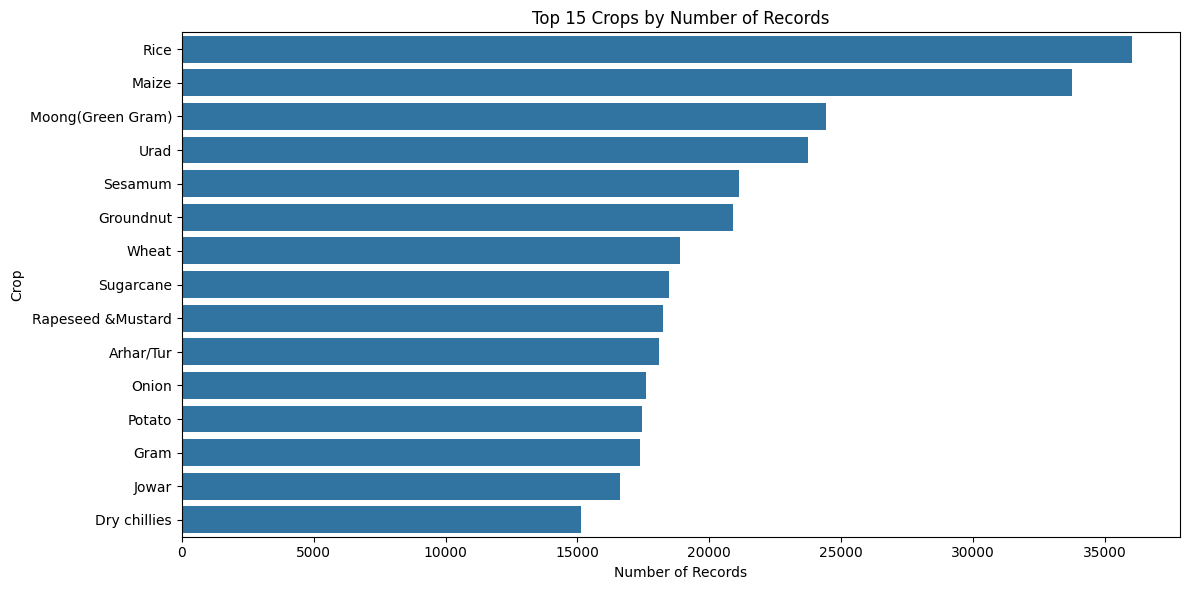

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
production = pd.read_csv("../datasets/crop_production_yield.csv")
weather_yield = pd.read_csv("../datasets/crop_weather_yield.csv")
fertilizer = pd.read_csv("../datasets/crop_fertilizer.csv")

# Check datasets
print("Production:", production.shape)
print("Weather/Yield:", weather_yield.shape)
print("Fertilizer:", fertilizer.shape)

# Check columns
print("\nProduction columns:")
print(production.columns)

# Crop distribution graph
plt.figure(figsize=(12, 6))

top_crops = production['Crop'].value_counts().head(15)

sns.barplot(
    x=top_crops.values,
    y=top_crops.index
)

plt.title("Top 15 Crops by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

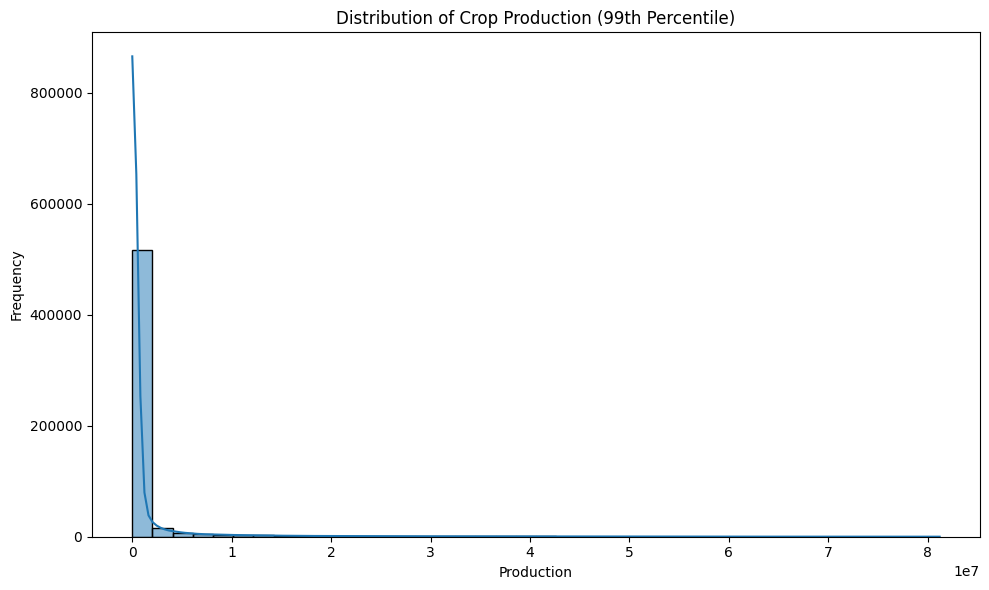

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Keep values up to the 99th percentile only for visualization
production_plot = production[
    production['Production'] <= production['Production'].quantile(0.99)
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=production_plot,
    x='Production',
    kde=True,
    bins=40
)

plt.title("Distribution of Crop Production (99th Percentile)")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

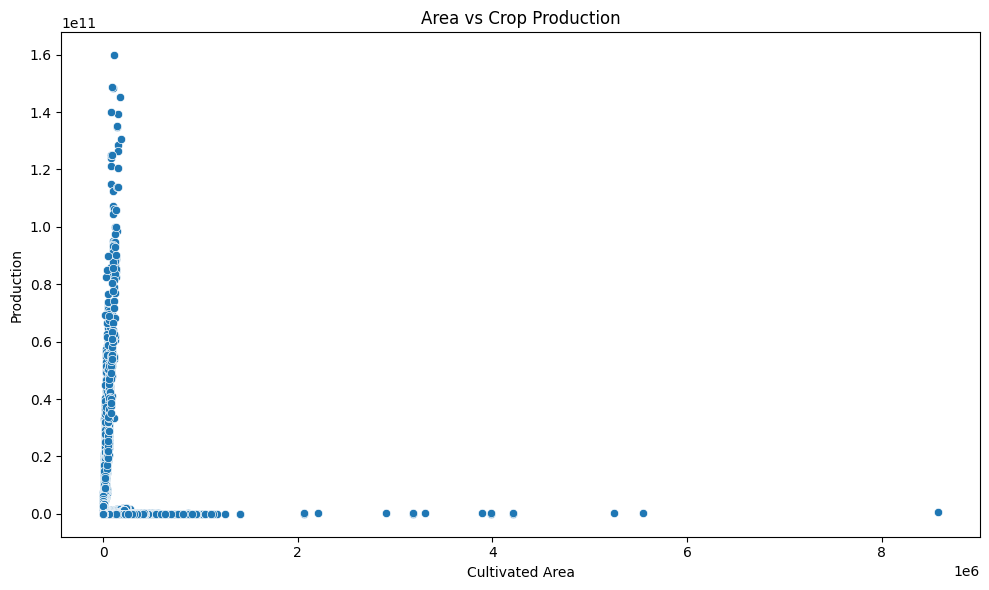

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=production,
    x='Area',
    y='Production'
)

plt.title("Area vs Crop Production")
plt.xlabel("Cultivated Area")
plt.ylabel("Production")
plt.tight_layout()
plt.show()

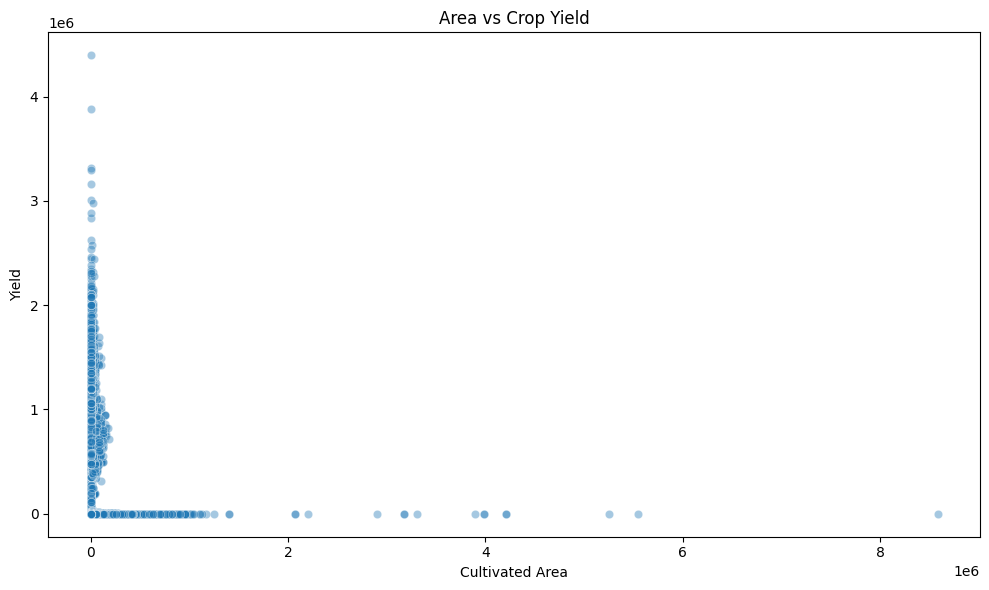

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=production,
    x='Area',
    y='yield',
    alpha=0.4
)

plt.title("Area vs Crop Yield")
plt.xlabel("Cultivated Area")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

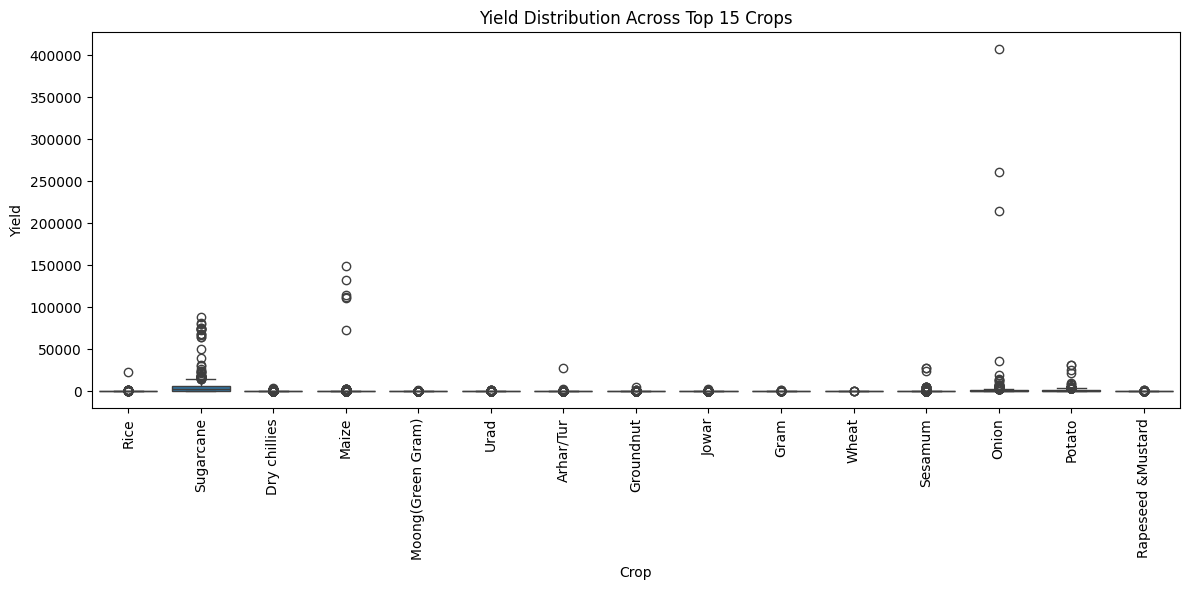

In [13]:
plt.figure(figsize=(12, 6))

top_crops = production['Crop'].value_counts().head(15).index

crop_data = production[production['Crop'].isin(top_crops)]

sns.boxplot(
    data=crop_data,
    x='Crop',
    y='yield'
)

plt.xticks(rotation=90)
plt.title("Yield Distribution Across Top 15 Crops")
plt.xlabel("Crop")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

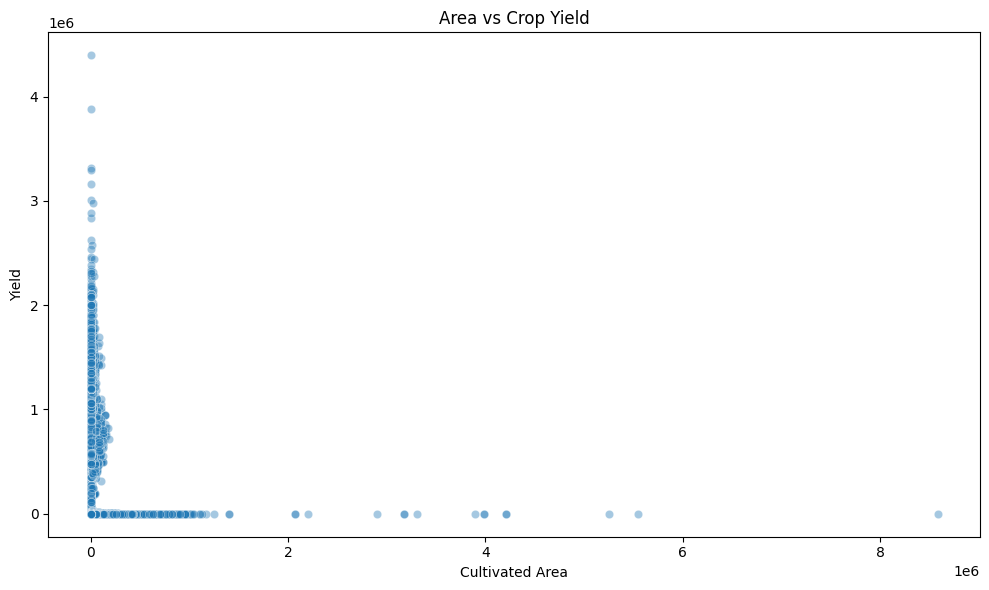

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=production,
    x='Area',
    y='yield',
    alpha=0.4
)

plt.title("Area vs Crop Yield")
plt.xlabel("Cultivated Area")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

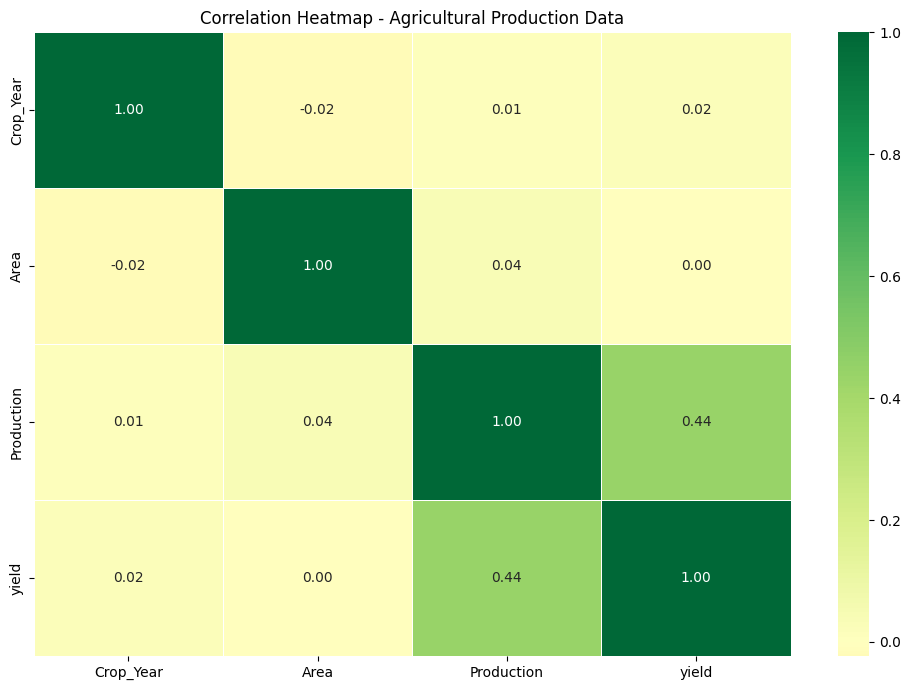

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numeric_data = production.select_dtypes(include='number')

# Calculate correlation
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    fmt='.2f',
    linewidths=0.5,
    center=0
)

plt.title("Correlation Heatmap - Agricultural Production Data")
plt.tight_layout()
plt.show()

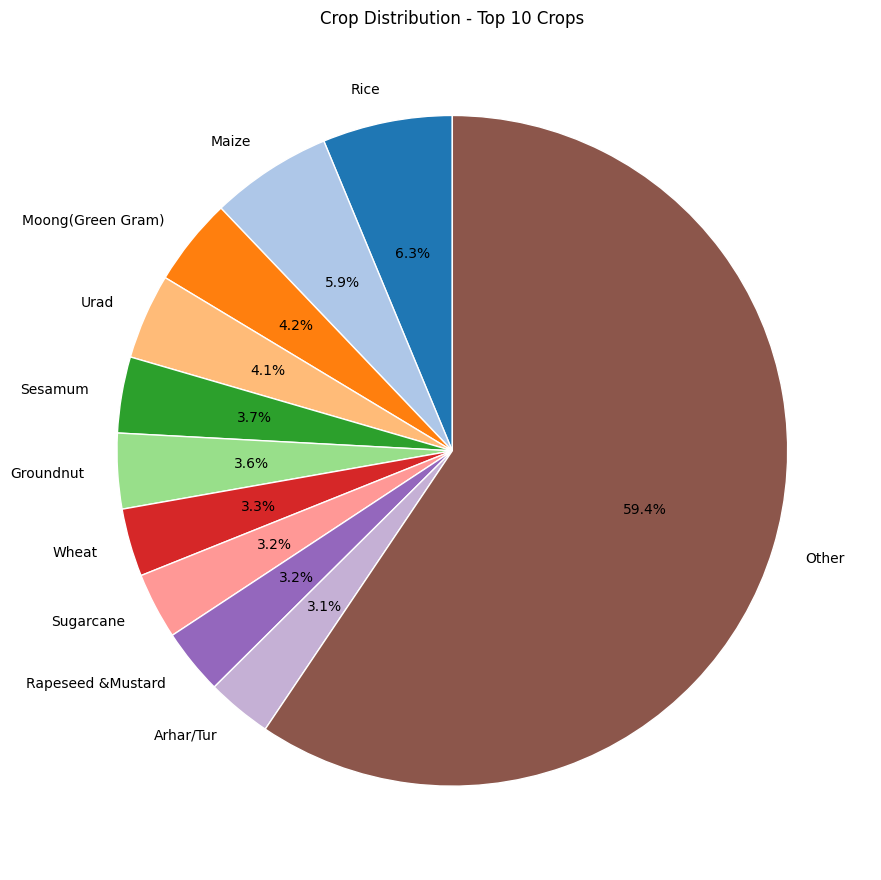

In [16]:
import matplotlib.pyplot as plt

# Get top 10 crops
crop_counts = production['Crop'].value_counts()

top_10 = crop_counts.head(10)
other = crop_counts.iloc[10:].sum()

pie_data = top_10.copy()
pie_data['Other'] = other

plt.figure(figsize=(9, 9))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.tab20.colors[:len(pie_data)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.title("Crop Distribution - Top 10 Crops")
plt.tight_layout()
plt.show()

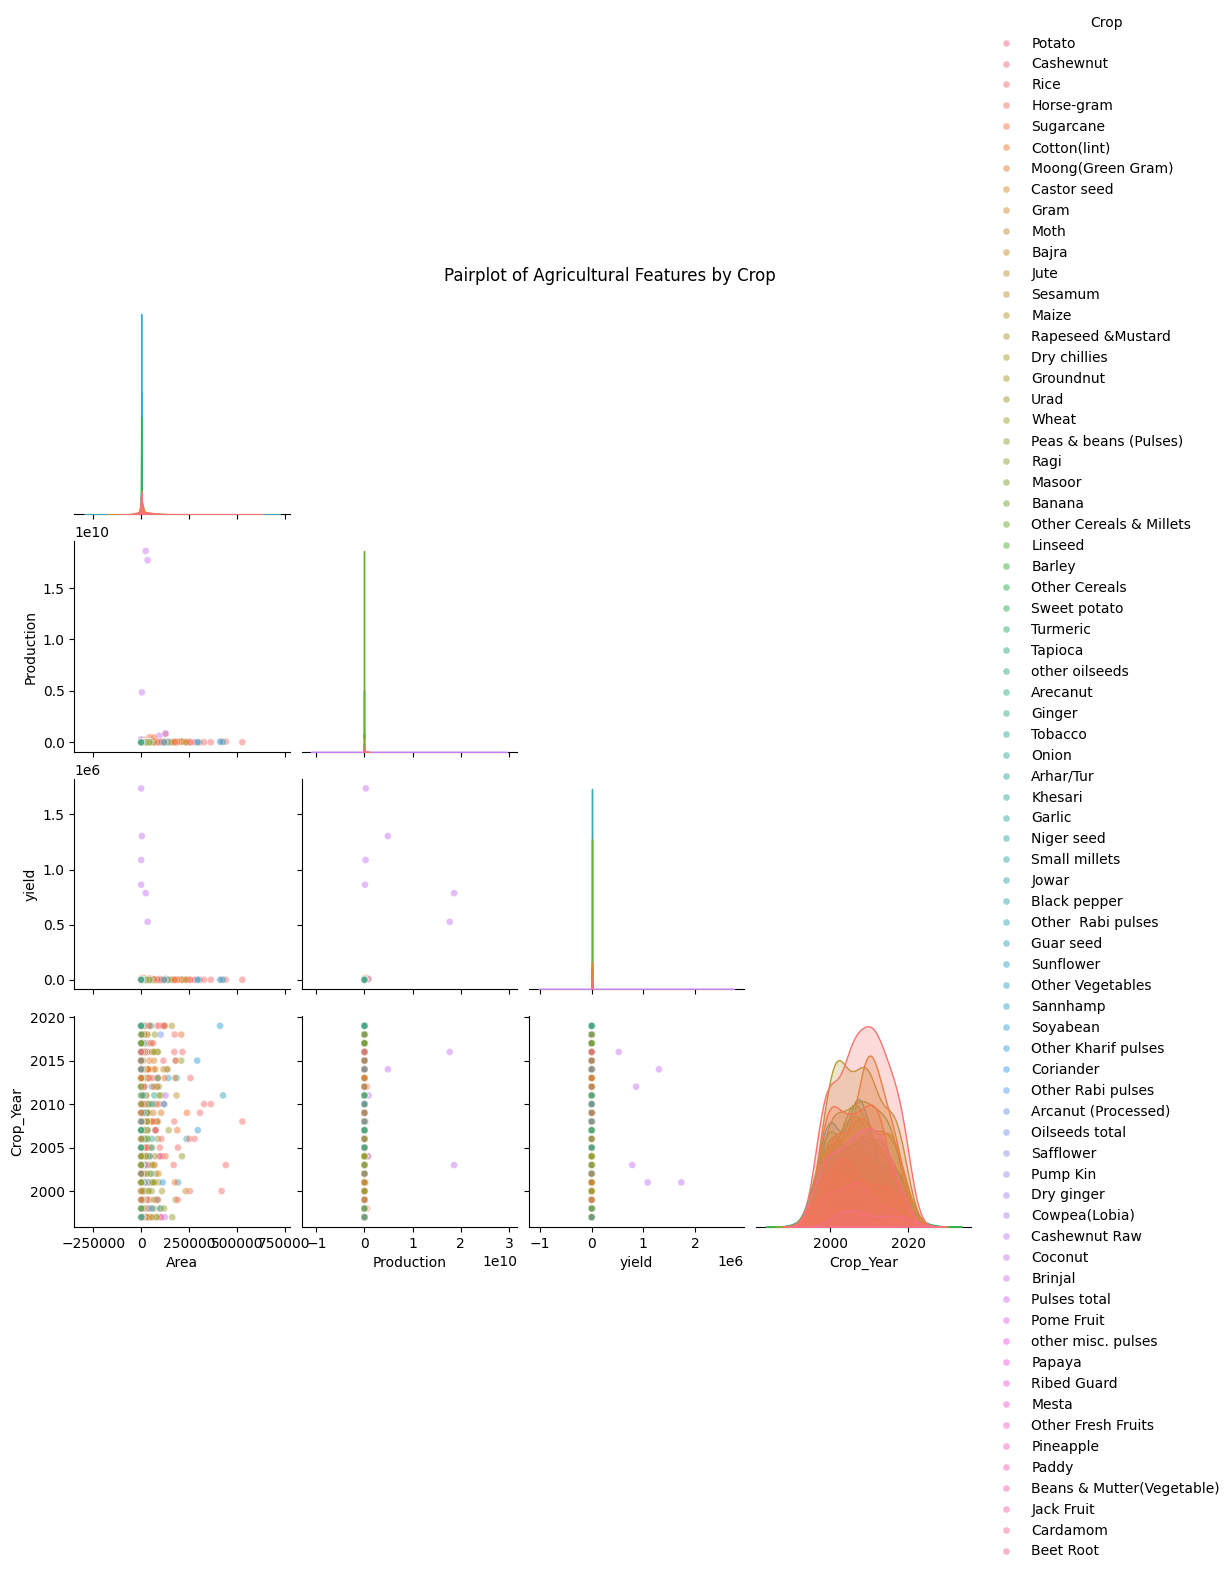

In [18]:
sample_data = production.sample(
    n=2000,
    random_state=42
)

pair_data = sample_data[
    ['Area', 'Production', 'yield', 'Crop_Year', 'Crop']
]

sns.pairplot(
    pair_data,
    hue='Crop',
    diag_kind='kde',
    corner=True,
    palette='husl',
    plot_kws={
        'alpha': 0.5,
        's': 25
    }
)

plt.suptitle(
    "Pairplot of Agricultural Features by Crop",
    y=1.02
)

plt.show()

In [2]:
print("===== PRODUCTION DATASET =====")
print(production.columns.tolist())

print("\n===== WEATHER/YIELD DATASET =====")
print(weather_yield.columns.tolist())

print("\n===== FERTILIZER DATASET =====")
print(fertilizer.columns.tolist())

===== PRODUCTION DATASET =====
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'yield']

===== WEATHER/YIELD DATASET =====
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']

===== FERTILIZER DATASET =====
['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer', 'Link']


In [3]:
print("===== PRODUCTION DATASET =====")
for column in production.columns:
    print(column)

print("\n===== WEATHER/YIELD DATASET =====")
for column in weather_yield.columns:
    print(column)

print("\n===== FERTILIZER DATASET =====")
for column in fertilizer.columns:
    print(column)

===== PRODUCTION DATASET =====
State_Name
District_Name
Crop_Year
Season
Crop
Area
Production
yield

===== WEATHER/YIELD DATASET =====
Dist Code
Year
State Code
State Name
Dist Name
Crop
Area_ha
Yield_kg_per_ha
N_req_kg_per_ha
P_req_kg_per_ha
K_req_kg_per_ha
Total_N_kg
Total_P_kg
Total_K_kg
Temperature_C
Humidity_%
pH
Rainfall_mm
Wind_Speed_m_s
Solar_Radiation_MJ_m2_day

===== FERTILIZER DATASET =====
District_Name
Soil_color
Nitrogen
Phosphorus
Potassium
pH
Rainfall
Temperature
Crop
Fertilizer
Link


In [4]:
print("===== PRODUCTION DATASET =====")
display(production.head())

print("\n===== WEATHER/YIELD DATASET =====")
display(weather_yield.head())

print("\n===== FERTILIZER DATASET =====")
display(fertilizer.head())

===== PRODUCTION DATASET =====


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167



===== WEATHER/YIELD DATASET =====


,Dist Code,Year,State Code,State Name,Dist Name,Crop,Area_ha,Yield_kg_per_ha,N_req_kg_per_ha,P_req_kg_per_ha,K_req_kg_per_ha,Total_N_kg,Total_P_kg,Total_K_kg,Temperature_C,Humidity_%,pH,Rainfall_mm,Wind_Speed_m_s,Solar_Radiation_MJ_m2_day
0,1,1966,14,Chhattisgarh,Durg,rice,548000.0,337.59,8.43975,4.05108,7.42698,4624983.00,2219991.84,4069985.04,25,80,6.5,1200,2.0,18
1,1,1966,14,Chhattisgarh,Durg,maize,3000.0,666.67,18.00009,8.00004,11.33339,54000.27,24000.12,34000.17,22,70,6.0,800,2.5,20
2,1,1966,14,Chhattisgarh,Durg,chickpea,54000.0,500.00,9.00000,5.00000,9.00000,486000.00,270000.00,486000.00,20,60,6.5,600,1.5,16
3,1,1967,14,Chhattisgarh,Durg,rice,547000.0,747.71,18.69275,8.97252,16.44962,10224934.25,4907968.44,8997942.14,25,80,6.5,1200,2.0,18
4,1,1967,14,Chhattisgarh,Durg,maize,3000.0,1000.00,27.00000,12.00000,17.00000,81000.00,36000.00,51000.00,22,70,6.0,800,2.5,20



===== FERTILIZER DATASET =====


,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo


In [45]:
print("===== PRODUCTION DATASET =====")
print(production.isnull().sum())

print("\n===== WEATHER/YIELD DATASET =====")
print(weather_yield.isnull().sum())

print("\n===== FERTILIZER DATASET =====")
print(fertilizer.isnull().sum())

===== PRODUCTION DATASET =====
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
dtype: int64

===== WEATHER/YIELD DATASET =====
Dist Code                    0
Year                         0
State Code                   0
State Name                   0
Dist Name                    0
Crop                         0
Area_ha                      0
Yield_kg_per_ha              0
N_req_kg_per_ha              0
P_req_kg_per_ha              0
K_req_kg_per_ha              0
Total_N_kg                   0
Total_P_kg                   0
Total_K_kg                   0
Temperature_C                0
Humidity_%                   0
pH                           0
Rainfall_mm                  0
Wind_Speed_m_s               0
Solar_Radiation_MJ_m2_day    0
dtype: int64

===== FERTILIZER DATASET =====
District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH       

In [6]:
print("Production duplicates:", production.duplicated().sum())
print("Weather/Yield duplicates:", weather_yield.duplicated().sum())
print("Fertilizer duplicates:", fertilizer.duplicated().sum())

Production duplicates: 0
Weather/Yield duplicates: 0
Fertilizer duplicates: 0


In [7]:
print("===== PRODUCTION DATASET =====")
print(production.dtypes)

print("\n===== WEATHER/YIELD DATASET =====")
print(weather_yield.dtypes)

print("\n===== FERTILIZER DATASET =====")
print(fertilizer.dtypes)

===== PRODUCTION DATASET =====
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64
yield            float64
dtype: object

===== WEATHER/YIELD DATASET =====
Dist Code                      int64
Year                           int64
State Code                     int64
State Name                       str
Dist Name                        str
Crop                             str
Area_ha                      float64
Yield_kg_per_ha              float64
N_req_kg_per_ha              float64
P_req_kg_per_ha              float64
K_req_kg_per_ha              float64
Total_N_kg                   float64
Total_P_kg                   float64
Total_K_kg                   float64
Temperature_C                  int64
Humidity_%                     int64
pH                           float64
Rainfall_mm                    int64
Wind_Speed_m_s               float64
Solar_Radiation_M

In [8]:
print("Number of crops:", weather_yield["Crop"].nunique())

print("\nCrop names:")
print(weather_yield["Crop"].unique())

Number of crops: 4

Crop names:
<StringArray>
['rice', 'maize', 'chickpea', 'cotton']
Length: 4, dtype: str


In [9]:
print("===== PRODUCTION DATASET =====")
print("Number of crops:", production["Crop"].nunique())
print(production["Crop"].unique())

print("\n===== WEATHER/YIELD DATASET =====")
print("Number of crops:", weather_yield["Crop"].nunique())
print(weather_yield["Crop"].unique())

print("\n===== FERTILIZER DATASET =====")
print("Number of crops:", fertilizer["Crop"].nunique())
print(fertilizer["Crop"].unique())

===== PRODUCTION DATASET =====
Number of crops: 128
<StringArray>
[           'Arecanut', 'Other Kharif pulses',                'Rice',
              'Banana',           'Cashewnut',             'Coconut',
          'Dry ginger',           'Sugarcane',        'Sweet potato',
             'Tapioca',
 ...
                'Pear',               'Plums',              'Litchi',
                 'Ber',     'Other Dry Fruit',        'Jute & mesta',
   'Other Rabi pulses',       'Other Cereals',          'Dry Ginger',
 'Other Summer Pulses']
Length: 128, dtype: str

===== WEATHER/YIELD DATASET =====
Number of crops: 4
<StringArray>
['rice', 'maize', 'chickpea', 'cotton']
Length: 4, dtype: str

===== FERTILIZER DATASET =====
Number of crops: 16
<StringArray>
['Sugarcane',     'Jowar',    'Cotton',      'Rice',     'Wheat', 'Groundnut',
     'Maize',       'Tur',      'Urad',     'Moong',      'Gram',    'Masoor',
   'Soybean',    'Ginger',  'Turmeric',    'Grapes']
Length: 16, dtype: str


In [2]:
import pandas as pd

crop_data = pd.read_csv("../datasets/51-crop-dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", crop_data.shape)

Dataset loaded successfully!
Shape: (575879, 8)


In [3]:
print("===== NEW CROP DATASET =====")

print("Columns:")
print(crop_data.columns.tolist())

print("\nData types:")
print(crop_data.dtypes)

===== NEW CROP DATASET =====
Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'yield']

Data types:
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64
yield            float64
dtype: object


In [6]:
import pandas as pd

fertilizer = pd.read_csv("../datasets/crop_fertilizer.csv")
production = pd.read_csv("../datasets/crop_production_yield.csv")
weather_yield = pd.read_csv("../datasets/crop_weather_yield.csv")
crop_data = pd.read_csv("../datasets/51-crop-dataset.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [7]:
print("===== CROP FERTILIZER DATASET =====")

print("Number of crops:", fertilizer["Crop"].nunique())

print("\nRecords for each crop:")
print(fertilizer["Crop"].value_counts())

===== CROP FERTILIZER DATASET =====
Number of crops: 16

Records for each crop:
Crop
Sugarcane    1010
Wheat         859
Cotton        650
Jowar         394
Maize         350
Rice          309
Groundnut     177
Tur           126
Ginger        125
Grapes        125
Urad           99
Moong          99
Gram           78
Turmeric       55
Soybean        45
Masoor         12
Name: count, dtype: int64


In [7]:
print("===== FERTILIZER DATASET INFO =====")

print("\nShape:")
print(fertilizer.shape)

print("\nColumns:")
print(fertilizer.columns.tolist())

print("\nMissing values:")
print(fertilizer.isnull().sum())

===== FERTILIZER DATASET INFO =====

Shape:
(4513, 11)

Columns:
['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer', 'Link']

Missing values:
District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH               0
Rainfall         0
Temperature      0
Crop             0
Fertilizer       0
Link             0
dtype: int64


In [8]:
print("===== FERTILIZER TYPES =====")

print("Number of fertilizers:",
      fertilizer["Fertilizer"].nunique())

print("\nFertilizer names:")
print(fertilizer["Fertilizer"].unique())

print("\nCrop-Fertilizer combinations:")
print(
    fertilizer[["Crop", "Fertilizer"]]
    .drop_duplicates()
    .sort_values("Crop")
)

===== FERTILIZER TYPES =====
Number of fertilizers: 19

Fertilizer names:
<StringArray>
[                  'Urea',                    'DAP',                    'MOP',
           '10:26:26 NPK',                    'SSP',     'Magnesium Sulphate',
           '13:32:26 NPK',           '12:32:16 NPK',           '50:26:26 NPK',
           '19:19:19 NPK', 'Chilated Micronutrient',           '18:46:00 NPK',
                'Sulphur',           '20:20:20 NPK',      'Ammonium Sulphate',
       'Ferrous Sulphate',           'White Potash',           '10:10:10 NPK',
          'Hydrated Lime']
Length: 19, dtype: str

Crop-Fertilizer combinations:
           Crop              Fertilizer
144      Cotton                     DAP
210      Cotton      Magnesium Sulphate
276      Cotton            13:32:26 NPK
474      Cotton            12:32:16 NPK
2910     Ginger                     DAP
2885     Ginger       Ammonium Sulphate
2860     Ginger                    Urea
1412       Gram                 Sulph

In [9]:
print("===== NUMERICAL FEATURES =====")

print(fertilizer[
    ["Nitrogen", "Phosphorus", "Potassium",
     "pH", "Rainfall", "Temperature"]
].describe())

===== NUMERICAL FEATURES =====
          Nitrogen   Phosphorus    Potassium           pH     Rainfall  \
count  4513.000000  4513.000000  4513.000000  4513.000000  4513.000000   
mean     95.409927    54.341901    63.595170     6.715267   819.189010   
std      38.060648    16.551991    35.691911     0.625198   251.730813   
min      20.000000    10.000000     5.000000     5.500000   300.000000   
25%      60.000000    40.000000    40.000000     6.000000   600.000000   
50%     105.000000    55.000000    55.000000     6.500000   800.000000   
75%     125.000000    65.000000    75.000000     7.000000  1000.000000   
max     150.000000    90.000000   150.000000     8.500000  1700.000000   

       Temperature  
count  4513.000000  
mean     25.915134  
std       5.897328  
min      10.000000  
25%      20.000000  
50%      25.000000  
75%      30.000000  
max      40.000000  


In [10]:
print("===== DUPLICATE CHECK =====")

duplicates = fertilizer.duplicated().sum()

print("Number of duplicate rows:", duplicates)

===== DUPLICATE CHECK =====
Number of duplicate rows: 0


In [14]:
print("===== 128-CROP PRODUCTION DATASET =====")

print("Shape:")
print(production.shape)

print("\nNumber of unique crops:")
print(production["Crop"].nunique())

print("\nTop 30 crops by number of records:")
print(production["Crop"].value_counts().head(30))

===== 128-CROP PRODUCTION DATASET =====
Shape:
(575879, 8)

Number of unique crops:
128

Top 30 crops by number of records:
Crop
Rice                     36040
Maize                    33757
Moong(Green Gram)        24437
Urad                     23736
Sesamum                  21129
Groundnut                20914
Wheat                    18890
Sugarcane                18467
Rapeseed &Mustard        18226
Arhar/Tur                18103
Onion                    17600
Potato                   17428
Gram                     17369
Jowar                    16603
Dry chillies             15136
Bajra                    13080
Sunflower                12438
Peas & beans (Pulses)    11437
Small millets            11339
Cotton(lint)             10650
Masoor                   10230
Linseed                   9992
Turmeric                  9943
Barley                    9789
Ragi                      9776
Sweet potato              9767
Other Kharif pulses       9072
Horse-gram                8999
Cor

In [15]:
# ===== SELECT CROPS WITH ENOUGH DATA =====

crop_counts = production["Crop"].value_counts()

strong_crops = crop_counts[crop_counts >= 1000]

print("Number of crops with at least 1000 records:")
print(len(strong_crops))

print("\nSelected crops:")
print(strong_crops)

Number of crops with at least 1000 records:
55

Selected crops:
Crop
Rice                     36040
Maize                    33757
Moong(Green Gram)        24437
Urad                     23736
Sesamum                  21129
Groundnut                20914
Wheat                    18890
Sugarcane                18467
Rapeseed &Mustard        18226
Arhar/Tur                18103
Onion                    17600
Potato                   17428
Gram                     17369
Jowar                    16603
Dry chillies             15136
Bajra                    13080
Sunflower                12438
Peas & beans (Pulses)    11437
Small millets            11339
Cotton(lint)             10650
Masoor                   10230
Linseed                   9992
Turmeric                  9943
Barley                    9789
Ragi                      9776
Sweet potato              9767
Other Kharif pulses       9072
Horse-gram                8999
Coriander                 8267
Garlic                    8162
S

In [16]:
print("===== 55 SELECTED CROPS =====")

selected_crops = strong_crops.index.tolist()

for i, crop in enumerate(selected_crops, start=1):
    print(i, "-", crop)

print("\nTotal selected crops:", len(selected_crops))

===== 55 SELECTED CROPS =====
1 - Rice
2 - Maize
3 - Moong(Green Gram)
4 - Urad
5 - Sesamum
6 - Groundnut
7 - Wheat
8 - Sugarcane
9 - Rapeseed &Mustard
10 - Arhar/Tur
11 - Onion
12 - Potato
13 - Gram
14 - Jowar
15 - Dry chillies
16 - Bajra
17 - Sunflower
18 - Peas & beans (Pulses)
19 - Small millets
20 - Cotton(lint)
21 - Masoor
22 - Linseed
23 - Turmeric
24 - Barley
25 - Ragi
26 - Sweet potato
27 - Other Kharif pulses
28 - Horse-gram
29 - Coriander
30 - Garlic
31 - Soyabean
32 - Castor seed
33 - Banana
34 - Tobacco
35 - Ginger
36 - Sannhamp
37 - Other Rabi pulses
38 - Coconut
39 - Niger seed
40 - Mesta
41 - Tapioca
42 - Arecanut
43 - Guar seed
44 - Other  Rabi pulses
45 - Jute
46 - Safflower
47 - Khesari
48 - Dry ginger
49 - Cashewnut
50 - Black pepper
51 - Cowpea(Lobia)
52 - Moth
53 - other oilseeds
54 - Other Cereals
55 - Oilseeds total

Total selected crops: 55


In [17]:
# ===== STEP 14: FIND AGGREGATE / NON-SPECIFIC CATEGORIES =====

aggregate_words = [
    "Other",
    "Total",
    "others"
]

aggregate_crops = []

for crop in selected_crops:
    for word in aggregate_words:
        if word.lower() in crop.lower():
            aggregate_crops.append(crop)
            break

print("===== CANDIDATE AGGREGATE CATEGORIES =====")

for crop in aggregate_crops:
    print("-", crop)

print("\nNumber of aggregate categories:", len(aggregate_crops))

===== CANDIDATE AGGREGATE CATEGORIES =====
- Other Kharif pulses
- Other Rabi pulses
- Other  Rabi pulses
- other oilseeds
- Other Cereals
- Oilseeds total

Number of aggregate categories: 6


In [18]:
# ===== STEP 15: CREATE CLEAN CROP LIST =====

clean_crops = [
    crop for crop in selected_crops
    if crop not in aggregate_crops
]

print("===== CLEAN CROP LIST =====")

for i, crop in enumerate(clean_crops, start=1):
    print(i, "-", crop)

print("\nTotal individual crops:", len(clean_crops))

===== CLEAN CROP LIST =====
1 - Rice
2 - Maize
3 - Moong(Green Gram)
4 - Urad
5 - Sesamum
6 - Groundnut
7 - Wheat
8 - Sugarcane
9 - Rapeseed &Mustard
10 - Arhar/Tur
11 - Onion
12 - Potato
13 - Gram
14 - Jowar
15 - Dry chillies
16 - Bajra
17 - Sunflower
18 - Peas & beans (Pulses)
19 - Small millets
20 - Cotton(lint)
21 - Masoor
22 - Linseed
23 - Turmeric
24 - Barley
25 - Ragi
26 - Sweet potato
27 - Horse-gram
28 - Coriander
29 - Garlic
30 - Soyabean
31 - Castor seed
32 - Banana
33 - Tobacco
34 - Ginger
35 - Sannhamp
36 - Coconut
37 - Niger seed
38 - Mesta
39 - Tapioca
40 - Arecanut
41 - Guar seed
42 - Jute
43 - Safflower
44 - Khesari
45 - Dry ginger
46 - Cashewnut
47 - Black pepper
48 - Cowpea(Lobia)
49 - Moth

Total individual crops: 49


In [19]:
# ===== STEP 16: FIND ADDITIONAL CROPS =====

additional_crops = crop_counts[
    (crop_counts >= 500) & (crop_counts < 1000)
]

print("===== CROPS WITH 500-999 RECORDS =====")

print(additional_crops)

print("\nNumber of additional crops:", len(additional_crops))

===== CROPS WITH 500-999 RECORDS =====
Crop
Cardamom                   834
Other Cereals & Millets    608
Name: count, dtype: int64

Number of additional crops: 2


In [20]:
# ===== STEP 17: ADD CARDAMOM =====

clean_crops.append("Cardamom")

print("===== FINAL CROP LIST =====")

for i, crop in enumerate(clean_crops, start=1):
    print(i, "-", crop)

print("\nTotal crops:", len(clean_crops))

===== FINAL CROP LIST =====
1 - Rice
2 - Maize
3 - Moong(Green Gram)
4 - Urad
5 - Sesamum
6 - Groundnut
7 - Wheat
8 - Sugarcane
9 - Rapeseed &Mustard
10 - Arhar/Tur
11 - Onion
12 - Potato
13 - Gram
14 - Jowar
15 - Dry chillies
16 - Bajra
17 - Sunflower
18 - Peas & beans (Pulses)
19 - Small millets
20 - Cotton(lint)
21 - Masoor
22 - Linseed
23 - Turmeric
24 - Barley
25 - Ragi
26 - Sweet potato
27 - Horse-gram
28 - Coriander
29 - Garlic
30 - Soyabean
31 - Castor seed
32 - Banana
33 - Tobacco
34 - Ginger
35 - Sannhamp
36 - Coconut
37 - Niger seed
38 - Mesta
39 - Tapioca
40 - Arecanut
41 - Guar seed
42 - Jute
43 - Safflower
44 - Khesari
45 - Dry ginger
46 - Cashewnut
47 - Black pepper
48 - Cowpea(Lobia)
49 - Moth
50 - Cardamom

Total crops: 50


In [21]:
import pandas as pd

# Load the 51-crop dataset
crop51 = pd.read_csv("../datasets/51-crop-dataset.csv")

print("===== 51-CROP DATASET =====")

print("\nShape:")
print(crop51.shape)

print("\nColumns:")
print(crop51.columns.tolist())

print("\nData types:")
print(crop51.dtypes)

print("\nFirst 5 rows:")
display(crop51.head())

===== 51-CROP DATASET =====

Shape:
(575879, 8)

Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'yield']

Data types:
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64
yield            float64
dtype: object

First 5 rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


In [22]:
print("===== SELECTED CROP DATA =====")

crop_counts = crop_data["Crop"].value_counts()

print("Total unique crops:", crop_data["Crop"].nunique())

print("\nCrop records:")
print(crop_counts)

===== SELECTED CROP DATA =====
Total unique crops: 128

Crop records:
Crop
Rice                 36040
Maize                33757
Moong(Green Gram)    24437
Urad                 23736
Sesamum              21129
                     ...  
Litchi                   6
Apple                    4
Peach                    4
Dry Ginger               3
Other Dry Fruit          1
Name: count, Length: 128, dtype: int64


In [23]:
# Minimum number of records required for a crop
MIN_RECORDS = 1000

# Select crops having at least 1000 records
reliable_crops = crop_counts[crop_counts >= MIN_RECORDS]

print("===== RELIABLE CROPS =====")
print("Number of reliable crops:", len(reliable_crops))

print("\nReliable crops:")
print(reliable_crops)

===== RELIABLE CROPS =====
Number of reliable crops: 55

Reliable crops:
Crop
Rice                     36040
Maize                    33757
Moong(Green Gram)        24437
Urad                     23736
Sesamum                  21129
Groundnut                20914
Wheat                    18890
Sugarcane                18467
Rapeseed &Mustard        18226
Arhar/Tur                18103
Onion                    17600
Potato                   17428
Gram                     17369
Jowar                    16603
Dry chillies             15136
Bajra                    13080
Sunflower                12438
Peas & beans (Pulses)    11437
Small millets            11339
Cotton(lint)             10650
Masoor                   10230
Linseed                   9992
Turmeric                  9943
Barley                    9789
Ragi                      9776
Sweet potato              9767
Other Kharif pulses       9072
Horse-gram                8999
Coriander                 8267
Garlic                 

In [211]:
import pandas as pd

# Load 51-crop dataset
crop_data = pd.read_csv("../datasets/51-crop-dataset.csv")

print("===== 51-CROP DATASET =====")

print("\nShape:")
print(crop_data.shape)

print("\nColumns:")
print(crop_data.columns.tolist())

print("\nMissing values:")
print(crop_data.isnull().sum())

print("\nNumber of unique crops:")
print(crop_data["Crop"].nunique())

print("\nCrop names:")
print(crop_data["Crop"].unique())

===== 51-CROP DATASET =====

Shape:
(575879, 8)

Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'yield']

Missing values:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
dtype: int64

Number of unique crops:
128

Crop names:
<StringArray>
[           'Arecanut', 'Other Kharif pulses',                'Rice',
              'Banana',           'Cashewnut',             'Coconut',
          'Dry ginger',           'Sugarcane',        'Sweet potato',
             'Tapioca',
 ...
                'Pear',               'Plums',              'Litchi',
                 'Ber',     'Other Dry Fruit',        'Jute & mesta',
   'Other Rabi pulses',       'Other Cereals',          'Dry Ginger',
 'Other Summer Pulses']
Length: 128, dtype: str


In [212]:
# ==========================================
# STEP 2 - SELECT RELIABLE 50 CROPS
# ==========================================

# Count how many records exist for each crop
crop_counts = crop_data["Crop"].value_counts()

print("Total unique crops:", len(crop_counts))

# Select crops having at least 1000 records
reliable_crops = crop_counts[crop_counts >= 1000]

print("\nNumber of crops with at least 1000 records:")
print(len(reliable_crops))

print("\nReliable crops:")
print(reliable_crops)

Total unique crops: 128

Number of crops with at least 1000 records:
55

Reliable crops:
Crop
Rice                     36040
Maize                    33757
Moong(Green Gram)        24437
Urad                     23736
Sesamum                  21129
Groundnut                20914
Wheat                    18890
Sugarcane                18467
Rapeseed &Mustard        18226
Arhar/Tur                18103
Onion                    17600
Potato                   17428
Gram                     17369
Jowar                    16603
Dry chillies             15136
Bajra                    13080
Sunflower                12438
Peas & beans (Pulses)    11437
Small millets            11339
Cotton(lint)             10650
Masoor                   10230
Linseed                   9992
Turmeric                  9943
Barley                    9789
Ragi                      9776
Sweet potato              9767
Other Kharif pulses       9072
Horse-gram                8999
Coriander                 8267
Garlic 

In [213]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
d:\AgriNexa\notebooks


In [214]:
import pandas as pd

crop_data = pd.read_csv("../datasets/51-crop-dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", crop_data.shape)
print("Columns:", crop_data.columns.tolist())

Dataset loaded successfully!
Shape: (575879, 8)
Columns: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'yield']


In [215]:
# ==========================================
# STEP 5 - CREATE FINAL 50 CROPS
# ==========================================

# Count records for every crop
crop_counts = crop_data["Crop"].value_counts()

# Categories that are not individual crops
aggregate_crops = [
    "Other Kharif pulses",
    "Other Rabi pulses",
    "other oilseeds",
    "other oilseeds ",
    "Other Cereals",
    "Oilseeds total"
]

# Remove aggregate categories
clean_counts = crop_counts[
    ~crop_counts.index.str.strip().str.lower().isin(
        [x.strip().lower() for x in aggregate_crops]
    )
]

# Select the 50 crops having the most records
final_crops = clean_counts.head(50)

print("===== FINAL 50 CROPS =====")

for i, crop in enumerate(final_crops.index, start=1):
    print(f"{i} - {crop}")

print("\nTotal crops:", len(final_crops))

===== FINAL 50 CROPS =====
1 - Rice
2 - Maize
3 - Moong(Green Gram)
4 - Urad
5 - Sesamum
6 - Groundnut
7 - Wheat
8 - Sugarcane
9 - Rapeseed &Mustard
10 - Arhar/Tur
11 - Onion
12 - Potato
13 - Gram
14 - Jowar
15 - Dry chillies
16 - Bajra
17 - Sunflower
18 - Peas & beans (Pulses)
19 - Small millets
20 - Cotton(lint)
21 - Masoor
22 - Linseed
23 - Turmeric
24 - Barley
25 - Ragi
26 - Sweet potato
27 - Horse-gram
28 - Coriander
29 - Garlic
30 - Soyabean
31 - Castor seed
32 - Banana
33 - Tobacco
34 - Ginger
35 - Sannhamp
36 - Coconut
37 - Niger seed
38 - Mesta
39 - Tapioca
40 - Arecanut
41 - Guar seed
42 - Other  Rabi pulses
43 - Jute
44 - Safflower
45 - Khesari
46 - Dry ginger
47 - Cashewnut
48 - Black pepper
49 - Cowpea(Lobia)
50 - Moth

Total crops: 50


In [216]:
# ==========================================
# STEP 6 - ANALYZE SEASON INFORMATION
# ==========================================

# Keep only our selected 50 crops
crop_model_data = crop_data[
    crop_data["Crop"].isin(final_crops.index)
].copy()

print("===== 50-CROP DATA =====")
print("Shape:", crop_model_data.shape)

print("\n===== SEASONS =====")
print(crop_model_data["Season"].value_counts())

print("\n===== CROPS BY SEASON =====")
print(
    crop_model_data.groupby("Season")["Crop"]
    .nunique()
    .sort_values(ascending=False)
)

===== 50-CROP DATA =====
Shape: (548952, 8)

===== SEASONS =====
Season
Kharif        216248
Rabi          156559
Whole Year    115167
Summer         35795
Winter         13849
Autumn         11334
Name: count, dtype: int64

===== CROPS BY SEASON =====
Season
Kharif        49
Rabi          49
Whole Year    47
Summer        34
Winter        28
Autumn        27
Name: Crop, dtype: int64


In [217]:
# ==========================================
# STEP 7 - ANALYZE FERTILIZER DATASET
# ==========================================

fertilizer_data = pd.read_csv("../datasets/crop_fertilizer.csv")

print("===== FERTILIZER DATASET =====")
print("Shape:", fertilizer_data.shape)

print("\n===== COLUMNS =====")
print(fertilizer_data.columns.tolist())

print("\n===== MISSING VALUES =====")
print(fertilizer_data.isnull().sum())

print("\n===== UNIQUE CROPS =====")
print("Number of crops:", fertilizer_data["Crop"].nunique())

print("\n===== CROP RECORD COUNTS =====")
print(fertilizer_data["Crop"].value_counts())

# Find common crops between the two datasets
common_crops = set(final_crops.index) & set(fertilizer_data["Crop"].unique())

print("\n===== COMMON CROPS =====")
print("Number of common crops:", len(common_crops))
print(sorted(common_crops))

===== FERTILIZER DATASET =====
Shape: (4513, 11)

===== COLUMNS =====
['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer', 'Link']

===== MISSING VALUES =====
District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH               0
Rainfall         0
Temperature      0
Crop             0
Fertilizer       0
Link             0
dtype: int64

===== UNIQUE CROPS =====
Number of crops: 16

===== CROP RECORD COUNTS =====
Crop
Sugarcane    1010
Wheat         859
Cotton        650
Jowar         394
Maize         350
Rice          309
Groundnut     177
Tur           126
Ginger        125
Grapes        125
Urad           99
Moong          99
Gram           78
Turmeric       55
Soybean        45
Masoor         12
Name: count, dtype: int64

===== COMMON CROPS =====
Number of common crops: 11
['Ginger', 'Gram', 'Groundnut', 'Jowar', 'Maize', 'Masoor', 'Rice', 'Sugarcane', 'Turmeric', 'Ur

In [218]:
# ==========================================
# STEP 8 - ANALYZE WEATHER + YIELD DATASET
# ==========================================

weather_data = pd.read_csv("../datasets/crop_weather_yield.csv")

print("===== WEATHER + YIELD DATASET =====")

print("\nShape:")
print(weather_data.shape)

print("\nColumns:")
print(weather_data.columns.tolist())

print("\nData Types:")
print(weather_data.dtypes)

print("\nMissing Values:")
print(weather_data.isnull().sum())

print("\nNumber of Unique Crops:")
print(weather_data["Crop"].nunique())

print("\nCrop Names:")

print(weather_data["Crop"].unique())

===== WEATHER + YIELD DATASET =====

Shape:
(50765, 20)

Columns:
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']

Data Types:
Dist Code                      int64
Year                           int64
State Code                     int64
State Name                       str
Dist Name                        str
Crop                             str
Area_ha                      float64
Yield_kg_per_ha              float64
N_req_kg_per_ha              float64
P_req_kg_per_ha              float64
K_req_kg_per_ha              float64
Total_N_kg                   float64
Total_P_kg                   float64
Total_K_kg                   float64
Temperature_C                  int64
Humidity_%                     int64
pH                           f

In [99]:
import pandas as pd

weather_yield_data = pd.read_csv("../datasets/crop_weather_yield.csv")

print("Dataset loaded successfully!")
print("Shape:", weather_yield_data.shape)

Dataset loaded successfully!
Shape: (50765, 20)


In [100]:
print("===== WEATHER + YIELD DATASET COLUMNS =====")

for i, col in enumerate(weather_yield_data.columns, start=1):
    print(i, "-", col)

print("\n===== DATA TYPES =====")
print(weather_yield_data.dtypes)

print("\n===== CROP COUNTS =====")
print(weather_yield_data["Crop"].value_counts())

print("\n===== MISSING VALUES =====")
print(weather_yield_data.isnull().sum())

===== WEATHER + YIELD DATASET COLUMNS =====
1 - Dist Code
2 - Year
3 - State Code
4 - State Name
5 - Dist Name
6 - Crop
7 - Area_ha
8 - Yield_kg_per_ha
9 - N_req_kg_per_ha
10 - P_req_kg_per_ha
11 - K_req_kg_per_ha
12 - Total_N_kg
13 - Total_P_kg
14 - Total_K_kg
15 - Temperature_C
16 - Humidity_%
17 - pH
18 - Rainfall_mm
19 - Wind_Speed_m_s
20 - Solar_Radiation_MJ_m2_day

===== DATA TYPES =====
Dist Code                      int64
Year                           int64
State Code                     int64
State Name                       str
Dist Name                        str
Crop                             str
Area_ha                      float64
Yield_kg_per_ha              float64
N_req_kg_per_ha              float64
P_req_kg_per_ha              float64
K_req_kg_per_ha              float64
Total_N_kg                   float64
Total_P_kg                   float64
Total_K_kg                   float64
Temperature_C                  int64
Humidity_%                     int64
pH         

In [219]:
# ==========================================
# STEP 6 - PREPARE DATA FOR YIELD MODEL
# ==========================================

# Select features
features = [
    "Year",
    "Crop",
    "Area_ha",
    "N_req_kg_per_ha",
    "P_req_kg_per_ha",
    "K_req_kg_per_ha",
    "Temperature_C",
    "Humidity_%",
    "pH",
    "Rainfall_mm",
    "Wind_Speed_m_s",
    "Solar_Radiation_MJ_m2_day"
]

# Target
target = "Yield_kg_per_ha"

# Create model dataset
yield_data = weather_yield_data[features + [target]].copy()

print("===== YIELD MODEL DATA =====")
print("Shape:", yield_data.shape)

print("\nFeatures:")
print(features)

print("\nTarget:")
print(target)

print("\nMissing values:")
print(yield_data.isnull().sum())

===== YIELD MODEL DATA =====
Shape: (50765, 13)

Features:
['Year', 'Crop', 'Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']

Target:
Yield_kg_per_ha

Missing values:
Year                         0
Crop                         0
Area_ha                      0
N_req_kg_per_ha              0
P_req_kg_per_ha              0
K_req_kg_per_ha              0
Temperature_C                0
Humidity_%                   0
pH                           0
Rainfall_mm                  0
Wind_Speed_m_s               0
Solar_Radiation_MJ_m2_day    0
Yield_kg_per_ha              0
dtype: int64


In [102]:
yield_data_encoded = pd.get_dummies(
    yield_data,
    columns=["Crop"],
    drop_first=False
)

print("===== ENCODED DATA =====")
print("Shape:", yield_data_encoded.shape)

print("\nColumns:")
print(yield_data_encoded.columns.tolist())

===== ENCODED DATA =====
Shape: (50765, 16)

Columns:
['Year', 'Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Yield_kg_per_ha', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [103]:
# ==========================================
# STEP 8 - SEPARATE FEATURES AND TARGET
# ==========================================

X = yield_data_encoded.drop(columns=["Yield_kg_per_ha"])
y = yield_data_encoded["Yield_kg_per_ha"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget statistics:")
print(y.describe())

X shape: (50765, 15)
y shape: (50765,)

Target statistics:
count    50765.000000
mean      1159.814711
std       1005.066007
min          0.280000
25%        500.000000
50%        922.080000
75%       1533.600000
max      58363.640000
Name: Yield_kg_per_ha, dtype: float64


In [104]:
import pandas as pd

# Load weather + yield dataset
weather_yield_data = pd.read_csv("../datasets/crop_weather_yield.csv")

# Select columns needed for yield prediction
yield_data = weather_yield_data[
    [
        "Year",
        "Crop",
        "Area_ha",
        "N_req_kg_per_ha",
        "P_req_kg_per_ha",
        "K_req_kg_per_ha",
        "Temperature_C",
        "Humidity_%",
        "pH",
        "Rainfall_mm",
        "Wind_Speed_m_s",
        "Solar_Radiation_MJ_m2_day",
        "Yield_kg_per_ha"
    ]
].copy()

# Convert Crop into numerical columns
encoded_data = pd.get_dummies(
    yield_data,
    columns=["Crop"],
    dtype=int
)

print("===== ENCODED DATA =====")
print("Shape:", encoded_data.shape)
print("\nColumns:")
print(encoded_data.columns.tolist())

===== ENCODED DATA =====
Shape: (50765, 16)

Columns:
['Year', 'Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Yield_kg_per_ha', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [105]:
# ==========================================
# STEP 6 - TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Split data into features and target
X = encoded_data.drop("Yield_kg_per_ha", axis=1)
y = encoded_data["Yield_kg_per_ha"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("===== TRAIN TEST SPLIT =====")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

===== TRAIN TEST SPLIT =====
X_train shape: (40612, 15)
X_test shape : (10153, 15)
y_train shape: (40612,)
y_test shape : (10153,)


In [106]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
start_time = time.time()

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time

print("===== RANDOM FOREST TRAINED =====")
print("Training time:", round(training_time, 2), "seconds")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n===== RANDOM FOREST RESULTS =====")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

===== RANDOM FOREST TRAINED =====
Training time: 2.57 seconds

===== RANDOM FOREST RESULTS =====
MAE : 0.54
RMSE: 20.86
R²  : 0.9995


In [107]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Train
start_time = time.time()

xgb_model.fit(X_train, y_train)

training_time_xgb = time.time() - start_time

print("===== XGBOOST TRAINED =====")
print("Training time:", round(training_time_xgb, 2), "seconds")

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n===== XGBOOST RESULTS =====")
print("MAE :", round(mae_xgb, 2))
print("RMSE:", round(rmse_xgb, 2))
print("R²  :", round(r2_xgb, 4))

===== XGBOOST TRAINED =====
Training time: 0.37 seconds

===== XGBOOST RESULTS =====
MAE : 9.89
RMSE: 200.61
R²  : 0.9565


In [108]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [109]:
import pandas as pd

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== RANDOM FOREST FEATURE IMPORTANCE =====")
print(feature_importance.to_string(index=False))

===== RANDOM FOREST FEATURE IMPORTANCE =====
                  Feature   Importance
          P_req_kg_per_ha 9.273094e-01
          N_req_kg_per_ha 4.323522e-02
          K_req_kg_per_ha 1.931470e-02
Solar_Radiation_MJ_m2_day 3.003759e-03
              Rainfall_mm 1.891533e-03
                  Area_ha 1.241739e-03
               Humidity_% 1.222377e-03
            Temperature_C 1.212042e-03
            Crop_chickpea 1.113440e-03
           Wind_Speed_m_s 3.830442e-04
               Crop_maize 5.248936e-05
                       pH 1.906128e-05
                     Year 1.214037e-06
                Crop_rice 3.478411e-09
              Crop_cotton 6.220724e-10


In [24]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.1 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 972.7 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 972.7 kB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 884.7 kB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 872.3 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 879.0 kB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   --

In [110]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Create LightGBM model
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

# Train
start_time = time.time()

lgb_model.fit(X_train, y_train)

training_time_lgb = time.time() - start_time

# Predict
y_pred_lgb = lgb_model.predict(X_test)

# Evaluation
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

print("===== LIGHTGBM TRAINED =====")
print("Training time:", round(training_time_lgb, 2), "seconds")

print("\n===== LIGHTGBM RESULTS =====")
print("MAE :", round(mae_lgb, 2))
print("RMSE:", round(rmse_lgb, 2))
print("R²  :", round(r2_lgb, 4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1109
[LightGBM] [Info] Number of data points in the train set: 40612, number of used features: 15
[LightGBM] [Info] Start training from score 1159.936818
===== LIGHTGBM TRAINED =====
Training time: 2.47 seconds

===== LIGHTGBM RESULTS =====
MAE : 10.09
RMSE: 102.08
R²  : 0.9887


In [111]:
# ==========================================
# STEP 6 - CHECK RANDOM FOREST PERFORMANCE
# ==========================================

# Training predictions
y_train_pred_rf = rf_model.predict(X_train)

# Training metrics
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
r2_train_rf = r2_score(y_train, y_train_pred_rf)

print("===== RANDOM FOREST TRAINING RESULTS =====")
print("MAE :", round(mae_train_rf, 2))
print("RMSE:", round(rmse_train_rf, 2))
print("R²  :", round(r2_train_rf, 4))

print("\n===== RANDOM FOREST TEST RESULTS =====")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

===== RANDOM FOREST TRAINING RESULTS =====
MAE : 0.56
RMSE: 57.67
R²  : 0.9968

===== RANDOM FOREST TEST RESULTS =====
MAE : 0.54
RMSE: 20.86
R²  : 0.9995


===== FEATURE IMPORTANCE =====
                      Feature    Importance
3             P_req_kg_per_ha  9.273094e-01
2             N_req_kg_per_ha  4.323522e-02
4             K_req_kg_per_ha  1.931470e-02
10  Solar_Radiation_MJ_m2_day  3.003759e-03
8                 Rainfall_mm  1.891533e-03
1                     Area_ha  1.241739e-03
6                  Humidity_%  1.222377e-03
5               Temperature_C  1.212042e-03
11              Crop_chickpea  1.113440e-03
9              Wind_Speed_m_s  3.830442e-04
13                 Crop_maize  5.248936e-05
7                          pH  1.906128e-05
0                        Year  1.214037e-06
14                  Crop_rice  3.478411e-09
12                Crop_cotton  6.220724e-10


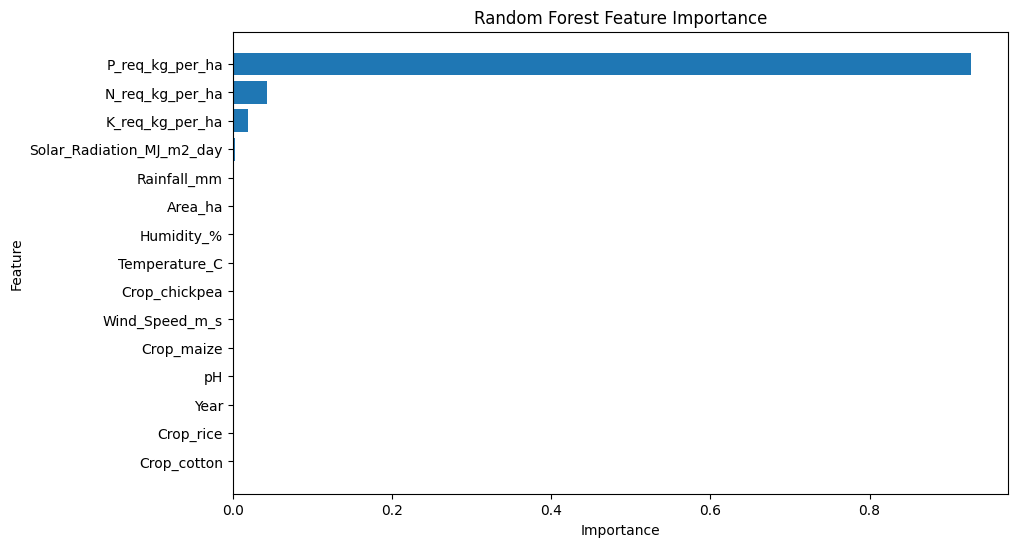

In [112]:
# ==========================================
# STEP 7 - RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== FEATURE IMPORTANCE =====")
print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [209]:
# ==========================================
# STEP 8 - CHECK FEATURE CORRELATION
# ==========================================

correlation = encoded_data.corr(numeric_only=True)["Yield_kg_per_ha"] \
    .sort_values(ascending=False)

print("===== CORRELATION WITH YIELD =====")
print(correlation)

===== CORRELATION WITH YIELD =====
Yield_kg_per_ha              1.000000
P_req_kg_per_ha              0.996933
N_req_kg_per_ha              0.988088
K_req_kg_per_ha              0.980872
Humidity_%                   0.404893
Rainfall_mm                  0.371172
Year                         0.312410
Crop_rice                    0.284893
Crop_maize                   0.275813
Area_ha                      0.150649
pH                           0.029041
Wind_Speed_m_s              -0.035667
Solar_Radiation_MJ_m2_day   -0.035667
Temperature_C               -0.074738
Crop_chickpea               -0.259424
Crop_cotton                 -0.382650
Name: Yield_kg_per_ha, dtype: float64


In [113]:
# ==========================================
# STEP 8 - RANDOM FOREST WITHOUT N/P/K
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Remove N, P and K requirement features
remove_features = [
    "N_req_kg_per_ha",
    "P_req_kg_per_ha",
    "K_req_kg_per_ha"
]

X_no_npk = encoded_data.drop(
    columns=["Yield_kg_per_ha"] + remove_features
)

y_no_npk = encoded_data["Yield_kg_per_ha"]

print("Features used:")
print(X_no_npk.columns.tolist())

print("\nX shape:", X_no_npk.shape)
print("y shape:", y_no_npk.shape)

Features used:
['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']

X shape: (50765, 12)
y shape: (50765,)


In [114]:
# ==========================================
# STEP 9 - TRAIN TEST SPLIT WITHOUT N/P/K
# ==========================================

X_train_no_npk, X_test_no_npk, y_train_no_npk, y_test_no_npk = train_test_split(
    X_no_npk,
    y_no_npk,
    test_size=0.20,
    random_state=42
)

print("===== TRAIN TEST SPLIT =====")
print("X_train:", X_train_no_npk.shape)
print("X_test :", X_test_no_npk.shape)
print("y_train:", y_train_no_npk.shape)
print("y_test :", y_test_no_npk.shape)

===== TRAIN TEST SPLIT =====
X_train: (40612, 12)
X_test : (10153, 12)
y_train: (40612,)
y_test : (10153,)


In [115]:
# ==========================================
# STEP 10 - RANDOM FOREST WITHOUT N/P/K
# ==========================================

rf_no_npk = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_no_npk.fit(X_train_no_npk, y_train_no_npk)

training_time_no_npk = time.time() - start_time

# Predictions
y_pred_no_npk = rf_no_npk.predict(X_test_no_npk)

# Evaluation
mae_no_npk = mean_absolute_error(y_test_no_npk, y_pred_no_npk)
rmse_no_npk = np.sqrt(
    mean_squared_error(y_test_no_npk, y_pred_no_npk)
)
r2_no_npk = r2_score(y_test_no_npk, y_pred_no_npk)

print("===== RANDOM FOREST WITHOUT N/P/K =====")
print("Training time:", round(training_time_no_npk, 2), "seconds")

print("\nMAE :", round(mae_no_npk, 2))
print("RMSE:", round(rmse_no_npk, 2))
print("R²  :", round(r2_no_npk, 4))

===== RANDOM FOREST WITHOUT N/P/K =====
Training time: 1.3 seconds

MAE : 476.46
RMSE: 758.28
R²  : 0.3782


In [116]:
# ==========================================
# STEP 1 - CHECK N/P/K FOR DATA LEAKAGE
# ==========================================

print("===== N/P/K vs YIELD CHECK =====")

print("\nCorrelation with Yield:")
print(
    weather_yield_data[
        [
            "N_req_kg_per_ha",
            "P_req_kg_per_ha",
            "K_req_kg_per_ha",
            "Yield_kg_per_ha"
        ]
    ].corr()["Yield_kg_per_ha"]
)

print("\nSample values:")

print(
    weather_yield_data[
        [
            "Crop",
            "Yield_kg_per_ha",
            "N_req_kg_per_ha",
            "P_req_kg_per_ha",
            "K_req_kg_per_ha"
        ]
    ].head(10)
)

===== N/P/K vs YIELD CHECK =====

Correlation with Yield:
N_req_kg_per_ha    0.988088
P_req_kg_per_ha    0.996933
K_req_kg_per_ha    0.980872
Yield_kg_per_ha    1.000000
Name: Yield_kg_per_ha, dtype: float64

Sample values:
       Crop  Yield_kg_per_ha  N_req_kg_per_ha  P_req_kg_per_ha  \
0      rice           337.59          8.43975          4.05108   
1     maize           666.67         18.00009          8.00004   
2  chickpea           500.00          9.00000          5.00000   
3      rice           747.71         18.69275          8.97252   
4     maize          1000.00         27.00000         12.00000   
5  chickpea           288.46          5.19228          2.88460   
6      rice           841.27         21.03175         10.09524   
7     maize           714.29         19.28583          8.57148   
8  chickpea           448.34          8.07012          4.48340   
9      rice           711.40         17.78500          8.53680   

   K_req_kg_per_ha  
0          7.42698  
1      

In [117]:
# ==========================================
# STEP - CREATE CLEAN DATA WITHOUT N/P/K
# ==========================================

# Features that are independent of yield
clean_features = [
    "Year",
    "Crop",
    "Area_ha",
    "Temperature_C",
    "Humidity_%",
    "pH",
    "Rainfall_mm",
    "Wind_Speed_m_s",
    "Solar_Radiation_MJ_m2_day"
]

target = "Yield_kg_per_ha"

# Create clean dataset
clean_data = weather_yield_data[clean_features + [target]].copy()

print("===== CLEAN DATASET =====")
print("Shape:", clean_data.shape)

print("\nFeatures:")
print(clean_features)

print("\nTarget:")
print(target)

print("\nMissing values:")
print(clean_data.isnull().sum())

===== CLEAN DATASET =====
Shape: (50765, 10)

Features:
['Year', 'Crop', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']

Target:
Yield_kg_per_ha

Missing values:
Year                         0
Crop                         0
Area_ha                      0
Temperature_C                0
Humidity_%                   0
pH                           0
Rainfall_mm                  0
Wind_Speed_m_s               0
Solar_Radiation_MJ_m2_day    0
Yield_kg_per_ha              0
dtype: int64


In [118]:
# ==========================================
# STEP - ENCODE CLEAN DATA
# ==========================================

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Separate features and target
X_clean = clean_data.drop("Yield_kg_per_ha", axis=1)
y_clean = clean_data["Yield_kg_per_ha"]

# One-hot encode Crop
encoder_clean = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

crop_encoded = encoder_clean.fit_transform(
    X_clean[["Crop"]]
)

# Get encoded crop column names
crop_columns = encoder_clean.get_feature_names_out(["Crop"])

# Convert encoded data into DataFrame
crop_encoded_df = pd.DataFrame(
    crop_encoded,
    columns=crop_columns,
    index=X_clean.index
)

# Remove original Crop column
X_clean = X_clean.drop("Crop", axis=1)

# Combine numerical features + encoded crop
X_clean_encoded = pd.concat(
    [X_clean, crop_encoded_df],
    axis=1
)

print("===== CLEAN ENCODED DATA =====")
print("X shape:", X_clean_encoded.shape)
print("y shape:", y_clean.shape)

print("\nColumns:")
print(X_clean_encoded.columns.tolist())

===== CLEAN ENCODED DATA =====
X shape: (50765, 12)
y shape: (50765,)

Columns:
['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [119]:
# ==========================================
# STEP - TRAIN TEST SPLIT (CLEAN DATA)
# ==========================================

from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean_encoded,
    y_clean,
    test_size=0.20,
    random_state=42
)

print("===== CLEAN TRAIN TEST SPLIT =====")

print("X_train shape:", X_train_clean.shape)
print("X_test shape :", X_test_clean.shape)
print("y_train shape:", y_train_clean.shape)
print("y_test shape :", y_test_clean.shape)

===== CLEAN TRAIN TEST SPLIT =====
X_train shape: (40612, 12)
X_test shape : (10153, 12)
y_train shape: (40612,)
y_test shape : (10153,)


In [120]:
# ==========================================
# STEP 6 - CLEAN RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Create model
rf_clean = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Start timer
start_time = time.time()

# Train model
rf_clean.fit(X_train_clean, y_train_clean)

# Training time
training_time_rf_clean = time.time() - start_time

# Predictions
y_pred_rf_clean = rf_clean.predict(X_test_clean)

# Evaluation
mae_rf_clean = mean_absolute_error(
    y_test_clean,
    y_pred_rf_clean
)

rmse_rf_clean = np.sqrt(
    mean_squared_error(
        y_test_clean,
        y_pred_rf_clean
    )
)

r2_rf_clean = r2_score(
    y_test_clean,
    y_pred_rf_clean
)

# Results
print("===== CLEAN RANDOM FOREST =====")
print("Training time:", round(training_time_rf_clean, 2), "seconds")

print("\nMAE :", round(mae_rf_clean, 2))
print("RMSE:", round(rmse_rf_clean, 2))
print("R²  :", round(r2_rf_clean, 4))

===== CLEAN RANDOM FOREST =====
Training time: 1.11 seconds

MAE : 476.46
RMSE: 758.28
R²  : 0.3782


In [38]:
# ==========================================
# STEP 7 - CLEAN XGBOOST
# ==========================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Create XGBoost model
xgb_clean = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Start timer
start_time = time.time()

# Train
xgb_clean.fit(X_train_clean, y_train_clean)

# Training time
training_time_xgb_clean = time.time() - start_time

# Predictions
y_pred_xgb_clean = xgb_clean.predict(X_test_clean)

# Evaluation
mae_xgb_clean = mean_absolute_error(
    y_test_clean,
    y_pred_xgb_clean
)

rmse_xgb_clean = np.sqrt(
    mean_squared_error(
        y_test_clean,
        y_pred_xgb_clean
    )
)

r2_xgb_clean = r2_score(
    y_test_clean,
    y_pred_xgb_clean
)

print("===== CLEAN XGBOOST =====")
print("Training time:", round(training_time_xgb_clean, 2), "seconds")

print("\nMAE :", round(mae_xgb_clean, 2))
print("RMSE:", round(rmse_xgb_clean, 2))
print("R²  :", round(r2_xgb_clean, 4))

===== CLEAN XGBOOST =====
Training time: 0.78 seconds

MAE : 427.17
RMSE: 673.19
R²  : 0.5099


In [121]:
# ==========================================
# STEP 8 - CLEAN LIGHTGBM
# ==========================================

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Create LightGBM model
lgb_clean = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Start timer
start_time = time.time()

# Train
lgb_clean.fit(X_train_clean, y_train_clean)

# Training time
training_time_lgb_clean = time.time() - start_time

# Predictions
y_pred_lgb_clean = lgb_clean.predict(X_test_clean)

# Evaluation
mae_lgb_clean = mean_absolute_error(
    y_test_clean,
    y_pred_lgb_clean
)

rmse_lgb_clean = np.sqrt(
    mean_squared_error(
        y_test_clean,
        y_pred_lgb_clean
    )
)

r2_lgb_clean = r2_score(
    y_test_clean,
    y_pred_lgb_clean
)

print("===== CLEAN LIGHTGBM =====")
print("Training time:", round(training_time_lgb_clean, 2), "seconds")

print("\nMAE :", round(mae_lgb_clean, 2))
print("RMSE:", round(rmse_lgb_clean, 2))
print("R²  :", round(r2_lgb_clean, 4))

===== CLEAN LIGHTGBM =====
Training time: 0.62 seconds

MAE : 427.74
RMSE: 672.54
R²  : 0.5109


In [122]:
# ==========================================
# STEP 9 - LIGHTGBM HYPERPARAMETER TUNING
# ==========================================

from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Base LightGBM model
lgb_base = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Parameters to test
param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 4, 6, 8, 10],
    "num_leaves": [15, 31, 50, 70],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Start timer
start_time = time.time()

# Perform tuning
random_search.fit(X_train_clean, y_train_clean)

tuning_time = time.time() - start_time

print("\n===== LIGHTGBM TUNING COMPLETE =====")
print("Tuning time:", round(tuning_time, 2), "seconds")

print("\nBest parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(
    round(
        np.sqrt(-random_search.best_score_),
        2
    )
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

===== LIGHTGBM TUNING COMPLETE =====
Tuning time: 46.85 seconds

Best parameters:
{'subsample': 0.7, 'num_leaves': 70, 'n_estimators': 700, 'min_child_samples': 30, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.9}

Best CV RMSE:
758.85


In [123]:
best_params = {
    'subsample': 0.7,
    'num_leaves': 70,
    'n_estimators': 700,
    'min_child_samples': 30,
    'max_depth': 4,
    'learning_rate': 0.03,
    'colsample_bytree': 0.9
}

In [124]:
import time
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# Create tuned LightGBM model
tuned_lgbm = LGBMRegressor(
    **best_params,
    random_state=42,
    verbosity=-1
)

# Training
start_time = time.time()

tuned_lgbm.fit(X_train, y_train)

training_time_tuned = time.time() - start_time

# Prediction
y_pred_tuned = tuned_lgbm.predict(X_test)

# Evaluation
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

rmse_tuned = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned)
)

r2_tuned = r2_score(y_test, y_pred_tuned)

print("===== TUNED LIGHTGBM =====")
print("Training time:", round(training_time_tuned, 2), "seconds")
print()
print("MAE :", round(mae_tuned, 2))
print("RMSE:", round(rmse_tuned, 2))
print("R²  :", round(r2_tuned, 4))

===== TUNED LIGHTGBM =====
Training time: 0.61 seconds

MAE : 13.09
RMSE: 95.82
R²  : 0.9901


In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on training data
y_train_pred_tuned = tuned_lgbm.predict(X_train)

# Predictions on test data
y_test_pred_tuned = tuned_lgbm.predict(X_test)

# Training metrics
mae_train = mean_absolute_error(y_train, y_train_pred_tuned)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned))
r2_train = r2_score(y_train, y_train_pred_tuned)

# Test metrics
mae_test = mean_absolute_error(y_test, y_test_pred_tuned)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
r2_test = r2_score(y_test, y_test_pred_tuned)

print("===== TUNED LIGHTGBM TRAINING =====")
print("MAE :", round(mae_train, 2))
print("RMSE:", round(rmse_train, 2))
print("R²  :", round(r2_train, 4))

print("\n===== TUNED LIGHTGBM TEST =====")
print("MAE :", round(mae_test, 2))
print("RMSE:", round(rmse_test, 2))
print("R²  :", round(r2_test, 4))

===== TUNED LIGHTGBM TRAINING =====
MAE : 13.28
RMSE: 228.45
R²  : 0.9494

===== TUNED LIGHTGBM TEST =====
MAE : 13.09
RMSE: 95.82
R²  : 0.9901


In [126]:
from sklearn.model_selection import train_test_split

# Features WITHOUT N/P/K
features_no_npk = [
    'Year',
    'Area_ha',
    'Temperature_C',
    'Humidity_%',
    'pH',
    'Rainfall_mm',
    'Wind_Speed_m_s',
    'Solar_Radiation_MJ_m2_day'
]

X_no_npk = encoded_data[features_no_npk]
y_no_npk = encoded_data["Yield_kg_per_ha"]

X_train_no_npk, X_test_no_npk, y_train_no_npk, y_test_no_npk = train_test_split(
    X_no_npk,
    y_no_npk,
    test_size=0.20,
    random_state=42
)

print("===== NO N/P/K SPLIT =====")
print("X_train:", X_train_no_npk.shape)
print("X_test :", X_test_no_npk.shape)
print("y_train:", y_train_no_npk.shape)
print("y_test :", y_test_no_npk.shape)

===== NO N/P/K SPLIT =====
X_train: (40612, 8)
X_test : (10153, 8)
y_train: (40612,)
y_test : (10153,)


In [127]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Create LightGBM model
lgbm_no_npk = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=70,
    min_child_samples=30,
    subsample=0.7,
    colsample_bytree=0.9,
    random_state=42,
    verbosity=-1
)

# Training
start_time = time.time()

lgbm_no_npk.fit(X_train_no_npk, y_train_no_npk)

training_time = time.time() - start_time

# Prediction
y_pred_no_npk = lgbm_no_npk.predict(X_test_no_npk)

# Evaluation
mae_no_npk = mean_absolute_error(y_test_no_npk, y_pred_no_npk)

rmse_no_npk = np.sqrt(
    mean_squared_error(y_test_no_npk, y_pred_no_npk)
)

r2_no_npk = r2_score(y_test_no_npk, y_pred_no_npk)

print("===== LIGHTGBM WITHOUT N/P/K =====")
print("Training time:", round(training_time, 2), "seconds")
print()
print("MAE :", round(mae_no_npk, 2))
print("RMSE:", round(rmse_no_npk, 2))
print("R²  :", round(r2_no_npk, 4))

===== LIGHTGBM WITHOUT N/P/K =====
Training time: 0.77 seconds

MAE : 429.32
RMSE: 673.28
R²  : 0.5098


===== FEATURE IMPORTANCE =====
                     Feature  Importance
1                    Area_ha        4192
0                       Year        3376
2              Temperature_C        1015
3                 Humidity_%         861
4                         pH         301
5                Rainfall_mm         102
6             Wind_Speed_m_s          56
7  Solar_Radiation_MJ_m2_day           0


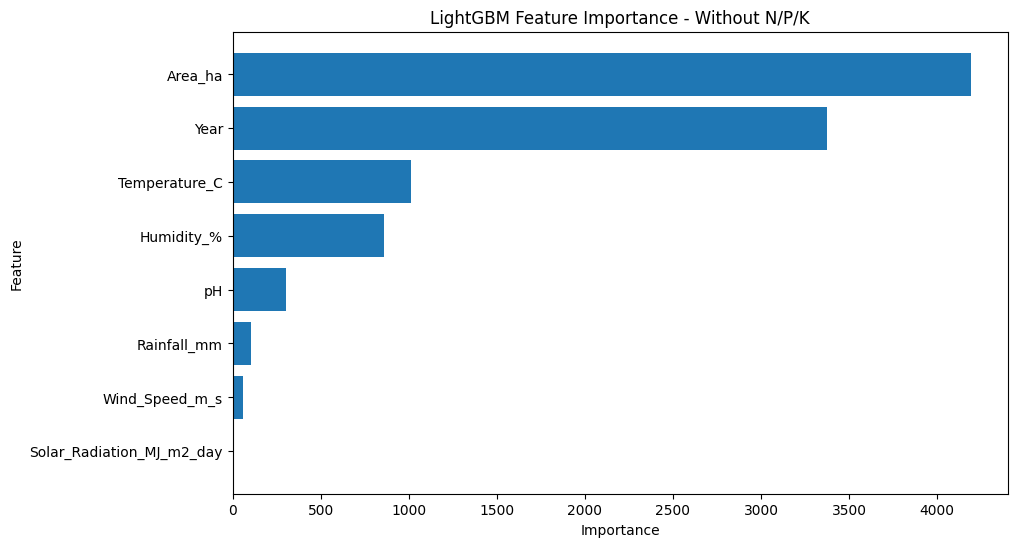

In [128]:
# ==========================================
# FEATURE IMPORTANCE - NO N/P/K LIGHTGBM
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X_train_no_npk.columns,
    "Importance": lgbm_no_npk.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("===== FEATURE IMPORTANCE =====")
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance - Without N/P/K")
plt.gca().invert_yaxis()

plt.show()

In [51]:
print("Available variables:")
print([x for x in globals() if "data" in x.lower()])

Available variables:
['crop_data', 'crop_model_data', 'fertilizer_data', 'weather_data', 'weather_yield_data', 'yield_data', 'yield_data_encoded', 'encoded_data', 'clean_data']


In [129]:
print("===== DATA LEAKAGE CHECK =====")

cols = [
    "N_req_kg_per_ha",
    "P_req_kg_per_ha",
    "K_req_kg_per_ha",
    "Yield_kg_per_ha"
]

print("\n===== CORRELATION WITH YIELD =====")

print(
    weather_yield_data[cols]
    .corr()["Yield_kg_per_ha"]
    .sort_values(ascending=False)
)

print("\n===== SAMPLE N/P/K + YIELD =====")

print(
    weather_yield_data[
        [
            "Crop",
            "Yield_kg_per_ha",
            "N_req_kg_per_ha",
            "P_req_kg_per_ha",
            "K_req_kg_per_ha"
        ]
    ].head(10)
)

===== DATA LEAKAGE CHECK =====

===== CORRELATION WITH YIELD =====
Yield_kg_per_ha    1.000000
P_req_kg_per_ha    0.996933
N_req_kg_per_ha    0.988088
K_req_kg_per_ha    0.980872
Name: Yield_kg_per_ha, dtype: float64

===== SAMPLE N/P/K + YIELD =====
       Crop  Yield_kg_per_ha  N_req_kg_per_ha  P_req_kg_per_ha  \
0      rice           337.59          8.43975          4.05108   
1     maize           666.67         18.00009          8.00004   
2  chickpea           500.00          9.00000          5.00000   
3      rice           747.71         18.69275          8.97252   
4     maize          1000.00         27.00000         12.00000   
5  chickpea           288.46          5.19228          2.88460   
6      rice           841.27         21.03175         10.09524   
7     maize           714.29         19.28583          8.57148   
8  chickpea           448.34          8.07012          4.48340   
9      rice           711.40         17.78500          8.53680   

   K_req_kg_per_ha  
0

In [130]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import time

print("===== LIGHTGBM TUNING WITHOUT N/P/K =====")

param_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "num_leaves": [20, 31, 50, 70, 100],
    "max_depth": [-1, 3, 4, 5, 7, 10],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

base_lgbm = LGBMRegressor(
    random_state=42,
    verbosity=-1
)

start_time = time.time()

random_search_no_npk = RandomizedSearchCV(
    estimator=base_lgbm,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_no_npk.fit(
    X_train_no_npk,
    y_train_no_npk
)

tuning_time = time.time() - start_time

print("\n===== TUNING COMPLETE =====")
print("Tuning time:", round(tuning_time, 2), "seconds")

print("\nBest parameters:")
print(random_search_no_npk.best_params_)

print("\nBest CV RMSE:")
print(round(-random_search_no_npk.best_score_, 2))

===== LIGHTGBM TUNING WITHOUT N/P/K =====
Fitting 3 folds for each of 20 candidates, totalling 60 fits

===== TUNING COMPLETE =====
Tuning time: 53.68 seconds

Best parameters:
{'subsample': 0.7, 'num_leaves': 50, 'n_estimators': 1000, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best CV RMSE:
757.12


In [131]:
from lightgbm import LGBMRegressor
import time

best_params_no_npk = random_search_no_npk.best_params_

tuned_lgbm_no_npk = LGBMRegressor(
    **best_params_no_npk,
    random_state=42,
    verbosity=-1
)

start_time = time.time()

tuned_lgbm_no_npk.fit(
    X_train_no_npk,
    y_train_no_npk
)

training_time = time.time() - start_time

print("===== TUNED LIGHTGBM WITHOUT N/P/K =====")
print("Training time:", round(training_time, 2), "seconds")

===== TUNED LIGHTGBM WITHOUT N/P/K =====
Training time: 0.95 seconds


In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_tuned_no_npk = tuned_lgbm_no_npk.predict(X_test_no_npk)

mae_tuned_no_npk = mean_absolute_error(
    y_test_no_npk,
    y_pred_tuned_no_npk
)

rmse_tuned_no_npk = np.sqrt(
    mean_squared_error(
        y_test_no_npk,
        y_pred_tuned_no_npk
    )
)

r2_tuned_no_npk = r2_score(
    y_test_no_npk,
    y_pred_tuned_no_npk
)

print("===== TUNED LIGHTGBM WITHOUT N/P/K RESULTS =====")
print("MAE :", round(mae_tuned_no_npk, 2))
print("RMSE:", round(rmse_tuned_no_npk, 2))
print("R²  :", round(r2_tuned_no_npk, 4))

===== TUNED LIGHTGBM WITHOUT N/P/K RESULTS =====
MAE : 431.91
RMSE: 675.44
R²  : 0.5067


In [133]:
import pandas as pd
import numpy as np

# Create results dataframe
results = pd.DataFrame({
    "Actual": y_test_no_npk,
    "Predicted": y_pred_no_npk
})

# Calculate error
results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = abs(results["Error"])
results["Percentage_Error"] = (
    results["Absolute_Error"] /
    results["Actual"].replace(0, np.nan)
) * 100

print("===== PREDICTION ERROR ANALYSIS =====")

print("\nOverall statistics:")
print(results[[
    "Actual",
    "Predicted",
    "Absolute_Error",
    "Percentage_Error"
]].describe())


===== PREDICTION ERROR ANALYSIS =====

Overall statistics:
             Actual     Predicted  Absolute_Error  Percentage_Error
count  10153.000000  10153.000000    10153.000000      10153.000000
mean    1159.326285   1147.242205      429.318092         85.581729
std      961.683447    668.243330      518.674562       2050.966258
min        0.450000     19.420852        0.016946          0.002372
25%      500.000000    627.181913      110.391121         15.029887
50%      909.090000   1071.317683      268.240841         31.776787
75%     1555.560000   1565.750353      564.837665         58.342832
max    11120.220000   3841.104760     8404.704398     160243.258281


In [134]:
print("===== CROP-WISE PERFORMANCE =====")

# Get crop information from the original test data
crop_test = clean_data.loc[y_test_no_npk.index, "Crop"]

crop_results = pd.DataFrame({
    "Crop": crop_test.values,
    "Actual": y_test_no_npk.values,
    "Predicted": y_pred_no_npk
})

crop_results["Absolute_Error"] = abs(
    crop_results["Actual"] - crop_results["Predicted"]
)

# Calculate performance for each crop
crop_summary = crop_results.groupby("Crop").agg(
    Samples=("Actual", "count"),
    Actual_Mean=("Actual", "mean"),
    Predicted_Mean=("Predicted", "mean"),
    MAE=("Absolute_Error", "mean")
)

print(crop_summary.round(2))

===== CROP-WISE PERFORMANCE =====
          Samples  Actual_Mean  Predicted_Mean     MAE
Crop                                                  
chickpea     2807       722.49          731.12  228.81
cotton       1572       258.75          260.13  126.21
maize        2797      1622.46         1579.68  661.84
rice         2977      1611.63         1601.74  559.96


In [135]:
from sklearn.metrics import r2_score
import numpy as np

print("\n===== CROP-WISE R² =====")

for crop in crop_results["Crop"].unique():

    data = crop_results[crop_results["Crop"] == crop]

    r2 = r2_score(
        data["Actual"],
        data["Predicted"]
    )

    rmse = np.sqrt(
        np.mean(
            (data["Actual"] - data["Predicted"]) ** 2
        )
    )

    print(
        crop,
        "| MAE:", round(data["Absolute_Error"].mean(), 2),
        "| RMSE:", round(rmse, 2),
        "| R²:", round(r2, 4)
    )


===== CROP-WISE R² =====
rice | MAE: 559.96 | RMSE: 719.04 | R²: 0.3335
chickpea | MAE: 228.81 | RMSE: 318.18 | R²: 0.1521
maize | MAE: 661.84 | RMSE: 982.11 | R²: 0.2558
cotton | MAE: 126.21 | RMSE: 227.45 | R²: 0.1856


In [136]:
print("===== CROP DISTRIBUTION =====")

print(clean_data["Crop"].value_counts())

print("\n===== CROP-WISE AVERAGE YIELD =====")

print(
    clean_data.groupby("Crop")["Yield_kg_per_ha"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

===== CROP DISTRIBUTION =====
Crop
rice        14978
maize       14136
chickpea    13847
cotton       7804
Name: count, dtype: int64

===== CROP-WISE AVERAGE YIELD =====
          count     mean      std   min       max
Crop                                             
chickpea  13847   734.08   651.69  3.08  58363.64
cotton     7804   257.47   234.34  0.28   5000.00
maize     14136  1606.04  1140.15  3.35  21428.57
rice      14978  1602.41   894.49  9.12   5653.83


In [60]:
print("===== EXTREME YIELD VALUES =====")

extreme_rows = clean_data[
    clean_data["Yield_kg_per_ha"] > 5000
].sort_values(
    "Yield_kg_per_ha",
    ascending=False
)

print(
    extreme_rows[
        [
            "Year",
            "Crop",
            "Area_ha",
            "Temperature_C",
            "Humidity_%",
            "pH",
            "Rainfall_mm",
            "Yield_kg_per_ha"
        ]
    ].head(20)
)

===== EXTREME YIELD VALUES =====
       Year      Crop   Area_ha  Temperature_C  Humidity_%   pH  Rainfall_mm  \
48486  2007  chickpea     110.0             20          60  6.5          600   
48786  2007  chickpea      30.0             20          60  6.5          600   
31641  2016     maize     700.0             22          70  6.0          800   
9198   2017     maize    3370.0             22          70  6.0          800   
8368   2010     maize   84490.0             22          70  6.0          800   
8396   2017     maize   66400.0             22          70  6.0          800   
14664  2015     maize      10.0             22          70  6.0          800   
15604  2017     maize   88690.0             22          70  6.0          800   
8360   2008     maize   99610.0             22          70  6.0          800   
8348   2005     maize   26940.0             22          70  6.0          800   
7835   2017     maize   11800.0             22          70  6.0          800   
8384   

In [61]:
print("\n===== EXTREME VALUES BY CROP =====")

for crop in clean_data["Crop"].unique():

    data = clean_data[
        clean_data["Crop"] == crop
    ]

    print(
        crop,
        "| Max yield:",
        round(data["Yield_kg_per_ha"].max(), 2)
    )


===== EXTREME VALUES BY CROP =====
rice | Max yield: 5653.83
maize | Max yield: 21428.57
chickpea | Max yield: 58363.64
cotton | Max yield: 5000.0


In [137]:
print("===== EXTREME YIELD RECORDS =====")

extreme_rows = clean_data[
    clean_data["Yield_kg_per_ha"] > 5000
].sort_values(
    "Yield_kg_per_ha",
    ascending=False
)

print(
    extreme_rows[
        [
            "Year",
            "Crop",
            "Area_ha",
            "Temperature_C",
            "Humidity_%",
            "pH",
            "Rainfall_mm",
            "Yield_kg_per_ha"
        ]
    ].head(20)
)

===== EXTREME YIELD RECORDS =====
       Year      Crop   Area_ha  Temperature_C  Humidity_%   pH  Rainfall_mm  \
48486  2007  chickpea     110.0             20          60  6.5          600   
48786  2007  chickpea      30.0             20          60  6.5          600   
31641  2016     maize     700.0             22          70  6.0          800   
9198   2017     maize    3370.0             22          70  6.0          800   
8368   2010     maize   84490.0             22          70  6.0          800   
8396   2017     maize   66400.0             22          70  6.0          800   
14664  2015     maize      10.0             22          70  6.0          800   
15604  2017     maize   88690.0             22          70  6.0          800   
8360   2008     maize   99610.0             22          70  6.0          800   
8348   2005     maize   26940.0             22          70  6.0          800   
7835   2017     maize   11800.0             22          70  6.0          800   
8384  

In [63]:
print("===== CROP-WISE OUTLIER ANALYSIS =====")

for crop in clean_data["Crop"].unique():

    data = clean_data[
        clean_data["Crop"] == crop
    ]["Yield_kg_per_ha"]

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data < lower) | (data > upper)
    ]

    print(f"\n{crop}")
    print("Q1:", round(Q1, 2))
    print("Q3:", round(Q3, 2))
    print("Lower limit:", round(lower, 2))
    print("Upper limit:", round(upper, 2))
    print("Outliers:", len(outliers))
    print("Percentage:", round(len(outliers) / len(data) * 100, 2), "%")

===== CROP-WISE OUTLIER ANALYSIS =====

rice
Q1: 920.61
Q3: 2177.15
Lower limit: -964.2
Upper limit: 4061.96
Outliers: 179
Percentage: 1.2 %

maize
Q1: 909.09
Q3: 2000.0
Lower limit: -727.27
Upper limit: 3636.36
Outliers: 708
Percentage: 5.01 %

chickpea
Q1: 499.44
Q3: 930.59
Lower limit: -147.27
Upper limit: 1577.31
Outliers: 258
Percentage: 1.86 %

cotton
Q1: 121.32
Q3: 333.33
Lower limit: -196.71
Upper limit: 651.35
Outliers: 258
Percentage: 3.31 %


In [138]:
# ==========================================
# STEP - CREATE OUTLIER-TREATED DATASET
# ==========================================

import pandas as pd

outlier_clean_data = clean_data.copy()

# Keep track of rows to remove
rows_to_remove = []

for crop in outlier_clean_data["Crop"].unique():

    crop_mask = outlier_clean_data["Crop"] == crop

    crop_yield = outlier_clean_data.loc[
        crop_mask,
        "Yield_kg_per_ha"
    ]

    Q1 = crop_yield.quantile(0.25)
    Q3 = crop_yield.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Find outlier rows
    outlier_indices = outlier_clean_data[
        crop_mask &
        (
            (outlier_clean_data["Yield_kg_per_ha"] < lower) |
            (outlier_clean_data["Yield_kg_per_ha"] > upper)
        )
    ].index

    rows_to_remove.extend(outlier_indices)

# Remove outliers
outlier_clean_data = outlier_clean_data.drop(
    index=rows_to_remove
)

print("===== OUTLIER-TREATED DATASET =====")

print("Original rows :", len(clean_data))
print("Removed rows  :", len(rows_to_remove))
print("Remaining rows:", len(outlier_clean_data))

===== OUTLIER-TREATED DATASET =====
Original rows : 50765
Removed rows  : 1403
Remaining rows: 49362


In [139]:
print("===== NEW CROP DISTRIBUTION =====")

print(
    outlier_clean_data["Crop"].value_counts()
)

print("\n===== NEW YIELD STATISTICS =====")

print(
    outlier_clean_data
    .groupby("Crop")["Yield_kg_per_ha"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

===== NEW CROP DISTRIBUTION =====
Crop
rice        14799
chickpea    13589
maize       13428
cotton       7546
Name: count, dtype: int64

===== NEW YIELD STATISTICS =====
          count     mean     std   min      max
Crop                                           
chickpea  13589   705.77  295.68  3.08  1577.18
cotton     7546   231.26  138.23  0.28   651.01
maize     13428  1420.12  745.20  3.35  3634.02
rice      14799  1568.20  843.06  9.12  4056.81


In [140]:
# ==========================================
# XGBOOST ON OUTLIER-TREATED DATA
# ==========================================

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Features WITHOUT N/P/K
features_no_npk = [
    "Year",
    "Area_ha",
    "Temperature_C",
    "Humidity_%",
    "pH",
    "Rainfall_mm",
    "Wind_Speed_m_s",
    "Solar_Radiation_MJ_m2_day"
]

X_clean = outlier_clean_data[features_no_npk]
y_clean = outlier_clean_data["Yield_kg_per_ha"]

# Train-test split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42
)

print("===== CLEANED DATA SPLIT =====")
print("Training rows:", len(X_train_clean))
print("Testing rows :", len(X_test_clean))

# XGBoost model
xgb_clean = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

start_time = time.time()

xgb_clean.fit(
    X_train_clean,
    y_train_clean
)

training_time = time.time() - start_time

# Prediction
y_pred_clean = xgb_clean.predict(X_test_clean)

# Evaluation
mae_clean = mean_absolute_error(
    y_test_clean,
    y_pred_clean
)

rmse_clean = np.sqrt(
    mean_squared_error(
        y_test_clean,
        y_pred_clean
    )
)

r2_clean = r2_score(
    y_test_clean,
    y_pred_clean
)

print("\n===== XGBOOST AFTER OUTLIER REMOVAL =====")
print("Training time:", round(training_time, 2), "seconds")
print("MAE :", round(mae_clean, 2))
print("RMSE:", round(rmse_clean, 2))
print("R²  :", round(r2_clean, 4))

===== CLEANED DATA SPLIT =====
Training rows: 39489
Testing rows : 9873



===== XGBOOST AFTER OUTLIER REMOVAL =====
Training time: 1.21 seconds
MAE : 373.29
RMSE: 530.87
R²  : 0.5585


In [143]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

feature_data = outlier_clean_data.copy()

# Weather interaction features
feature_data["Temp_Humidity"] = (
    feature_data["Temperature_C"] *
    feature_data["Humidity_%"]
)

feature_data["Temp_Rainfall"] = (
    feature_data["Temperature_C"] *
    feature_data["Rainfall_mm"]
)

feature_data["Humidity_Rainfall"] = (
    feature_data["Humidity_%"] *
    feature_data["Rainfall_mm"]
)

# Rainfall relative to temperature
feature_data["Rainfall_Temp_Ratio"] = (
    feature_data["Rainfall_mm"] /
    (feature_data["Temperature_C"] + 1)
)

# Solar and temperature interaction
feature_data["Solar_Temp"] = (
    feature_data["Solar_Radiation_MJ_m2_day"] *
    feature_data["Temperature_C"]
)

print("===== FEATURE ENGINEERING COMPLETE =====")

print(
    feature_data[
        [
            "Temperature_C",
            "Humidity_%",
            "Rainfall_mm",
            "Temp_Humidity",
            "Temp_Rainfall",
            "Humidity_Rainfall",
            "Rainfall_Temp_Ratio",
            "Solar_Temp"
        ]
    ].head()
)

===== FEATURE ENGINEERING COMPLETE =====
   Temperature_C  Humidity_%  Rainfall_mm  Temp_Humidity  Temp_Rainfall  \
0             25          80         1200           2000          30000   
1             22          70          800           1540          17600   
2             20          60          600           1200          12000   
3             25          80         1200           2000          30000   
4             22          70          800           1540          17600   

   Humidity_Rainfall  Rainfall_Temp_Ratio  Solar_Temp  
0              96000            46.153846         450  
1              56000            34.782609         440  
2              36000            28.571429         320  
3              96000            46.153846         450  
4              56000            34.782609         440  


In [144]:
engineered_features = [
    "Year",
    "Area_ha",
    "Temperature_C",
    "Humidity_%",
    "pH",
    "Rainfall_mm",
    "Wind_Speed_m_s",
    "Solar_Radiation_MJ_m2_day",
    "Temp_Humidity",
    "Temp_Rainfall",
    "Humidity_Rainfall",
    "Rainfall_Temp_Ratio",
    "Solar_Temp"
]

X_engineered = feature_data[engineered_features]

y_engineered = feature_data["Yield_kg_per_ha"]

print("Number of features:", X_engineered.shape[1])
print("Number of records :", X_engineered.shape[0])

Number of features: 13
Number of records : 49362


In [145]:
# ==========================================
# XGBOOST WITH FEATURE ENGINEERING
# ==========================================

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Train-test split
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.20,
    random_state=42
)

print("===== ENGINEERED DATA SPLIT =====")
print("Training rows:", len(X_train_eng))
print("Testing rows :", len(X_test_eng))

# XGBoost
xgb_engineered = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

start_time = time.time()

xgb_engineered.fit(
    X_train_eng,
    y_train_eng
)

training_time = time.time() - start_time

# Prediction
y_pred_eng = xgb_engineered.predict(X_test_eng)

# Evaluation
mae_eng = mean_absolute_error(
    y_test_eng,
    y_pred_eng
)

rmse_eng = np.sqrt(
    mean_squared_error(
        y_test_eng,
        y_pred_eng
    )
)

r2_eng = r2_score(
    y_test_eng,
    y_pred_eng
)

print("\n===== XGBOOST WITH FEATURE ENGINEERING =====")
print("Training time:", round(training_time, 2), "seconds")
print("MAE :", round(mae_eng, 2))
print("RMSE:", round(rmse_eng, 2))
print("R²  :", round(r2_eng, 4))

===== ENGINEERED DATA SPLIT =====
Training rows: 39489
Testing rows : 9873

===== XGBOOST WITH FEATURE ENGINEERING =====
Training time: 1.33 seconds
MAE : 372.87
RMSE: 530.42
R²  : 0.5592


In [146]:
print("===== CROP ENCODING =====")

print(yield_data_encoded.head())

print("\nColumns:")
print(yield_data_encoded.columns.tolist())

===== CROP ENCODING =====
   Year   Area_ha  N_req_kg_per_ha  P_req_kg_per_ha  K_req_kg_per_ha  \
0  1966  548000.0          8.43975          4.05108          7.42698   
1  1966    3000.0         18.00009          8.00004         11.33339   
2  1966   54000.0          9.00000          5.00000          9.00000   
3  1967  547000.0         18.69275          8.97252         16.44962   
4  1967    3000.0         27.00000         12.00000         17.00000   

   Temperature_C  Humidity_%   pH  Rainfall_mm  Wind_Speed_m_s  \
0             25          80  6.5         1200             2.0   
1             22          70  6.0          800             2.5   
2             20          60  6.5          600             1.5   
3             25          80  6.5         1200             2.0   
4             22          70  6.0          800             2.5   

   Solar_Radiation_MJ_m2_day  Yield_kg_per_ha  Crop_chickpea  Crop_cotton  \
0                         18           337.59          False       

In [147]:
# ==========================================
# ADD CROP ENCODING
# ==========================================

feature_data_crop = outlier_clean_data.copy()

# One-hot encode Crop
feature_data_crop = pd.get_dummies(
    feature_data_crop,
    columns=["Crop"],
    prefix="Crop"
)

print("===== CROP ENCODING COMPLETE =====")

print(
    feature_data_crop[
        [
            "Crop_chickpea",
            "Crop_cotton",
            "Crop_maize",
            "Crop_rice"
        ]
    ].head()
)

===== CROP ENCODING COMPLETE =====
   Crop_chickpea  Crop_cotton  Crop_maize  Crop_rice
0          False        False       False       True
1          False        False        True      False
2           True        False       False      False
3          False        False       False       True
4          False        False        True      False


In [148]:
# ==========================================
# ADD ENGINEERED FEATURES
# ==========================================

feature_data_crop["Temp_Humidity"] = (
    feature_data_crop["Temperature_C"] *
    feature_data_crop["Humidity_%"]
)

feature_data_crop["Temp_Rainfall"] = (
    feature_data_crop["Temperature_C"] *
    feature_data_crop["Rainfall_mm"]
)

feature_data_crop["Humidity_Rainfall"] = (
    feature_data_crop["Humidity_%"] *
    feature_data_crop["Rainfall_mm"]
)

feature_data_crop["Rainfall_Temp_Ratio"] = (
    feature_data_crop["Rainfall_mm"] /
    (feature_data_crop["Temperature_C"] + 1)
)

feature_data_crop["Solar_Temp"] = (
    feature_data_crop["Solar_Radiation_MJ_m2_day"] *
    feature_data_crop["Temperature_C"]
)

print("Features created successfully!")

Features created successfully!


In [149]:
# ==========================================
# FINAL FEATURES WITH CROP
# ==========================================

final_features = [
    "Year",
    "Area_ha",
    "Temperature_C",
    "Humidity_%",
    "pH",
    "Rainfall_mm",
    "Wind_Speed_m_s",
    "Solar_Radiation_MJ_m2_day",

    # Engineered features
    "Temp_Humidity",
    "Temp_Rainfall",
    "Humidity_Rainfall",
    "Rainfall_Temp_Ratio",
    "Solar_Temp",

    # Crop features
    "Crop_chickpea",
    "Crop_cotton",
    "Crop_maize",
    "Crop_rice"
]

X_final = feature_data_crop[final_features]

y_final = feature_data_crop["Yield_kg_per_ha"]

print("===== FINAL FEATURE SET =====")
print("Number of features:", X_final.shape[1])
print("Number of records :", X_final.shape[0])

===== FINAL FEATURE SET =====
Number of features: 17
Number of records : 49362


In [150]:
# ==========================================
# XGBOOST WITH CROP + FEATURE ENGINEERING
# ==========================================

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Train-test split
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42
)

print("===== FINAL DATA SPLIT =====")
print("Training rows:", len(X_train_final))
print("Testing rows :", len(X_test_final))

# Create XGBoost model
xgb_final_candidate = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

# Train
start_time = time.time()

xgb_final_candidate.fit(
    X_train_final,
    y_train_final
)

training_time = time.time() - start_time

# Predict
y_pred_final = xgb_final_candidate.predict(X_test_final)

# Evaluation
mae_final = mean_absolute_error(
    y_test_final,
    y_pred_final
)

rmse_final = np.sqrt(
    mean_squared_error(
        y_test_final,
        y_pred_final
    )
)

r2_final = r2_score(
    y_test_final,
    y_pred_final
)

print("\n===== XGBOOST WITH CROP + FEATURE ENGINEERING =====")
print("Training time:", round(training_time, 2), "seconds")
print("MAE :", round(mae_final, 2))
print("RMSE:", round(rmse_final, 2))
print("R²  :", round(r2_final, 4))

===== FINAL DATA SPLIT =====
Training rows: 39489
Testing rows : 9873

===== XGBOOST WITH CROP + FEATURE ENGINEERING =====
Training time: 1.14 seconds
MAE : 373.27
RMSE: 530.8
R²  : 0.5586


In [151]:
print("===== CLEAN DATA COLUMNS =====")
print(clean_data.columns.tolist())

print("\n===== ENCODED DATA COLUMNS =====")
print(yield_data_encoded.columns.tolist())

===== CLEAN DATA COLUMNS =====
['Year', 'Crop', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Yield_kg_per_ha']

===== ENCODED DATA COLUMNS =====
['Year', 'Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Yield_kg_per_ha', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [152]:
# ==========================================
# FERTILIZER REQUIREMENT ANALYSIS
# ==========================================

print("===== FERTILIZER REQUIREMENTS BY CROP =====")

fertilizer_summary = yield_data_encoded.groupby(
    [
        "Crop_chickpea",
        "Crop_cotton",
        "Crop_maize",
        "Crop_rice"
    ]
)[
    [
        "N_req_kg_per_ha",
        "P_req_kg_per_ha",
        "K_req_kg_per_ha"
    ]
].mean()

print(fertilizer_summary.round(2))

===== FERTILIZER REQUIREMENTS BY CROP =====
                                                N_req_kg_per_ha  \
Crop_chickpea Crop_cotton Crop_maize Crop_rice                    
False         False       False      True                 40.06   
                          True       False                43.36   
              True        False      False                 6.95   
True          False       False      False                13.21   

                                                P_req_kg_per_ha  \
Crop_chickpea Crop_cotton Crop_maize Crop_rice                    
False         False       False      True                 19.23   
                          True       False                19.27   
              True        False      False                 3.09   
True          False       False      False                 7.34   

                                                K_req_kg_per_ha  
Crop_chickpea Crop_cotton Crop_maize Crop_rice                   
False         Fals

In [10]:
print("Current variables:")
print([x for x in globals() if not x.startswith("_")])

Current variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'os', 'fertilizer', 'production', 'weather_yield', 'crop_data']


In [9]:
print("Pandas available:", "pd" in globals())
print("NumPy available:", "np" in globals())

Pandas available: True
NumPy available: True


In [8]:
import pandas as pd
import numpy as np
import os

print(os.getcwd())
print(os.listdir())

d:\AgriNexa\notebooks
['analysis.ipynb']


In [5]:
import pandas as pd
import numpy as np

In [12]:
print([x for x in globals() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'os', 'fertilizer', 'production', 'weather_yield', 'crop_data']


In [13]:
print("===== CROP DATA =====")
print(crop_data.shape)
print(crop_data.columns.tolist())
print(crop_data.head())

===== CROP DATA =====
(575879, 8)
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'yield']
                    State_Name District_Name  Crop_Year      Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
1  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
2  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   

                  Crop    Area  Production     yield  
0             Arecanut  1254.0      2000.0  1.594896  
1  Other Kharif pulses     2.0         1.0  0.500000  
2                 Rice   102.0       321.0  3.147059  
3               Banana   176.0       641.0  3.642045  
4            Cashewnut   720.0       165.0  0.229167  


In [14]:
print("\n===== FERTILIZER DATA =====")
print(fertilizer.shape)
print(fertilizer.columns.tolist())
print(fertilizer.head())


===== FERTILIZER DATA =====
(4513, 11)
['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer', 'Link']
  District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  \
0      Kolhapur      Black        75          50        100  6.5      1000   
1      Kolhapur      Black        80          50        100  6.5      1000   
2      Kolhapur      Black        85          50        100  6.5      1000   
3      Kolhapur      Black        90          50        100  6.5      1000   
4      Kolhapur      Black        95          50        100  6.5      1000   

   Temperature       Crop Fertilizer                          Link  
0           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
1           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
2           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
3           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
4           

In [153]:
# ==========================================
# FERTILIZER DATASET ANALYSIS
# ==========================================

print("===== FERTILIZER DATASET =====")

print("Rows:", fertilizer.shape[0])
print("Columns:", fertilizer.shape[1])

print("\n===== CROPS =====")
print(fertilizer["Crop"].value_counts())

print("\n===== FERTILIZER TYPES =====")
print(fertilizer["Fertilizer"].value_counts())

===== FERTILIZER DATASET =====
Rows: 4513
Columns: 11

===== CROPS =====
Crop
Sugarcane    1010
Wheat         859
Cotton        650
Jowar         394
Maize         350
Rice          309
Groundnut     177
Tur           126
Ginger        125
Grapes        125
Urad           99
Moong          99
Gram           78
Turmeric       55
Soybean        45
Masoor         12
Name: count, dtype: int64

===== FERTILIZER TYPES =====
Fertilizer
Urea                      1364
DAP                        667
MOP                        571
19:19:19 NPK               480
SSP                        417
Magnesium Sulphate         215
10:26:26 NPK               156
50:26:26 NPK               124
Chilated Micronutrient     108
12:32:16 NPK               106
Ferrous Sulphate            68
13:32:26 NPK                66
Ammonium Sulphate           50
10:10:10 NPK                50
Hydrated Lime               25
White Potash                19
20:20:20 NPK                15
18:46:00 NPK                 6
Sulphur  

In [16]:
# ==========================================
# CROP → FERTILIZER SUMMARY
# ==========================================

crop_fertilizer_summary = (
    fertilizer.groupby("Crop")["Fertilizer"]
    .unique()
)

for crop, fertilizers in crop_fertilizer_summary.items():
    print(f"\n{crop}:")
    for fert in fertilizers:
        print("  -", fert)


Cotton:
  - DAP
  - Magnesium Sulphate
  - 13:32:26 NPK
  - 12:32:16 NPK

Ginger:
  - Urea
  - Ammonium Sulphate
  - DAP

Gram:
  - 18:46:00 NPK
  - Sulphur
  - DAP
  - MOP

Grapes:
  - Ferrous Sulphate
  - 10:10:10 NPK
  - Hydrated Lime

Groundnut:
  - Chilated Micronutrient
  - SSP

Jowar:
  - 10:26:26 NPK
  - Urea
  - SSP

Maize:
  - Urea
  - SSP
  - MOP

Masoor:
  - Urea
  - DAP

Moong:
  - MOP
  - Urea
  - SSP

Rice:
  - Urea
  - 50:26:26 NPK

Soybean:
  - Urea
  - 20:20:20 NPK
  - SSP

Sugarcane:
  - Urea
  - DAP
  - MOP

Tur:
  - Urea
  - MOP
  - SSP

Turmeric:
  - Urea
  - Ferrous Sulphate
  - White Potash

Urad:
  - Urea
  - SSP
  - DAP

Wheat:
  - 19:19:19 NPK
  - Urea


In [155]:
# ==========================================
# FERTILIZER vs SOIL N/P/K
# ==========================================

fertilizer_analysis = (
    fertilizer.groupby(["Crop", "Fertilizer"])[
        ["Nitrogen", "Phosphorus", "Potassium"]
    ]
    .agg(["count", "mean", "min", "max"])
)

print(fertilizer_analysis.round(2).to_string())

                                 Nitrogen                   Phosphorus                Potassium                  
                                    count    mean  min  max      count   mean min max     count    mean  min  max
Crop      Fertilizer                                                                                             
Cotton    12:32:16 NPK                106  109.91  100  120        106  62.97  20  80       106   55.61   40   80
          13:32:26 NPK                 66  125.00  100  150         66  50.00  40  60        66   62.50   50   75
          DAP                         263  117.51  100  150        263  57.22  20  80       263   60.57   40   80
          Magnesium Sulphate          215  119.28  100  150        215  55.12  20  80       215   63.02   45   80
Ginger    Ammonium Sulphate            50   50.00   40   60         50  50.00  40  60        50   70.00   60   80
          DAP                          25   50.00   40   60         25  50.00  40  60   

In [156]:
# ==========================================
# FERTILIZER RECORD DISTRIBUTION
# ==========================================

print("===== FERTILIZER COUNTS BY CROP =====")

fertilizer_counts = (
    fertilizer.groupby(["Crop", "Fertilizer"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Crop", "Count"], ascending=[True, False])
)

print(fertilizer_counts.to_string(index=False))

===== FERTILIZER COUNTS BY CROP =====
     Crop             Fertilizer  Count
   Cotton                    DAP    263
   Cotton     Magnesium Sulphate    215
   Cotton           12:32:16 NPK    106
   Cotton           13:32:26 NPK     66
   Ginger      Ammonium Sulphate     50
   Ginger                   Urea     50
   Ginger                    DAP     25
     Gram                    DAP     42
     Gram                    MOP     24
     Gram           18:46:00 NPK      6
     Gram                Sulphur      6
   Grapes           10:10:10 NPK     50
   Grapes       Ferrous Sulphate     50
   Grapes          Hydrated Lime     25
Groundnut Chilated Micronutrient    108
Groundnut                    SSP     69
    Jowar           10:26:26 NPK    156
    Jowar                   Urea    144
    Jowar                    SSP     94
    Maize                    SSP    140
    Maize                    MOP    105
    Maize                   Urea    105
   Masoor                    DAP      6
  

In [157]:
# ==========================================
# COMPLETE CROP → FERTILIZER MAPPING
# ==========================================

mapping = (
    fertilizer.groupby("Crop")["Fertilizer"]
    .unique()
    .reset_index()
)

for _, row in mapping.iterrows():
    print(f"\n{row['Crop']}:")
    for fert in sorted(row["Fertilizer"]):
        print("   •", fert)


Cotton:
   • 12:32:16 NPK
   • 13:32:26 NPK
   • DAP
   • Magnesium Sulphate

Ginger:
   • Ammonium Sulphate
   • DAP
   • Urea

Gram:
   • 18:46:00 NPK
   • DAP
   • MOP
   • Sulphur

Grapes:
   • 10:10:10 NPK
   • Ferrous Sulphate
   • Hydrated Lime

Groundnut:
   • Chilated Micronutrient
   • SSP

Jowar:
   • 10:26:26 NPK
   • SSP
   • Urea

Maize:
   • MOP
   • SSP
   • Urea

Masoor:
   • DAP
   • Urea

Moong:
   • MOP
   • SSP
   • Urea

Rice:
   • 50:26:26 NPK
   • Urea

Soybean:
   • 20:20:20 NPK
   • SSP
   • Urea

Sugarcane:
   • DAP
   • MOP
   • Urea

Tur:
   • MOP
   • SSP
   • Urea

Turmeric:
   • Ferrous Sulphate
   • Urea
   • White Potash

Urad:
   • DAP
   • SSP
   • Urea

Wheat:
   • 19:19:19 NPK
   • Urea


In [20]:
# ==========================================
# SOIL N/P/K RANGE BY CROP
# ==========================================

soil_ranges = fertilizer.groupby("Crop")[
    ["Nitrogen", "Phosphorus", "Potassium", "pH"]
].agg(["min", "mean", "max"])

print(soil_ranges.round(2).to_string())

          Nitrogen              Phosphorus            Potassium                pH           
               min    mean  max        min   mean max       min    mean  max  min  mean  max
Crop                                                                                        
Cotton         100  117.62  150         20  56.73  80        40   60.77   80  6.0  6.96  8.5
Ginger          40   50.00   60         40  50.00  60        60   70.00   80  5.5  5.98  6.5
Gram            20   34.62   50         25  39.62  50        10   21.15   30  6.0  6.48  7.5
Grapes          80   90.00  100         40  50.00  60       120  130.00  140  6.0  6.72  7.5
Groundnut       20   29.41   60         20  41.44  60        20   27.88   40  5.5  6.51  7.5
Jowar           20   54.63   80         20  37.03  60        20   36.60   60  6.0  6.76  7.5
Maize          120  135.00  150         60  70.00  80        30   49.66   60  5.5  6.61  7.5
Masoor          40   45.00   50         20  22.50  25        20   22.5

In [158]:
# ==========================================
# AGRINEXA - SOIL NUTRIENT STATUS
# ==========================================

def assess_soil(crop, nitrogen, phosphorus, potassium, ph):

    crop_data = fertilizer[fertilizer["Crop"] == crop]

    if crop_data.empty:
        return "Crop not available in fertilizer dataset."

    # Calculate average nutrient values for the selected crop
    n_avg = crop_data["Nitrogen"].mean()
    p_avg = crop_data["Phosphorus"].mean()
    k_avg = crop_data["Potassium"].mean()
    ph_avg = crop_data["pH"].mean()

    # Compare farmer's soil with crop-specific averages
    def status(value, average):
        if value < 0.8 * average:
            return "Low"
        elif value > 1.2 * average:
            return "High"
        else:
            return "Adequate"

    n_status = status(nitrogen, n_avg)
    p_status = status(phosphorus, p_avg)
    k_status = status(potassium, k_avg)

    # pH assessment
    if ph < ph_avg - 0.5:
        ph_status = "Low"
    elif ph > ph_avg + 0.5:
        ph_status = "High"
    else:
        ph_status = "Suitable"

    return {
        "Crop": crop,
        "Nitrogen": n_status,
        "Phosphorus": p_status,
        "Potassium": k_status,
        "pH": ph_status
    }
    

In [159]:
result = assess_soil(
    crop="Maize",
    nitrogen=100,
    phosphorus=50,
    potassium=40,
    ph=6.5
)

print(result)

{'Crop': 'Maize', 'Nitrogen': 'Low', 'Phosphorus': 'Low', 'Potassium': 'Adequate', 'pH': 'Suitable'}


In [23]:
print("===== FERTILIZER TYPES =====")

fertilizer_types = sorted(fertilizer["Fertilizer"].dropna().unique())

for fert in fertilizer_types:
    print(fert)

===== FERTILIZER TYPES =====
10:10:10 NPK
10:26:26 NPK
12:32:16 NPK
13:32:26 NPK
18:46:00 NPK
19:19:19 NPK
20:20:20 NPK
50:26:26 NPK
Ammonium Sulphate
Chilated Micronutrient
DAP
Ferrous Sulphate
Hydrated Lime
MOP
Magnesium Sulphate
SSP
Sulphur
Urea
White Potash


In [24]:
print("Total fertilizer types:", fertilizer["Fertilizer"].nunique())

Total fertilizer types: 19


In [160]:
# ==========================================
# FERTILIZER N-P-K COMPOSITION
# ==========================================

fertilizer_composition = {
    "Urea":              {"N": 46, "P": 0,  "K": 0},
    "DAP":               {"N": 18, "P": 46, "K": 0},
    "MOP":               {"N": 0,  "P": 0,  "K": 60},
    "SSP":               {"N": 0,  "P": 16, "K": 0},

    "10:10:10 NPK":      {"N": 10, "P": 10, "K": 10},
    "10:26:26 NPK":      {"N": 10, "P": 26, "K": 26},
    "12:32:16 NPK":      {"N": 12, "P": 32, "K": 16},
    "13:32:26 NPK":      {"N": 13, "P": 32, "K": 26},
    "18:46:00 NPK":      {"N": 18, "P": 46, "K": 0},
    "19:19:19 NPK":      {"N": 19, "P": 19, "K": 19},
    "20:20:20 NPK":      {"N": 20, "P": 20, "K": 20},
    "50:26:26 NPK":      {"N": 50, "P": 26, "K": 26},

    "Ammonium Sulphate": {"N": 21, "P": 0,  "K": 0},

    # Mainly micronutrient / soil amendment products.
    "Chilated Micronutrient": {"N": 0, "P": 0, "K": 0},
    "Ferrous Sulphate":       {"N": 0, "P": 0, "K": 0},
    "Hydrated Lime":          {"N": 0, "P": 0, "K": 0},
    "Magnesium Sulphate":     {"N": 0, "P": 0, "K": 0},
    "Sulphur":                {"N": 0, "P": 0, "K": 0},
    "White Potash":            {"N": 0, "P": 0, "K": 0}
}

print("Total fertilizers defined:", len(fertilizer_composition))

Total fertilizers defined: 19


In [26]:
dataset_fertilizers = set(
    fertilizer["Fertilizer"].dropna().unique()
)

defined_fertilizers = set(
    fertilizer_composition.keys()
)

print("Missing composition:")
print(dataset_fertilizers - defined_fertilizers)

print("\nExtra composition entries:")
print(defined_fertilizers - dataset_fertilizers)

Missing composition:
set()

Extra composition entries:
set()


In [161]:
# ==========================================
# AGRINEXA FERTILIZER RECOMMENDATION
# ==========================================

def recommend_fertilizer(crop, nitrogen, phosphorus, potassium, ph):

    # Check crop
    crop_rows = fertilizer[fertilizer["Crop"] == crop]

    if crop_rows.empty:
        return "Crop not available in fertilizer dataset."

    # Assess soil
    soil = assess_soil(
        crop,
        nitrogen,
        phosphorus,
        potassium,
        ph
    )

    # Get available fertilizers for this crop
    available = crop_rows["Fertilizer"].dropna().unique()

    deficiencies = []

    if soil["Nitrogen"] == "Low":
        deficiencies.append("N")

    if soil["Phosphorus"] == "Low":
        deficiencies.append("P")

    if soil["Potassium"] == "Low":
        deficiencies.append("K")

    # If no deficiency
    if not deficiencies:
        return {
            "Crop": crop,
            "Soil Status": soil,
            "Recommendation": "No major N/P/K deficiency detected.",
            "Available Fertilizers": list(available)
        }

    # Score available fertilizers
    recommendations = []

    for fert in available:

        composition = fertilizer_composition.get(fert)

        if composition is None:
            continue

        score = 0
        nutrients = []

        if "N" in deficiencies and composition["N"] > 0:
            score += 1
            nutrients.append("N")

        if "P" in deficiencies and composition["P"] > 0:
            score += 1
            nutrients.append("P")

        if "K" in deficiencies and composition["K"] > 0:
            score += 1
            nutrients.append("K")

        if score > 0:
            recommendations.append(
                {
                    "Fertilizer": fert,
                    "Score": score,
                    "Addresses": nutrients
                }
            )

    recommendations.sort(
        key=lambda x: x["Score"],
        reverse=True
    )

    return {
        "Crop": crop,
        "Soil Status": soil,
        "Deficiencies": deficiencies,
        "Recommendations": recommendations
    }

In [162]:
result = recommend_fertilizer(
    crop="Maize",
    nitrogen=100,
    phosphorus=50,
    potassium=40,
    ph=6.5
)

print(result)

{'Crop': 'Maize', 'Soil Status': {'Crop': 'Maize', 'Nitrogen': 'Low', 'Phosphorus': 'Low', 'Potassium': 'Adequate', 'pH': 'Suitable'}, 'Deficiencies': ['N', 'P'], 'Recommendations': [{'Fertilizer': 'Urea', 'Score': 1, 'Addresses': ['N']}, {'Fertilizer': 'SSP', 'Score': 1, 'Addresses': ['P']}]}


In [163]:
def farmer_recommendation(crop, nitrogen, phosphorus, potassium, ph):

    result = recommend_fertilizer(
        crop,
        nitrogen,
        phosphorus,
        potassium,
        ph
    )

    if isinstance(result, str):
        return result

    print("=" * 50)
    print("🌱 AGRINEXA FERTILIZER RECOMMENDATION")
    print("=" * 50)

    print(f"\nCrop: {result['Crop']}")

    print("\nSoil Status:")
    for nutrient, status in result["Soil Status"].items():
        if nutrient != "Crop":
            print(f"  {nutrient}: {status}")

    if "Deficiencies" not in result:
        print("\nRecommendation:")
        print("  No major N/P/K deficiency detected.")
        return

    print("\nDetected Deficiencies:")
    print("  " + ", ".join(result["Deficiencies"]))

    print("\nRecommended Fertilizers:")

    for rec in result["Recommendations"]:
        print(
            f"  → {rec['Fertilizer']} "
            f"(Addresses: {', '.join(rec['Addresses'])})"
        )

    print("\nNote:")
    print("  Recommendation is based on the current dataset")
    print("  and identified nutrient deficiencies.")
    
    return result

In [95]:
farmer_recommendation(
    crop="Maize",
    nitrogen=100,
    phosphorus=50,
    potassium=40,
    ph=6.5
)

🌱 AGRINEXA FERTILIZER RECOMMENDATION

Crop: Maize

Soil Status:
  Nitrogen: Low
  Phosphorus: Low
  Potassium: Adequate
  pH: Suitable

Detected Deficiencies:
  N, P

Recommended Fertilizers:
  → Urea (Addresses: N)
  → SSP (Addresses: P)

Note:
  Recommendation is based on the current dataset
  and identified nutrient deficiencies.


{'Crop': 'Maize',
 'Soil Status': {'Crop': 'Maize',
  'Nitrogen': 'Low',
  'Phosphorus': 'Low',
  'Potassium': 'Adequate',
  'pH': 'Suitable'},
 'Deficiencies': ['N', 'P'],
 'Recommendations': [{'Fertilizer': 'Urea', 'Score': 1, 'Addresses': ['N']},
  {'Fertilizer': 'SSP', 'Score': 1, 'Addresses': ['P']}]}

In [164]:
# ==========================================
# AGRINEXA - FERTILIZER APPLICATION STAGES
# ==========================================

fertilizer_schedule = {

    "Maize": {
        "Urea": [
            "Basal application",
            "Vegetative stage",
            "Before flowering"
        ],
        "SSP": [
            "Basal application"
        ],
        "MOP": [
            "Basal application"
        ]
    },

    "Rice": {
        "Urea": [
            "Basal application",
            "Tillering stage",
            "Panicle initiation"
        ],
        "DAP": [
            "Basal application"
        ],
        "MOP": [
            "Basal application"
        ]
    },

    "Wheat": {
        "Urea": [
            "Basal application",
            "Crown root initiation"
        ],
        "19:19:19 NPK": [
            "Basal application"
        ]
    },

    "Cotton": {
        "Urea": [
            "Early growth",
            "Flowering stage"
        ],
        "DAP": [
            "Basal application"
        ]
    }
}

print("Fertilizer schedule framework created successfully.")

Fertilizer schedule framework created successfully.


In [32]:
print("===== MAIZE FERTILIZER SCHEDULE =====")

for fertilizer_name, stages in fertilizer_schedule["Maize"].items():
    print(f"\n{fertilizer_name}:")
    for stage in stages:
        print("  →", stage)

===== MAIZE FERTILIZER SCHEDULE =====

Urea:
  → Basal application
  → Vegetative stage
  → Before flowering

SSP:
  → Basal application

MOP:
  → Basal application


In [165]:
# ==========================================
# AGRINEXA - COMPLETE FERTILIZER ADVICE
# ==========================================

def complete_fertilizer_advice(crop, nitrogen, phosphorus, potassium, ph):

    result = recommend_fertilizer(
        crop,
        nitrogen,
        phosphorus,
        potassium,
        ph
    )

    if isinstance(result, str):
        print(result)
        return

    print("=" * 55)
    print("🌱 AGRINEXA - COMPLETE FERTILIZER ADVICE")
    print("=" * 55)

    print(f"\nCrop: {crop}")

    print("\nSoil Status:")
    for nutrient, status in result["Soil Status"].items():
        if nutrient != "Crop":
            print(f"  {nutrient}: {status}")

    if "Recommendations" not in result:
        print("\nNo major N/P/K deficiency detected.")
        return

    print("\nRecommended Fertilizers:")

    for rec in result["Recommendations"]:

        fert = rec["Fertilizer"]

        print(f"\n  🧴 {fert}")
        print(f"     Addresses: {', '.join(rec['Addresses'])}")

        if crop in fertilizer_schedule:
            if fert in fertilizer_schedule[crop]:

                print("     Suggested stages:")

                for stage in fertilizer_schedule[crop][fert]:
                    print(f"       → {stage}")

            else:
                print("     No schedule available yet.")

    print("\n⚠️ Note:")
    print("Recommendations are based on the current dataset.")
    print("Final dosage and timing should follow soil-test")
    print("results and local agricultural recommendations.")

In [34]:
complete_fertilizer_advice(
    crop="Maize",
    nitrogen=100,
    phosphorus=50,
    potassium=40,
    ph=6.5
)

🌱 AGRINEXA - COMPLETE FERTILIZER ADVICE

Crop: Maize

Soil Status:
  Nitrogen: Low
  Phosphorus: Low
  Potassium: Adequate
  pH: Suitable

Recommended Fertilizers:

  🧴 Urea
     Addresses: N
     Suggested stages:
       → Basal application
       → Vegetative stage
       → Before flowering

  🧴 SSP
     Addresses: P
     Suggested stages:
       → Basal application

⚠️ Note:
Recommendations are based on the current dataset.
Final dosage and timing should follow soil-test
results and local agricultural recommendations.


In [166]:
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("OPENWEATHER_API_KEY")

if API_KEY:
    print("API key loaded successfully!")
else:
    print("API key not found!")

API key loaded successfully!


In [38]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

API_KEY = os.getenv("OPENWEATHER_API_KEY")

print("Key loaded:", bool(API_KEY))
print("Key length:", len(API_KEY) if API_KEY else 0)

Key loaded: True
Key length: 32


In [172]:
from dotenv import load_dotenv
import os

load_dotenv(r"D:\AgriNexa\.env", override=True)

API_KEY = os.getenv("OPENWEATHER_API_KEY")

print("Key loaded:", bool(API_KEY))
print("Key length:", len(API_KEY) if API_KEY else 0)

Key loaded: True
Key length: 32


In [168]:
import requests

url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": "Pune",
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'coord': {'lon': 73.8553, 'lat': 18.5196}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01n'}], 'base': 'stations', 'main': {'temp': 24.67, 'feels_like': 24.11, 'temp_min': 24.67, 'temp_max': 24.67, 'pressure': 1014, 'humidity': 35, 'sea_level': 1014, 'grnd_level': 941}, 'visibility': 10000, 'wind': {'speed': 2.63, 'deg': 243, 'gust': 4.37}, 'clouds': {'all': 5}, 'dt': 1788800180, 'sys': {'type': 2, 'id': 2104163, 'country': 'IN', 'sunrise': 1788742267, 'sunset': 1788786887}, 'timezone': 19800, 'id': 1259229, 'name': 'Pune', 'cod': 200}


In [167]:
# ==========================================
# AGRINEXA - LIVE WEATHER DATA
# ==========================================

def get_weather(city):

    url = "https://api.openweathermap.org/data/2.5/weather"

    params = {
        "q": city,
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print("Weather API Error:", response.status_code)
        print(response.json())
        return None

    data = response.json()

    weather_data = {
        "Location": data["name"],
        "Temperature_C": data["main"]["temp"],
        "Humidity_%": data["main"]["humidity"],
        "Wind_Speed_m_s": data["wind"]["speed"],
        "Rainfall_mm": data.get("rain", {}).get("1h", 0),
        "Cloud_%": data["clouds"]["all"],
        "Condition": data["weather"][0]["description"]
    }

    return weather_data

In [171]:
weather = get_weather("Pune")

print("===== AGRINEXA LIVE WEATHER =====")

for key, value in weather.items():
    print(f"{key}: {value}")

===== AGRINEXA LIVE WEATHER =====
Location: Pune
Temperature_C: 24.67
Humidity_%: 35
Wind_Speed_m_s: 2.63
Rainfall_mm: 0
Cloud_%: 5
Condition: clear sky


In [169]:
# ==========================================
# AGRINEXA - WEATHER ADVISORY ENGINE
# ==========================================

def weather_advisory(weather_data):

    temperature = weather_data["Temperature_C"]
    humidity = weather_data["Humidity_%"]
    rainfall = weather_data["Rainfall_mm"]
    wind = weather_data["Wind_Speed_m_s"]

    advice = []

    # Temperature
    if temperature > 35:
        advice.append(
            "High temperature detected. Monitor crop for heat stress."
        )
    elif temperature < 15:
        advice.append(
            "Low temperature detected. Monitor crop for cold stress."
        )
    else:
        advice.append(
            "Temperature is within a moderate range."
        )

    # Humidity
    if humidity > 80:
        advice.append(
            "High humidity detected. Monitor for fungal disease risk."
        )
    elif humidity < 40:
        advice.append(
            "Low humidity detected. Monitor soil moisture and irrigation needs."
        )
    else:
        advice.append(
            "Humidity is within a moderate range."
        )

    # Rainfall
    if rainfall > 20:
        advice.append(
            "Significant rainfall detected. Avoid unnecessary irrigation."
        )
    elif rainfall > 0:
        advice.append(
            "Rainfall detected. Consider current soil moisture before irrigation."
        )
    else:
        advice.append(
            "No rainfall detected in the available period."
        )

    # Wind
    if wind > 8:
        advice.append(
            "High wind speed detected. Avoid spraying during strong winds."
        )

    return advice

In [173]:
# ==========================================
# TEST WEATHER ADVISORY
# ==========================================

advice = weather_advisory(weather)

print("===== 🌦️ AGRINEXA WEATHER ADVISORY =====")

for item in advice:
    print("→", item)

===== 🌦️ AGRINEXA WEATHER ADVISORY =====
→ Temperature is within a moderate range.
→ Low humidity detected. Monitor soil moisture and irrigation needs.
→ No rainfall detected in the available period.


In [174]:
# ==========================================
# AGRINEXA - WEATHER AWARE FERTILIZER ADVISOR
# ==========================================

def weather_fertilizer_check(weather_data):

    rainfall = weather_data["Rainfall_mm"]
    wind = weather_data["Wind_Speed_m_s"]
    humidity = weather_data["Humidity_%"]

    warnings = []

    # Rainfall check
    if rainfall > 20:
        warnings.append(
            "Heavy rainfall detected. Avoid fertilizer application now."
        )

    elif rainfall > 0:
        warnings.append(
            "Rainfall detected. Check soil moisture before fertilizer application."
        )

    else:
        warnings.append(
            "No rainfall detected. Check soil moisture before application."
        )

    # Wind check
    if wind > 8:
        warnings.append(
            "Strong winds detected. Avoid fertilizer or spray application."
        )

    # Humidity check
    if humidity > 85:
        warnings.append(
            "Very high humidity detected. Monitor crop disease conditions."
        )

    return warnings

In [175]:
fertilizer_weather_advice = weather_fertilizer_check(weather)

print("===== 🌱 WEATHER-AWARE FERTILIZER CHECK =====")

for advice in fertilizer_weather_advice:
    print("→", advice)

===== 🌱 WEATHER-AWARE FERTILIZER CHECK =====
→ No rainfall detected. Check soil moisture before application.


In [176]:
print("===== CURRENT MODEL VARIABLES =====")

print("Model variables:")
print([x for x in dir() if "model" in x.lower() or "xgb" in x.lower()])

print("\nFeature variables:")
print([x for x in dir() if "feature" in x.lower() or "X_" in x])

===== CURRENT MODEL VARIABLES =====
Model variables:
['XGBRegressor', 'final_yield_model', 'lgb_model', 'mae_xgb', 'model', 'models', 'r2_xgb', 'rf_model', 'rmse_xgb', 'training_time_xgb', 'xgb_clean', 'xgb_engineered', 'xgb_final_candidate', 'xgb_model', 'y_pred_xgb']

Feature variables:
['X_clean', 'X_clean_encoded', 'X_engineered', 'X_final', 'X_no_npk', 'X_test', 'X_test_clean', 'X_test_eng', 'X_test_final', 'X_test_no_npk', 'X_train', 'X_train_clean', 'X_train_eng', 'X_train_final', 'X_train_no_npk', 'clean_features', 'engineered_features', 'feature_columns', 'feature_data', 'feature_data_crop', 'feature_importance', 'features', 'features_no_npk', 'final_features', 'remove_features', 'yield_feature_columns', 'yield_features']


In [177]:
print("===== MODEL VARIABLES =====")

print([
    x for x in dir()
    if "model" in x.lower() or "xgb" in x.lower()
])

===== MODEL VARIABLES =====
['XGBRegressor', 'final_yield_model', 'lgb_model', 'mae_xgb', 'model', 'models', 'r2_xgb', 'rf_model', 'rmse_xgb', 'training_time_xgb', 'xgb_clean', 'xgb_engineered', 'xgb_final_candidate', 'xgb_model', 'y_pred_xgb']


In [178]:
print("===== DATA VARIABLES =====")

print([
    x for x in dir()
    if "data" in x.lower()
    or "feature" in x.lower()
    or x.startswith("X")
])


===== DATA VARIABLES =====
['X', 'XGBRegressor', 'X_clean', 'X_clean_encoded', 'X_engineered', 'X_final', 'X_no_npk', 'X_test', 'X_test_clean', 'X_test_eng', 'X_test_final', 'X_test_no_npk', 'X_train', 'X_train_clean', 'X_train_eng', 'X_train_final', 'X_train_no_npk', 'clean_data', 'clean_features', 'crop_data', 'data', 'encoded_data', 'engineered_data', 'engineered_features', 'feature_columns', 'feature_data', 'feature_data_crop', 'feature_importance', 'features', 'features_no_npk', 'final_features', 'numeric_data', 'outlier_clean_data', 'pair_data', 'pie_data', 'remove_features', 'sample_data', 'weather_data', 'weather_yield_data', 'yield_data', 'yield_data_encoded', 'yield_feature_columns', 'yield_features']


In [179]:
print("yield_data_encoded exists:",
      "yield_data_encoded" in dir())

print("clean_data exists:",
      "clean_data" in dir())

print("weather_yield exists:",
      "weather_yield" in dir())

print("crop_data exists:",
      "crop_data" in dir())

yield_data_encoded exists: True
clean_data exists: True
weather_yield exists: True
crop_data exists: True


In [75]:
print("===== WEATHER YIELD =====")
print(weather_yield.shape)
print(weather_yield.columns.tolist())
print(weather_yield.head())

===== WEATHER YIELD =====
(50765, 20)
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']
   Dist Code  Year  State Code    State Name Dist Name      Crop   Area_ha  \
0          1  1966          14  Chhattisgarh      Durg      rice  548000.0   
1          1  1966          14  Chhattisgarh      Durg     maize    3000.0   
2          1  1966          14  Chhattisgarh      Durg  chickpea   54000.0   
3          1  1967          14  Chhattisgarh      Durg      rice  547000.0   
4          1  1967          14  Chhattisgarh      Durg     maize    3000.0   

   Yield_kg_per_ha  N_req_kg_per_ha  P_req_kg_per_ha  K_req_kg_per_ha  \
0           337.59          8.43975          4.05108          7.42698   
1           666.67         18.00009          8.0

In [53]:
print("===== XGBOOST MODEL =====")

print([
    x for x in dir()
    if "model" in x.lower() or "xgb" in x.lower()
])

===== XGBOOST MODEL =====
[]


In [54]:
print("===== AVAILABLE VARIABLES =====")

for name in [
    "weather_yield",
    "crop_data",
    "xgb_model",
    "model",
    "X_train",
    "X_test",
    "y_train",
    "y_test"
]:
    print(name, "→", name in dir())

===== AVAILABLE VARIABLES =====
weather_yield → True
crop_data → True
xgb_model → False
model → False
X_train → False
X_test → False
y_train → False
y_test → False


In [55]:
print("===== WEATHER YIELD DATASET =====")

print("Shape:", weather_yield.shape)

print("\nColumns:")
print(weather_yield.columns.tolist())

print("\nFirst 5 rows:")
display(weather_yield.head())

===== WEATHER YIELD DATASET =====
Shape: (50765, 20)

Columns:
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']

First 5 rows:


,Dist Code,Year,State Code,State Name,Dist Name,Crop,Area_ha,Yield_kg_per_ha,N_req_kg_per_ha,P_req_kg_per_ha,K_req_kg_per_ha,Total_N_kg,Total_P_kg,Total_K_kg,Temperature_C,Humidity_%,pH,Rainfall_mm,Wind_Speed_m_s,Solar_Radiation_MJ_m2_day
0,1,1966,14,Chhattisgarh,Durg,rice,548000.0,337.59,8.43975,4.05108,7.42698,4624983.00,2219991.84,4069985.04,25,80,6.5,1200,2.0,18
1,1,1966,14,Chhattisgarh,Durg,maize,3000.0,666.67,18.00009,8.00004,11.33339,54000.27,24000.12,34000.17,22,70,6.0,800,2.5,20
2,1,1966,14,Chhattisgarh,Durg,chickpea,54000.0,500.00,9.00000,5.00000,9.00000,486000.00,270000.00,486000.00,20,60,6.5,600,1.5,16
3,1,1967,14,Chhattisgarh,Durg,rice,547000.0,747.71,18.69275,8.97252,16.44962,10224934.25,4907968.44,8997942.14,25,80,6.5,1200,2.0,18
4,1,1967,14,Chhattisgarh,Durg,maize,3000.0,1000.00,27.00000,12.00000,17.00000,81000.00,36000.00,51000.00,22,70,6.0,800,2.5,20


In [180]:
# ==========================================
# AGRINEXA - RECREATE CLEAN DATA
# ==========================================

clean_data = weather_yield.copy()

print("Original rows:", len(clean_data))

# Remove rows with missing values
clean_data = clean_data.dropna().copy()

print("Rows after removing missing values:", len(clean_data))

print("\n===== CLEAN DATA COLUMNS =====")
print(clean_data.columns.tolist())

Original rows: 50765
Rows after removing missing values: 50765

===== CLEAN DATA COLUMNS =====
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']


In [181]:
# ==========================================
# CROP-WISE OUTLIER REMOVAL
# ==========================================

before = len(clean_data)

clean_data = clean_data[
    clean_data.groupby("Crop")["Yield_kg_per_ha"]
    .transform(
        lambda x: (
            (x >= x.quantile(0.25) - 1.5 * (x.quantile(0.75) - x.quantile(0.25))) &
            (x <= x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))
        )
    )
].copy()

after = len(clean_data)

print("===== OUTLIER-TREATED DATASET =====")
print("Original rows :", before)
print("Removed rows  :", before - after)
print("Remaining rows:", after)

===== OUTLIER-TREATED DATASET =====
Original rows : 50765
Removed rows  : 1403
Remaining rows: 49362


In [93]:
print(clean_data["Crop"].value_counts())

Crop
rice        14799
chickpea    13589
maize       13428
cotton       7546
Name: count, dtype: int64


In [182]:
# ==========================================
# AGRINEXA - FEATURE ENGINEERING
# ==========================================

engineered_data = clean_data.copy()

# Interaction features
engineered_data["Temp_Humidity"] = (
    engineered_data["Temperature_C"] *
    engineered_data["Humidity_%"]
)

engineered_data["Temp_Rainfall"] = (
    engineered_data["Temperature_C"] *
    engineered_data["Rainfall_mm"]
)

engineered_data["Humidity_Rainfall"] = (
    engineered_data["Humidity_%"] *
    engineered_data["Rainfall_mm"]
)

# Ratio feature
engineered_data["Rainfall_Temp_Ratio"] = (
    engineered_data["Rainfall_mm"] /
    (engineered_data["Temperature_C"] + 1e-6)
)

# Solar-temperature interaction
engineered_data["Solar_Temp"] = (
    engineered_data["Solar_Radiation_MJ_m2_day"] *
    engineered_data["Temperature_C"]
)

print("===== FEATURE ENGINEERING COMPLETE =====")

print("Number of records:", len(engineered_data))

print("\nNew engineered columns:")
print([
    "Temp_Humidity",
    "Temp_Rainfall",
    "Humidity_Rainfall",
    "Rainfall_Temp_Ratio",
    "Solar_Temp"
])

===== FEATURE ENGINEERING COMPLETE =====
Number of records: 49362

New engineered columns:
['Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp']


In [95]:
print(engineered_data.columns.tolist())

['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp']


In [183]:
# ==========================================
# FINAL MODEL FEATURES
# ==========================================

feature_columns = [
    "Year",
    "Area_ha",
    "N_req_kg_per_ha",
    "P_req_kg_per_ha",
    "K_req_kg_per_ha",
    "Temperature_C",
    "Humidity_%",
    "pH",
    "Rainfall_mm",
    "Wind_Speed_m_s",
    "Solar_Radiation_MJ_m2_day",
    "Temp_Humidity",
    "Temp_Rainfall",
    "Humidity_Rainfall",
    "Rainfall_Temp_Ratio",
    "Solar_Temp",
    "Crop_chickpea",
    "Crop_cotton",
    "Crop_maize",
    "Crop_rice"
]

X = yield_data_encoded[feature_columns]
y = yield_data_encoded["Yield_kg_per_ha"]

print("===== FINAL FEATURE SET =====")
print("Number of features:", X.shape[1])
print("Number of records :", X.shape[0])
print("\nFeatures:")
print(X.columns.tolist())

KeyError: "['Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp'] not in index"

In [184]:
# ==========================================
# AGRINEXA - TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("===== FINAL DATA SPLIT =====")
print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

===== FINAL DATA SPLIT =====
Training rows: 40612
Testing rows : 10153


In [185]:
# ==========================================
# AGRINEXA - XGBOOST MODEL
# ==========================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

start_time = time.time()

xgb_model.fit(X_train, y_train)

training_time = time.time() - start_time

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("===== XGBOOST MODEL =====")
print("Training time:", round(training_time, 2), "seconds")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

===== XGBOOST MODEL =====
Training time: 0.94 seconds
MAE : 9.39
RMSE: 169.78
R²  : 0.9688


In [186]:
print("===== FEATURE CHECK =====")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for i, col in enumerate(X.columns, 1):
    print(i, col)

print("\nTarget:")
print("Yield_kg_per_ha")

print("\nTarget statistics:")
print(y.describe())

===== FEATURE CHECK =====
X shape: (50765, 15)
y shape: (50765,)

Features:
1 Year
2 Area_ha
3 N_req_kg_per_ha
4 P_req_kg_per_ha
5 K_req_kg_per_ha
6 Temperature_C
7 Humidity_%
8 pH
9 Rainfall_mm
10 Wind_Speed_m_s
11 Solar_Radiation_MJ_m2_day
12 Crop_chickpea
13 Crop_cotton
14 Crop_maize
15 Crop_rice

Target:
Yield_kg_per_ha

Target statistics:
count    50765.000000
mean      1159.814711
std       1005.066007
min          0.280000
25%        500.000000
50%        922.080000
75%       1533.600000
max      58363.640000
Name: Yield_kg_per_ha, dtype: float64


In [187]:
print("===== CORRELATION WITH TARGET =====")

correlations = X.copy()
correlations["Yield_kg_per_ha"] = y

corr = (
    correlations
    .corr(numeric_only=True)["Yield_kg_per_ha"]
    .sort_values(ascending=False)
)

print(corr)

===== CORRELATION WITH TARGET =====
Yield_kg_per_ha              1.000000
P_req_kg_per_ha              0.996933
N_req_kg_per_ha              0.988088
K_req_kg_per_ha              0.980872
Humidity_%                   0.404893
Rainfall_mm                  0.371172
Year                         0.312410
Crop_rice                    0.284893
Crop_maize                   0.275813
Area_ha                      0.150649
pH                           0.029041
Wind_Speed_m_s              -0.035667
Solar_Radiation_MJ_m2_day   -0.035667
Temperature_C               -0.074738
Crop_chickpea               -0.259424
Crop_cotton                 -0.382650
Name: Yield_kg_per_ha, dtype: float64


In [188]:
# ==========================================
# REMOVE TARGET-LEAKAGE FEATURES
# ==========================================

leakage_features = [
    "N_req_kg_per_ha",
    "P_req_kg_per_ha",
    "K_req_kg_per_ha"
]

clean_model_data = engineered_data.drop(
    columns=leakage_features
)

print("===== LEAKAGE FEATURES REMOVED =====")
print("Removed:", leakage_features)
print("Remaining columns:", clean_model_data.columns.tolist())

===== LEAKAGE FEATURES REMOVED =====
Removed: ['N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha']
Remaining columns: ['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp']


In [189]:
# ==========================================
# AGRINEXA - CLEAN YIELD MODEL DATA
# ==========================================

yield_model_data = clean_model_data.drop(
    columns=[
        "Total_N_kg",
        "Total_P_kg",
        "Total_K_kg"
    ]
).copy()

print("===== YIELD MODEL DATA =====")
print("Rows:", len(yield_model_data))
print("Columns:")
print(yield_model_data.columns.tolist())

===== YIELD MODEL DATA =====
Rows: 49362
Columns:
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp']


In [190]:
# ==========================================
# FINAL YIELD PREDICTION FEATURES
# ==========================================

yield_features = [
    "Year",
    "Area_ha",
    "Temperature_C",
    "Humidity_%",
    "pH",
    "Rainfall_mm",
    "Wind_Speed_m_s",
    "Solar_Radiation_MJ_m2_day",
    "Temp_Humidity",
    "Temp_Rainfall",
    "Humidity_Rainfall",
    "Rainfall_Temp_Ratio",
    "Solar_Temp",
    "Crop"
]

X_raw = yield_model_data[yield_features].copy()
y = yield_model_data["Yield_kg_per_ha"].copy()

print("===== FINAL YIELD FEATURES =====")
print("Features:", len(X_raw.columns))
print(X_raw.columns.tolist())
print("Records:", len(X_raw))

===== FINAL YIELD FEATURES =====
Features: 14
['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop']
Records: 49362


In [88]:
# ==========================================
# AGRINEXA - ENCODE CROP
# ==========================================

X_encoded = pd.get_dummies(
    X_raw,
    columns=["Crop"],
    prefix="Crop"
)

print("===== ENCODED FEATURES =====")
print("Number of features:", X_encoded.shape[1])
print(X_encoded.columns.tolist())

NameError: name 'X_raw' is not defined

In [73]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("===== CLEAN DATA SPLIT =====")
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

===== CLEAN DATA SPLIT =====
Training rows: 39489
Testing rows : 9873


In [74]:
# ==========================================
# AGRINEXA - CLEAN XGBOOST
# ==========================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

clean_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

start_time = time.time()

clean_xgb_model.fit(X_train, y_train)

training_time = time.time() - start_time

y_pred = clean_xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("===== CLEAN XGBOOST RESULTS =====")
print("Training time:", round(training_time, 2), "seconds")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

===== CLEAN XGBOOST RESULTS =====
Training time: 0.74 seconds
MAE : 373.1
RMSE: 529.54
R²  : 0.5607


In [75]:
# ==========================================
# SAVE CLEAN AGRINEXA YIELD MODEL
# ==========================================

import joblib

joblib.dump(clean_xgb_model, "agrinexa_yield_model.pkl")
joblib.dump(list(X_encoded.columns), "agrinexa_yield_features.pkl")

print("✅ Yield model saved!")
print("✅ Feature list saved!")

✅ Yield model saved!
✅ Feature list saved!


In [76]:
# ==========================================
# AGRINEXA - FEATURE IMPORTANCE
# ==========================================

import pandas as pd

importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": clean_xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("===== FEATURE IMPORTANCE =====")
print(importance)

===== FEATURE IMPORTANCE =====
                      Feature  Importance
0                 Rainfall_mm    0.407215
1                  Humidity_%    0.383224
2           Humidity_Rainfall    0.073908
3               Temperature_C    0.044485
4                        Year    0.034713
5                     Area_ha    0.015999
6                          pH    0.007864
7                  Crop_maize    0.006743
8         Rainfall_Temp_Ratio    0.006444
9   Solar_Radiation_MJ_m2_day    0.005373
10              Temp_Rainfall    0.004761
11              Temp_Humidity    0.004642
12             Wind_Speed_m_s    0.004629
13                 Solar_Temp    0.000000
14              Crop_chickpea    0.000000
15                Crop_cotton    0.000000
16                  Crop_rice    0.000000


In [77]:
# Top 10 features

print("===== TOP 10 FEATURES =====")
print(importance.head(10))

===== TOP 10 FEATURES =====
                     Feature  Importance
0                Rainfall_mm    0.407215
1                 Humidity_%    0.383224
2          Humidity_Rainfall    0.073908
3              Temperature_C    0.044485
4                       Year    0.034713
5                    Area_ha    0.015999
6                         pH    0.007864
7                 Crop_maize    0.006743
8        Rainfall_Temp_Ratio    0.006444
9  Solar_Radiation_MJ_m2_day    0.005373


In [191]:
# ==========================================
# AGRINEXA - XGBOOST TUNING
# ==========================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

models = {
    "Model 1 - Baseline": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "Model 2 - More Trees": XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "Model 3 - Shallower": XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "Model 4 - Lower Learning Rate": XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = []

for name, model in models.items():

    start = time.time()

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    training_time = time.time() - start

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
        "Training_Time": round(training_time, 2)
    })

results_df = pd.DataFrame(results)

print("===== XGBOOST MODEL COMPARISON =====")
print(results_df)

===== XGBOOST MODEL COMPARISON =====
                           Model    MAE    RMSE      R2  Training_Time
0             Model 1 - Baseline   9.39  169.78  0.9688           0.93
1           Model 2 - More Trees   9.49  172.06  0.9680           1.22
2            Model 3 - Shallower  11.13  129.54  0.9819           0.70
3  Model 4 - Lower Learning Rate   8.89  150.17  0.9756           1.06


In [193]:
# ==========================================
# AGRINEXA - FINAL YIELD MODEL
# ==========================================

final_yield_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

final_yield_model.fit(X_train, y_train)

final_predictions = final_yield_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = mean_squared_error(y_test, final_predictions) ** 0.5
final_r2 = r2_score(y_test, final_predictions)

print("===== FINAL AGRINEXA YIELD MODEL =====")
print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R²  :", round(final_r2, 4))

===== FINAL AGRINEXA YIELD MODEL =====
MAE : 8.89
RMSE: 150.17
R²  : 0.9756


In [194]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

import joblib

joblib.dump(
    final_yield_model,
    "agrinexa_final_yield_model.pkl"
)

joblib.dump(
    list(X_encoded.columns),
    "agrinexa_final_yield_features.pkl"
)

print("✅ Final yield model saved!")
print("✅ Feature list saved!")

NameError: name 'X_encoded' is not defined

In [195]:
import os

print("Model exists:",
      os.path.exists("agrinexa_final_yield_model.pkl"))

print("Features exist:",
      os.path.exists("agrinexa_final_yield_features.pkl"))

Model exists: True
Features exist: True


In [68]:
# ==========================================
# AGRINEXA - LOAD FINAL YIELD MODEL
# ==========================================

import joblib
import pandas as pd
import numpy as np

final_yield_model = joblib.load(
    "agrinexa_final_yield_model.pkl"
)

yield_feature_columns = joblib.load(
    "agrinexa_final_yield_features.pkl"
)

print("✅ Final yield model loaded!")
print("Number of model features:", len(yield_feature_columns))
print("Features:")
print(yield_feature_columns)

✅ Final yield model loaded!
Number of model features: 17
Features:
['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [ ]:
def predict_yield(
    crop,
    area,
    temperature,
    humidity,
    ph,
    rainfall,
    wind_speed,
    year=2026
):

    # Supported crops
    supported_crops = [
        "Rice",
        "Maize",
        "Chickpea",
        "Cotton"
    ]

    if crop not in supported_crops:
        raise ValueError(f"Unsupported crop: {crop}")

    # ======================================
    # FEATURE ENGINEERING
    # ======================================

    temp_humidity = temperature * humidity
    temp_rainfall = temperature * rainfall
    humidity_rainfall = humidity * rainfall

    if temperature != 0:
        rainfall_temp_ratio = rainfall / temperature
    else:
        rainfall_temp_ratio = 0

    # ======================================
    # CROP ENCODING
    # ======================================

    crop_chickpea = 1 if crop == "Chickpea" else 0
    crop_cotton = 1 if crop == "Cotton" else 0
    crop_maize = 1 if crop == "Maize" else 0
    crop_rice = 1 if crop == "Rice" else 0

    # ======================================
    # CREATE INPUT DATA
    # ======================================

    input_data = pd.DataFrame([{
        "Year": year,
        "Area_ha": area,
        "Temperature_C": temperature,
        "Humidity_%": humidity,
        "pH": ph,
        "Rainfall_mm": rainfall,
        "Wind_Speed_m_s": wind_speed,
        "Temp_Humidity": temp_humidity,
        "Temp_Rainfall": temp_rainfall,
        "Humidity_Rainfall": humidity_rainfall,
        "Rainfall_Temp_Ratio": rainfall_temp_ratio,
        "Crop_chickpea": crop_chickpea,
        "Crop_cotton": crop_cotton,
        "Crop_maize": crop_maize,
        "Crop_rice": crop_rice
    }])

    # Ensure exact feature order
    input_data = input_data[yield_feature_columns]

    # ======================================
    # PREDICTION
    # ======================================

    predicted_yield = final_yield_model.predict(input_data)[0]
    
    predicted_yield = float(predicted_yield)
    
    predicted_yield = round(float(predicted_yield), 2)

    estimated_production = float(
        round(predicted_yield * area, 2)
    )

    return {
        "Crop": crop,
        "Area_ha": float(area),
        "Predicted_Yield_kg_per_ha": predicted_yield,
        "Estimated_Production_kg": estimated_production
    }

In [366]:
predict_yield(
    crop="Maize",
    area=1.0,
    temperature=28.56,
    humidity=31,
    ph=7.0,
    rainfall=0,
    wind_speed=6.53,
    year=2026
)

{'Crop': 'Maize',
 'Area_ha': 1.0,
 'Predicted_Yield_kg_per_ha': 391.1700134277344,
 'Estimated_Production_kg': 391.17}

In [197]:
result = predict_yield(
    crop="Maize",
    area=10,
    temperature=25.78,
    humidity=35,
    ph=6.5,
    rainfall=0,
    wind_speed=5.03,
    solar_radiation=18
)

print("==================================================")
print("🌱 AGRINEXA YIELD PREDICTION")
print("==================================================")

print("Crop:", result["Crop"])
print("Area:", result["Area_ha"], "ha")
print(
    "Predicted Yield:",
    result["Predicted_Yield_kg_per_ha"],
    "kg/ha"
)
print(
    "Estimated Production:",
    result["Estimated_Production_kg"],
    "kg"
)

ValueError: feature_names mismatch: ['Year', 'Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice'] ['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']
expected P_req_kg_per_ha, K_req_kg_per_ha, N_req_kg_per_ha in input data
training data did not have the following fields: Humidity_Rainfall, Temp_Humidity, Solar_Temp, Temp_Rainfall, Rainfall_Temp_Ratio

In [85]:
print("Weather function exists:", "get_weather" in globals())

Weather function exists: True


In [198]:
# ==========================================
# AGRINEXA - LIVE WEATHER + YIELD
# ==========================================

def agrinexa_yield_prediction(
    crop,
    area,
    ph,
    location
):

    # Get live weather
    weather = get_weather(location)

    # Extract weather values
    temperature = weather["Temperature_C"]
    humidity = weather["Humidity_%"]
    wind_speed = weather["Wind_Speed_m_s"]
    rainfall = weather["Rainfall_mm"]

    # Temporary solar radiation value
    solar_radiation = 18

    # Predict yield
    result = predict_yield(
        crop=crop,
        area=area,
        temperature=temperature,
        humidity=humidity,
        ph=ph,
        rainfall=rainfall,
        wind_speed=wind_speed,
        solar_radiation=solar_radiation
    )

    # Add weather information
    result["Location"] = location
    result["Temperature_C"] = temperature
    result["Humidity_%"] = humidity
    result["Rainfall_mm"] = rainfall
    result["Wind_Speed_m_s"] = wind_speed

    return result

In [199]:
result = agrinexa_yield_prediction(
    crop="Maize",
    area=10,
    ph=6.5,
    location="Pune"
)

print("==================================================")
print("🌱 AGRINEXA LIVE YIELD PREDICTION")
print("==================================================")

print("Location:", result["Location"])
print("Crop:", result["Crop"])
print("Area:", result["Area_ha"], "ha")

print("\n🌦️ LIVE WEATHER")
print("Temperature:", result["Temperature_C"], "°C")
print("Humidity:", result["Humidity_%"], "%")
print("Rainfall:", result["Rainfall_mm"], "mm")
print("Wind Speed:", result["Wind_Speed_m_s"], "m/s")

print("\n📈 YIELD PREDICTION")
print(
    "Predicted Yield:",
    result["Predicted_Yield_kg_per_ha"],
    "kg/ha"
)

print(
    "Estimated Production:",
    result["Estimated_Production_kg"],
    "kg"
)

ValueError: feature_names mismatch: ['Year', 'Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice'] ['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']
expected P_req_kg_per_ha, K_req_kg_per_ha, N_req_kg_per_ha in input data
training data did not have the following fields: Humidity_Rainfall, Temp_Humidity, Solar_Temp, Temp_Rainfall, Rainfall_Temp_Ratio

In [200]:
print("===== AGRINEXA COMPONENT CHECK =====")

print("get_weather:", "get_weather" in globals())
print("predict_yield:", "predict_yield" in globals())
print("farmer_recommendation:", "farmer_recommendation" in globals())
print("final_yield_model:", "final_yield_model" in globals())
print("yield_feature_columns:", "yield_feature_columns" in globals())

===== AGRINEXA COMPONENT CHECK =====
get_weather: True
predict_yield: True
farmer_recommendation: True
final_yield_model: True
yield_feature_columns: True


In [201]:
# ==========================================
# 🌱 AGRINEXA - COMPLETE FARMER ANALYSIS
# ==========================================

def agrinexa_analysis(
    location,
    crop,
    area,
    ph,
    nitrogen,
    phosphorus,
    potassium
):

    print("=" * 60)
    print("🌱 AGRINEXA AI - COMPLETE FARMER ANALYSIS")
    print("=" * 60)

    # ==========================================
    # 1. LIVE WEATHER
    # ==========================================

    weather = get_weather(location)

    temperature = weather["Temperature_C"]
    humidity = weather["Humidity_%"]
    rainfall = weather["Rainfall_mm"]
    wind_speed = weather["Wind_Speed_m_s"]

    # Temporary solar radiation value
    solar_radiation = 18

    print("\n🌦️ LIVE WEATHER")
    print("Location:", location)
    print("Temperature:", temperature, "°C")
    print("Humidity:", humidity, "%")
    print("Rainfall:", rainfall, "mm")
    print("Wind Speed:", wind_speed, "m/s")

    # ==========================================
    # 2. YIELD PREDICTION
    # ==========================================

    yield_result = predict_yield(
        crop=crop,
        area=area,
        temperature=temperature,
        humidity=humidity,
        ph=ph,
        rainfall=rainfall,
        wind_speed=wind_speed,
        solar_radiation=solar_radiation
    )

    print("\n📈 YIELD PREDICTION")
    print(
        "Predicted Yield:",
        yield_result["Predicted_Yield_kg_per_ha"],
        "kg/ha"
    )

    print(
        "Estimated Production:",
        yield_result["Estimated_Production_kg"],
        "kg"
    )

    # ==========================================
    # 3. FERTILIZER RECOMMENDATION
    # ==========================================

    fertilizer_result = farmer_recommendation(
        crop=crop,
        nitrogen=nitrogen,
        phosphorus=phosphorus,
        potassium=potassium,
        ph=ph
    )

    print("\n🧪 FERTILIZER RECOMMENDATION")

    print(
        "Nitrogen:",
        fertilizer_result["Soil Status"]["Nitrogen"]
    )

    print(
        "Phosphorus:",
        fertilizer_result["Soil Status"]["Phosphorus"]
    )

    print(
        "Potassium:",
        fertilizer_result["Soil Status"]["Potassium"]
    )

    print(
        "pH:",
        fertilizer_result["Soil Status"]["pH"]
    )

    print(
        "Deficiencies:",
        fertilizer_result["Deficiencies"]
    )

    print("\nRecommended Fertilizers:")

    for recommendation in fertilizer_result["Recommendations"]:

        print(
            "→",
            recommendation["Fertilizer"],
            "(Addresses:",
            ", ".join(recommendation["Addresses"]),
            ")"
        )
    

    # ==========================================
    # 4. FINAL RESULT
    # ==========================================

    return {
        "Location": location,
        "Crop": crop,
        "Area_ha": area,

        "Weather": {
            "Temperature_C": temperature,
            "Humidity_%": humidity,
            "Rainfall_mm": rainfall,
            "Wind_Speed_m_s": wind_speed
        },

        "Yield": {
            "Predicted_Yield_kg_per_ha":
                yield_result["Predicted_Yield_kg_per_ha"],

            "Estimated_Production_kg":
                yield_result["Estimated_Production_kg"]
        },

        "Fertilizer": fertilizer_result
    }

In [97]:
result = agrinexa_analysis(
    location="Pune",
    crop="Maize",
    area=10,
    ph=6.5,
    nitrogen=100,
    phosphorus=50,
    potassium=40
)

🌱 AGRINEXA AI - COMPLETE FARMER ANALYSIS

🌦️ LIVE WEATHER
Location: Pune
Temperature: 25.22 °C
Humidity: 36 %
Rainfall: 0 mm
Wind Speed: 4.16 m/s

📈 YIELD PREDICTION
Predicted Yield: 370.24 kg/ha
Estimated Production: 3702.44 kg
🌱 AGRINEXA FERTILIZER RECOMMENDATION

Crop: Maize

Soil Status:
  Nitrogen: Low
  Phosphorus: Low
  Potassium: Adequate
  pH: Suitable

Detected Deficiencies:
  N, P

Recommended Fertilizers:
  → Urea (Addresses: N)
  → SSP (Addresses: P)

Note:
  Recommendation is based on the current dataset
  and identified nutrient deficiencies.

🧪 FERTILIZER RECOMMENDATION
Nitrogen: Low
Phosphorus: Low
Potassium: Adequate
pH: Suitable
Deficiencies: ['N', 'P']

Recommended Fertilizers:
→ Urea (Addresses: N )
→ SSP (Addresses: P )


In [91]:
import inspect

print(inspect.getsource(farmer_recommendation))

def farmer_recommendation(crop, nitrogen, phosphorus, potassium, ph):

    result = recommend_fertilizer(
        crop,
        nitrogen,
        phosphorus,
        potassium,
        ph
    )

    if isinstance(result, str):
        return result

    print("=" * 50)
    print("🌱 AGRINEXA FERTILIZER RECOMMENDATION")
    print("=" * 50)

    print(f"\nCrop: {result['Crop']}")

    print("\nSoil Status:")
    for nutrient, status in result["Soil Status"].items():
        if nutrient != "Crop":
            print(f"  {nutrient}: {status}")

    if "Deficiencies" not in result:
        print("\nRecommendation:")
        print("  No major N/P/K deficiency detected.")
        return

    print("\nDetected Deficiencies:")
    print("  " + ", ".join(result["Deficiencies"]))

    print("\nRecommended Fertilizers:")

    for rec in result["Recommendations"]:
        print(
            f"  → {rec['Fertilizer']} "
            f"(Addresses: {', '.join(rec['Addresses'])})"
        )

    print("\nN

In [2]:
import pandas as pd
import numpy as np
import os

In [8]:
fertilizer = pd.read_csv("../datasets/crop_fertilizer.csv")

print("Fertilizer dataset loaded!")
print("Shape:", fertilizer.shape)
print(fertilizer.columns.tolist())

Fertilizer dataset loaded!
Shape: (4513, 11)
['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer', 'Link']


In [9]:
print("===== DISTRICT + SOIL COLOR CHECK =====")

print("Total districts:", fertilizer["District_Name"].nunique())

print("\n===== SOIL COLORS =====")
print(fertilizer["Soil_color"].value_counts())

print("\n===== PUNE SOIL COLORS =====")

pune_data = fertilizer[
    fertilizer["District_Name"].str.strip().str.lower() == "pune"
]

print(pune_data["Soil_color"].value_counts())

===== DISTRICT + SOIL COLOR CHECK =====
Total districts: 5

===== SOIL COLORS =====
Soil_color
Black            2260
Red               744
Dark Brown        659
Red               480
Reddish Brown     265
Light Brown        54
Medium Brown       51
Name: count, dtype: int64

===== PUNE SOIL COLORS =====
Soil_color
Black            389
Reddish Brown     45
Red               27
Dark Brown        18
Name: count, dtype: int64


In [10]:
print("===== PUNE GENERALIZED SOIL PROFILE =====")

pune_profile = (
    pune_data[
        ["Soil_color", "Nitrogen", "Phosphorus", "Potassium", "pH"]
    ]
    .groupby("Soil_color")
    .agg({
        "Nitrogen": ["count", "mean", "median", "min", "max"],
        "Phosphorus": ["count", "mean", "median", "min", "max"],
        "Potassium": ["count", "mean", "median", "min", "max"],
        "pH": ["count", "mean", "median", "min", "max"]
    })
)

print(pune_profile)

===== PUNE GENERALIZED SOIL PROFILE =====
              Nitrogen                              Phosphorus             \
                 count        mean median  min  max      count       mean   
Soil_color                                                                  
Black              389  109.550129  125.0   30  150        389  60.051414   
Dark Brown          18   25.000000   25.0   20   30         18  35.000000   
Red                 27   25.000000   25.0   20   30         27  35.000000   
Reddish Brown       45  110.000000  110.0  100  120         45  55.000000   

                             Potassium                               pH  \
              median min max     count       mean median min  max count   
Soil_color                                                                
Black           65.0  30  80       389  98.907455  125.0  20  150   389   
Dark Brown      35.0  30  40        18  17.500000   17.5  15   20    18   
Red             35.0  30  40        27  25.

In [11]:
# ==========================================
# AGRINEXA - REGIONAL SOIL PROFILE
# ==========================================

soil_profile = (
    fertilizer
    .groupby(["District_Name", "Soil_color"])
    .agg(
        Nitrogen=("Nitrogen", "median"),
        Phosphorus=("Phosphorus", "median"),
        Potassium=("Potassium", "median"),
        pH=("pH", "median"),
        Records=("Nitrogen", "count")
    )
    .reset_index()
)

print("===== AGRINEXA REGIONAL SOIL PROFILES =====")
print(soil_profile)

===== AGRINEXA REGIONAL SOIL PROFILES =====
   District_Name     Soil_color  Nitrogen  Phosphorus  Potassium   pH  Records
0       Kolhapur          Black      47.5        35.0       35.0  7.0      204
1       Kolhapur     Dark Brown     110.0        60.0       50.0  6.5      641
2       Kolhapur    Light Brown      25.0        15.0       10.0  6.5       27
3       Kolhapur   Medium Brown      30.0        20.0       30.0  6.0       51
4       Kolhapur            Red      45.0        25.0       25.0  6.0       27
5       Kolhapur           Red      117.5        55.0       60.0  6.5      480
6           Pune          Black     125.0        65.0      125.0  7.0      389
7           Pune     Dark Brown      25.0        35.0       17.5  6.5       18
8           Pune            Red      25.0        35.0       25.0  6.0       27
9           Pune  Reddish Brown     110.0        55.0       45.0  7.0       45
10        Sangli          Black     120.0        57.5       50.0  6.5      400
11      

In [13]:
soil_profile = (
    fertilizer
    .groupby(["District_Name", "Soil_color"])
    .agg(
        Nitrogen=("Nitrogen", "median"),
        Phosphorus=("Phosphorus", "median"),
        Potassium=("Potassium", "median"),
        pH=("pH", "median"),
        Records=("Nitrogen", "count")
    )
    .reset_index()
)

print("===== AGRINEXA REGIONAL SOIL PROFILES =====")
print(soil_profile)

===== AGRINEXA REGIONAL SOIL PROFILES =====
   District_Name     Soil_color  Nitrogen  Phosphorus  Potassium   pH  Records
0       Kolhapur          Black      47.5        35.0       35.0  7.0      204
1       Kolhapur     Dark Brown     110.0        60.0       50.0  6.5      641
2       Kolhapur    Light Brown      25.0        15.0       10.0  6.5       27
3       Kolhapur   Medium Brown      30.0        20.0       30.0  6.0       51
4       Kolhapur            Red      45.0        25.0       25.0  6.0       27
5       Kolhapur           Red      117.5        55.0       60.0  6.5      480
6           Pune          Black     125.0        65.0      125.0  7.0      389
7           Pune     Dark Brown      25.0        35.0       17.5  6.5       18
8           Pune            Red      25.0        35.0       25.0  6.0       27
9           Pune  Reddish Brown     110.0        55.0       45.0  7.0       45
10        Sangli          Black     120.0        57.5       50.0  6.5      400
11      

In [21]:
def get_soil_profile(district, soil_color=None):

    district_data = soil_profile[
        soil_profile["District_Name"].str.strip().str.lower()
        == district.strip().lower()
    ]

    if district_data.empty:
        return None

    # If soil color is provided
    if soil_color is not None:

        soil_data = district_data[
            district_data["Soil_color"].str.strip().str.lower()
            == soil_color.strip().lower()
        ]

        if not soil_data.empty:
            row = soil_data.iloc[0]

            return {
                "District": row["District_Name"],
                "Soil_color": row["Soil_color"],
                "Nitrogen": row["Nitrogen"],
                "Phosphorus": row["Phosphorus"],
                "Potassium": row["Potassium"],
                "pH": row["pH"],
                "Records": int(row["Records"]),
                "Source": "Regional fertilizer dataset"
            }

    # If soil color is unknown,
    # select the most common soil color
    soil_data = district_data.sort_values(
        "Records",
        ascending=False
    )

    row = soil_data.iloc[0]

    return {
        "District": row["District_Name"],
        "Soil_color": row["Soil_color"],
        "Nitrogen": row["Nitrogen"],
        "Phosphorus": row["Phosphorus"],
        "Potassium": row["Potassium"],
        "pH": row["pH"],
        "Records": int(row["Records"]),
        "Source": "Regional fertilizer dataset"
    }

In [15]:
pune_soil = get_soil_profile("Pune")

print("===== PUNE AUTOMATIC SOIL ESTIMATION =====")
print(pune_soil)

===== PUNE AUTOMATIC SOIL ESTIMATION =====
{'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': np.float64(125.0), 'Phosphorus': np.float64(65.0), 'Potassium': np.float64(125.0), 'pH': np.float64(7.0), 'Records': 389, 'Source': 'Regional fertilizer dataset'}


In [397]:
# ==========================================
# AGRINEXA - LOCATION BASED FERTILIZER
# ==========================================

def location_based_fertilizer(district, crop):

    # Use the same soil estimation method used
    # by the Agrinexa soil compatibility system
    soil = get_soil_profile_by_color(district)

    if soil is None:
        print("❌ Soil data not available for this district.")
        return None

    # Extract estimated NPK and pH
    nitrogen = float(soil["Nitrogen"])
    phosphorus = float(soil["Phosphorus"])
    potassium = float(soil["Potassium"])
    ph = float(soil["pH"])

    print("=" * 55)
    print("🌱 AGRINEXA - LOCATION BASED FERTILIZER")
    print("=" * 55)

    print(f"\n📍 District: {soil['District']}")
    print(f"🧱 Estimated Soil Color: {soil['Soil_color']}")

    print("\n🧪 ESTIMATED SOIL PROFILE")
    print(f"  Nitrogen: {nitrogen}")
    print(f"  Phosphorus: {phosphorus}")
    print(f"  Potassium: {potassium}")
    print(f"  pH: {ph}")

    print(f"\n🌾 Crop: {crop}")

    # Existing fertilizer recommendation system
    result = recommend_fertilizer(
        crop,
        nitrogen,
        phosphorus,
        potassium,
        ph
    )

    print("\n🧴 FERTILIZER RECOMMENDATION")

    if isinstance(result, str):

        print("  →", result)

    else:

        print("  →", result["Recommendation"])

        print("\nAvailable Fertilizers:")

        for fertilizer_name in result["Available Fertilizers"]:
            print("  →", fertilizer_name)

    print("\n⚠️ Note:")
    print("  Soil values are estimated from regional dataset.")
    print("  For exact fertilizer dosage, use a laboratory soil test.")

    return {
        "District": soil["District"],
        "Soil_color": soil["Soil_color"],
        "Nitrogen": nitrogen,
        "Phosphorus": phosphorus,
        "Potassium": potassium,
        "pH": ph,
        "Crop": crop,
        "Fertilizer_Result": result
    }

In [398]:
fertilizer_test = location_based_fertilizer(
    district="Pune",
    crop="Maize"
)

print("\nReturned Soil Profile:")
print(fertilizer_test)

🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 110.0
  Phosphorus: 60.0
  Potassium: 60.0
  pH: 6.5

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.

Returned Soil Profile:
{'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': 110.0, 'Phosphorus': 60.0, 'Potassium': 60.0, 'pH': 6.5, 'Crop': 'Maize', 'Fertilizer_Result': {'Crop': 'Maize', 'Soil Status': {'Crop': 'Maize', 'Nitrogen': 'Adequate', 'Phosphorus': 'Adequate', 'Potassium': 'High', 'pH': 'Suitable'}, 'Recommendation': 'No major N/P/K deficiency detected.', 'Available Fertilizers': ['Urea', 'SSP', 'MOP']}}


In [31]:
result = location_based_fertilizer(
    district="Pune",
    crop="Maize"
)

🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.


In [32]:
print("recommend_fertilizer exists:", "recommend_fertilizer" in globals())

recommend_fertilizer exists: True


In [33]:
test = recommend_fertilizer(
    "Maize",
    125,
    65,
    125,
    7.0
)

print(test)

{'Crop': 'Maize', 'Soil Status': {'Crop': 'Maize', 'Nitrogen': 'Adequate', 'Phosphorus': 'Adequate', 'Potassium': 'High', 'pH': 'Suitable'}, 'Recommendation': 'No major N/P/K deficiency detected.', 'Available Fertilizers': ['Urea', 'SSP', 'MOP']}


In [34]:
print("assess_soil exists:", "assess_soil" in globals())

assess_soil exists: True


In [35]:
result = location_based_fertilizer(
    district="Pune",
    crop="Maize"
)

🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.


In [29]:
test = recommend_fertilizer(
    "Maize",
    125,
    65,
    125,
    7.0
)

print("===== RAW FERTILIZER RESULT =====")
print(test)

===== RAW FERTILIZER RESULT =====
{'Crop': 'Maize', 'Soil Status': {'Crop': 'Maize', 'Nitrogen': 'Adequate', 'Phosphorus': 'Adequate', 'Potassium': 'High', 'pH': 'Suitable'}, 'Recommendation': 'No major N/P/K deficiency detected.', 'Available Fertilizers': ['Urea', 'SSP', 'MOP']}


In [23]:
# ==========================================
# AGRINEXA - CROP SOWING RULES
# ==========================================

SOWING_RULES = {

    "Maize": {
        "season": "Kharif",
        "start_month": 6,
        "start_day": 15,
        "end_month": 7,
        "end_day": 15,
        "minimum_rainfall_mm": 75,
        "ideal_temperature_min": 18,
        "ideal_temperature_max": 30,
        "rain_required": True
    },

    "Rice": {
        "season": "Kharif",
        "start_month": 6,
        "start_day": 15,
        "end_month": 7,
        "end_day": 31,
        "minimum_rainfall_mm": 75,
        "ideal_temperature_min": 20,
        "ideal_temperature_max": 35,
        "rain_required": True
    },

    "Cotton": {
        "season": "Kharif",
        "start_month": 6,
        "start_day": 15,
        "end_month": 7,
        "end_day": 31,
        "minimum_rainfall_mm": 60,
        "ideal_temperature_min": 21,
        "ideal_temperature_max": 35,
        "rain_required": True
    },

    "Chickpea": {
        "season": "Rabi",
        "start_month": 10,
        "start_day": 15,
        "end_month": 11,
        "end_day": 30,
        "minimum_rainfall_mm": 0,
        "ideal_temperature_min": 15,
        "ideal_temperature_max": 30,
        "rain_required": False
    }
}

print("===== AGRINEXA SOWING RULES =====")

for crop, rules in SOWING_RULES.items():
    print(
        crop,
        "→",
        rules["season"],
        f"| {rules['start_month']}/{rules['start_day']}"
        f" - {rules['end_month']}/{rules['end_day']}"
    )

===== AGRINEXA SOWING RULES =====
Maize → Kharif | 6/15 - 7/15
Rice → Kharif | 6/15 - 7/31
Cotton → Kharif | 6/15 - 7/31
Chickpea → Rabi | 10/15 - 11/30


In [24]:
# ==========================================
# AGRINEXA - IMPROVED SOWING ENGINE
# ==========================================

from datetime import date


def sowing_recommendation(
    crop,
    temperature,
    rainfall,
    humidity,
    today=None
):

    if crop not in SOWING_RULES:
        return {
            "Crop": crop,
            "Status": "Unavailable",
            "Message": "Sowing rules are not available for this crop."
        }

    rules = SOWING_RULES[crop]

    # Use today's date if no date is provided
    if today is None:
        today = date.today()

    start_date = date(
        today.year,
        rules["start_month"],
        rules["start_day"]
    )

    end_date = date(
        today.year,
        rules["end_month"],
        rules["end_day"]
    )

    # --------------------------------------
    # TEMPERATURE CHECK
    # --------------------------------------

    temperature_suitable = (
        rules["ideal_temperature_min"]
        <= temperature
        <= rules["ideal_temperature_max"]
    )

    # --------------------------------------
    # RAINFALL CHECK
    # --------------------------------------

    rainfall_suitable = (
        rainfall >= rules["minimum_rainfall_mm"]
    )

    # --------------------------------------
    # DECISION
    # --------------------------------------

    if today < start_date:

        status = "Upcoming"

        message = (
            "The recommended sowing window has not started yet."
        )

    elif today > end_date:

        status = "Late"

        message = (
            "The recommended sowing window has passed. "
            "Check local agricultural guidance before proceeding."
        )

    elif not temperature_suitable:

        status = "Wait"

        message = (
            "Temperature is currently outside the preferred "
            "range for sowing."
        )

    elif rules["rain_required"] and not rainfall_suitable:

        status = "Wait"

        message = (
            "Wait for sufficient rainfall and suitable "
            "soil-moisture conditions before sowing."
        )

    else:

        status = "Suitable"

        message = (
            "Current weather conditions are suitable "
            "for sowing."
        )

    return {
        "Crop": crop,
        "Status": status,
        "Message": message,
        "Temperature": temperature,
        "Rainfall": rainfall,
        "Humidity": humidity,
        "Sowing_Window": (
            f"{start_date.strftime('%d %B')} - "
            f"{end_date.strftime('%d %B')}"
        )
    }

In [25]:
from datetime import date

result = sowing_recommendation(
    crop="Maize",
    temperature=25.2,
    rainfall=100,
    humidity=70,
    today=date(2026, 6, 25)
)

print(result)

{'Crop': 'Maize', 'Status': 'Suitable', 'Message': 'Current weather conditions are suitable for sowing.', 'Temperature': 25.2, 'Rainfall': 100, 'Humidity': 70, 'Sowing_Window': '15 June - 15 July'}


In [26]:
sowing_recommendation(
    "Maize",
    25,
    100,
    70,
    date(2026, 6, 1)
)

{'Crop': 'Maize',
 'Status': 'Upcoming',
 'Message': 'The recommended sowing window has not started yet.',
 'Temperature': 25,
 'Rainfall': 100,
 'Humidity': 70,
 'Sowing_Window': '15 June - 15 July'}

In [42]:
sowing_recommendation(
    "Maize",
    25,
    100,
    70,
    date(2026, 6, 25)
)

{'Crop': 'Maize',
 'Status': 'Suitable',
 'Message': 'Current weather conditions are suitable for sowing.',
 'Temperature': 25,
 'Rainfall': 100,
 'Humidity': 70,
 'Sowing_Window': '15 June - 15 July'}

In [43]:
sowing_recommendation(
    "Maize",
    25,
    20,
    70,
    date(2026, 6, 25)
)

{'Crop': 'Maize',
 'Status': 'Wait',
 'Message': 'Wait for sufficient rainfall and suitable soil-moisture conditions before sowing.',
 'Temperature': 25,
 'Rainfall': 20,
 'Humidity': 70,
 'Sowing_Window': '15 June - 15 July'}

In [44]:
from datetime import date

result = sowing_recommendation(
    crop="Maize",
    temperature=25.2,
    rainfall=100,
    humidity=70,
    today=date(2026, 6, 25)
)

print(result)

{'Crop': 'Maize', 'Status': 'Suitable', 'Message': 'Current weather conditions are suitable for sowing.', 'Temperature': 25.2, 'Rainfall': 100, 'Humidity': 70, 'Sowing_Window': '15 June - 15 July'}


In [27]:
# ==========================================
# AGRINEXA - CROP GROWTH CALENDAR
# ==========================================

CROP_CALENDAR = {

    "Maize": [
        {
            "stage": "Sowing",
            "start_day": 0,
            "end_day": 0,
            "action": "Sow the crop when soil and weather conditions are suitable."
        },
        {
            "stage": "Early Growth",
            "start_day": 1,
            "end_day": 20,
            "action": "Monitor germination, soil moisture and early weed growth."
        },
        {
            "stage": "Vegetative Growth",
            "start_day": 21,
            "end_day": 40,
            "action": "Monitor crop growth and nutrient requirements."
        },
        {
            "stage": "Flowering",
            "start_day": 41,
            "end_day": 60,
            "action": "Monitor moisture, nutrient status and pest risk."
        },
        {
            "stage": "Grain Development",
            "start_day": 61,
            "end_day": 90,
            "action": "Maintain appropriate soil moisture and monitor crop health."
        },
        {
            "stage": "Maturity",
            "start_day": 91,
            "end_day": 120,
            "action": "Monitor crop maturity and prepare for harvesting."
        }
    ],

    "Rice": [
        {
            "stage": "Establishment",
            "start_day": 0,
            "end_day": 20,
            "action": "Monitor establishment and water conditions."
        },
        {
            "stage": "Vegetative Growth",
            "start_day": 21,
            "end_day": 45,
            "action": "Monitor crop growth, nutrients and weeds."
        },
        {
            "stage": "Flowering",
            "start_day": 46,
            "end_day": 70,
            "action": "Monitor water availability and crop health."
        },
        {
            "stage": "Grain Filling",
            "start_day": 71,
            "end_day": 100,
            "action": "Monitor moisture and disease risk."
        },
        {
            "stage": "Maturity",
            "start_day": 101,
            "end_day": 130,
            "action": "Monitor maturity and prepare for harvest."
        }
    ],

    "Cotton": [
        {
            "stage": "Establishment",
            "start_day": 0,
            "end_day": 20,
            "action": "Monitor germination and early plant growth."
        },
        {
            "stage": "Vegetative Growth",
            "start_day": 21,
            "end_day": 50,
            "action": "Monitor plant growth, nutrients and weeds."
        },
        {
            "stage": "Flowering",
            "start_day": 51,
            "end_day": 80,
            "action": "Monitor flowering, moisture and pest risk."
        },
        {
            "stage": "Boll Development",
            "start_day": 81,
            "end_day": 120,
            "action": "Monitor boll development and pest pressure."
        },
        {
            "stage": "Maturity",
            "start_day": 121,
            "end_day": 160,
            "action": "Monitor boll opening and harvesting readiness."
        }
    ],

    "Chickpea": [
        {
            "stage": "Establishment",
            "start_day": 0,
            "end_day": 20,
            "action": "Monitor germination and soil moisture."
        },
        {
            "stage": "Vegetative Growth",
            "start_day": 21,
            "end_day": 45,
            "action": "Monitor crop growth and nutrient status."
        },
        {
            "stage": "Flowering",
            "start_day": 46,
            "end_day": 70,
            "action": "Monitor moisture and flowering."
        },
        {
            "stage": "Pod Development",
            "start_day": 71,
            "end_day": 100,
            "action": "Monitor pods, moisture and pest risk."
        },
        {
            "stage": "Maturity",
            "start_day": 101,
            "end_day": 120,
            "action": "Monitor maturity and prepare for harvest."
        }
    ]
}

print("===== AGRINEXA CROP CALENDAR =====")

for crop in CROP_CALENDAR:
    print(f"{crop}: {len(CROP_CALENDAR[crop])} stages")

===== AGRINEXA CROP CALENDAR =====
Maize: 6 stages
Rice: 5 stages
Cotton: 5 stages
Chickpea: 5 stages


In [28]:
# ==========================================
# AGRINEXA - GET CROP CALENDAR
# ==========================================

def get_crop_calendar(crop):

    if crop not in CROP_CALENDAR:
        return {
            "Crop": crop,
            "Status": "Unavailable",
            "Calendar": []
        }

    return {
        "Crop": crop,
        "Status": "Available",
        "Calendar": CROP_CALENDAR[crop]
    }

In [29]:
calendar = get_crop_calendar("Maize")

print("===== 🌱 MAIZE CROP CALENDAR =====")

for stage in calendar["Calendar"]:

    print(
        f"\n🌾 {stage['stage']}"
        f"\n   Days: {stage['start_day']} - {stage['end_day']}"
        f"\n   → {stage['action']}"
    )

===== 🌱 MAIZE CROP CALENDAR =====

🌾 Sowing
   Days: 0 - 0
   → Sow the crop when soil and weather conditions are suitable.

🌾 Early Growth
   Days: 1 - 20
   → Monitor germination, soil moisture and early weed growth.

🌾 Vegetative Growth
   Days: 21 - 40
   → Monitor crop growth and nutrient requirements.

🌾 Flowering
   Days: 41 - 60
   → Monitor moisture, nutrient status and pest risk.

🌾 Grain Development
   Days: 61 - 90
   → Maintain appropriate soil moisture and monitor crop health.

🌾 Maturity
   Days: 91 - 120
   → Monitor crop maturity and prepare for harvesting.


In [30]:
# ==========================================
# AGRINEXA - CHECK ALL CROP CALENDARS
# ==========================================

for crop in CROP_CALENDAR:

    print("\n" + "=" * 55)
    print(f"🌱 {crop.upper()} CROP CALENDAR")
    print("=" * 55)

    for stage in CROP_CALENDAR[crop]:

        print(f"\n🌾 {stage['stage']}")
        print(f"   Days: {stage['start_day']} - {stage['end_day']}")
        print(f"   → {stage['action']}")


🌱 MAIZE CROP CALENDAR

🌾 Sowing
   Days: 0 - 0
   → Sow the crop when soil and weather conditions are suitable.

🌾 Early Growth
   Days: 1 - 20
   → Monitor germination, soil moisture and early weed growth.

🌾 Vegetative Growth
   Days: 21 - 40
   → Monitor crop growth and nutrient requirements.

🌾 Flowering
   Days: 41 - 60
   → Monitor moisture, nutrient status and pest risk.

🌾 Grain Development
   Days: 61 - 90
   → Maintain appropriate soil moisture and monitor crop health.

🌾 Maturity
   Days: 91 - 120
   → Monitor crop maturity and prepare for harvesting.

🌱 RICE CROP CALENDAR

🌾 Establishment
   Days: 0 - 20
   → Monitor establishment and water conditions.

🌾 Vegetative Growth
   Days: 21 - 45
   → Monitor crop growth, nutrients and weeds.

🌾 Flowering
   Days: 46 - 70
   → Monitor water availability and crop health.

🌾 Grain Filling
   Days: 71 - 100
   → Monitor moisture and disease risk.

🌾 Maturity
   Days: 101 - 130
   → Monitor maturity and prepare for harvest.

🌱 COTTON

In [31]:
# ==========================================
# AGRINEXA - FERTILIZER STAGE RULES
# ==========================================

FERTILIZER_STAGE_RULES = {

    "Maize": {
        "Sowing": {
            "focus": "Basal nutrient management",
            "action": "Use the soil-based fertilizer recommendation before or at sowing."
        },

        "Early Growth": {
            "focus": "Early nutrient availability",
            "action": "Monitor crop establishment and nutrient status."
        },

        "Vegetative Growth": {
            "focus": "Nitrogen management",
            "action": "Check nitrogen status and follow the soil-based recommendation if deficiency is detected."
        },

        "Flowering": {
            "focus": "Nutrient and moisture management",
            "action": "Monitor crop nutrition and soil moisture."
        },

        "Grain Development": {
            "focus": "Crop health and moisture",
            "action": "Monitor crop health and avoid unnecessary fertilizer application."
        },

        "Maturity": {
            "focus": "Maturity",
            "action": "Avoid unnecessary late fertilizer application and monitor harvest readiness."
        }
    },

    "Rice": {
        "Establishment": {
            "focus": "Establishment nutrition",
            "action": "Follow the soil-based nutrient recommendation."
        },

        "Vegetative Growth": {
            "focus": "Nitrogen management",
            "action": "Monitor crop growth and nitrogen status."
        },

        "Flowering": {
            "focus": "Nutrient and water management",
            "action": "Maintain appropriate crop nutrition and water management."
        },

        "Grain Filling": {
            "focus": "Crop health",
            "action": "Monitor crop health and avoid unnecessary fertilizer application."
        },

        "Maturity": {
            "focus": "Maturity",
            "action": "Avoid unnecessary late fertilizer application."
        }
    },

    "Cotton": {
        "Establishment": {
            "focus": "Early nutrition",
            "action": "Monitor establishment and nutrient availability."
        },

        "Vegetative Growth": {
            "focus": "Vegetative nutrition",
            "action": "Monitor plant growth and nutrient status."
        },

        "Flowering": {
            "focus": "Nutrient and moisture management",
            "action": "Monitor flowering, crop nutrition and soil moisture."
        },

        "Boll Development": {
            "focus": "Crop nutrition",
            "action": "Monitor boll development and crop health."
        },

        "Maturity": {
            "focus": "Maturity",
            "action": "Avoid unnecessary late fertilizer application."
        }
    },

    "Chickpea": {
        "Establishment": {
            "focus": "Establishment nutrition",
            "action": "Monitor germination and early nutrient availability."
        },

        "Vegetative Growth": {
            "focus": "Crop growth",
            "action": "Monitor crop growth and nutrient status."
        },

        "Flowering": {
            "focus": "Flowering nutrition",
            "action": "Monitor flowering and soil moisture."
        },

        "Pod Development": {
            "focus": "Pod development",
            "action": "Monitor pod development and crop health."
        },

        "Maturity": {
            "focus": "Maturity",
            "action": "Avoid unnecessary late fertilizer application."
        }
    }
}

print("===== AGRINEXA FERTILIZER STAGE RULES =====")

for crop, stages in FERTILIZER_STAGE_RULES.items():

    print(f"\n🌾 {crop}")

    for stage in stages:
        print(f"  → {stage}")

===== AGRINEXA FERTILIZER STAGE RULES =====

🌾 Maize
  → Sowing
  → Early Growth
  → Vegetative Growth
  → Flowering
  → Grain Development
  → Maturity

🌾 Rice
  → Establishment
  → Vegetative Growth
  → Flowering
  → Grain Filling
  → Maturity

🌾 Cotton
  → Establishment
  → Vegetative Growth
  → Flowering
  → Boll Development
  → Maturity

🌾 Chickpea
  → Establishment
  → Vegetative Growth
  → Flowering
  → Pod Development
  → Maturity


In [32]:
# ==========================================
# AGRINEXA - CURRENT CROP STAGE
# ==========================================

def get_current_crop_stage(crop, crop_day):

    if crop not in CROP_CALENDAR:

        return {
            "Crop": crop,
            "Status": "Unavailable",
            "Stage": None
        }

    for stage in CROP_CALENDAR[crop]:

        if stage["start_day"] <= crop_day <= stage["end_day"]:

            return {
                "Crop": crop,
                "Status": "Available",
                "Stage": stage["stage"],
                "Start_Day": stage["start_day"],
                "End_Day": stage["end_day"],
                "Action": stage["action"]
            }

    return {
        "Crop": crop,
        "Status": "Completed",
        "Stage": "Post-Maturity"
    }

In [34]:
stage = get_current_crop_stage(
    crop="Maize",
    crop_day=28
)

print(stage)

{'Crop': 'Maize', 'Status': 'Available', 'Stage': 'Vegetative Growth', 'Start_Day': 21, 'End_Day': 40, 'Action': 'Monitor crop growth and nutrient requirements.'}


In [33]:
import pandas as pd

crop_knowledge = pd.read_csv(
    "../datasets/crop_knowledge.csv"
)

print("===== AGRINEXA CROP KNOWLEDGE =====")
print("Shape:", crop_knowledge.shape)

print("\nColumns:")
print(crop_knowledge.columns.tolist())

print("\nDataset:")
print(crop_knowledge.head())

===== AGRINEXA CROP KNOWLEDGE =====
Shape: (94, 8)

Columns:
['Crop', 'Sowing_Start', 'Sowing_End', 'Growth_Duration_Days', 'Stage', 'Start_Day', 'End_Day', 'Stage_Action']

Dataset:
   Crop Sowing_Start Sowing_End  Growth_Duration_Days              Stage  \
0  Rice         June       July                   120             Sowing   
1  Rice         June       July                   120      Establishment   
2  Rice         June       July                   120  Vegetative Growth   
3  Rice         June       July                   120          Flowering   
4  Rice         June       July                   120      Grain Filling   

   Start_Day  End_Day                                       Stage_Action  
0          0        0  Sow when soil moisture and weather conditions ...  
1          1       20  Monitor germination, water conditions and earl...  
2         21       50          Monitor crop growth, nutrients and weeds.  
3         51       75        Monitor water availability and 

In [35]:
# ==========================================
# AGRINEXA - BUILD CROP KNOWLEDGE BASE
# ==========================================

import pandas as pd

crop_data = {

    "Rice": {
        "sowing": ("June", "July"),
        "duration": 120,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil moisture and weather conditions are suitable."),
            ("Establishment", 1, 20, "Monitor germination, water conditions and early weed growth."),
            ("Vegetative Growth", 21, 50, "Monitor crop growth, nutrients and weeds."),
            ("Flowering", 51, 75, "Monitor water availability and crop health."),
            ("Grain Filling", 76, 100, "Monitor moisture and grain development."),
            ("Maturity", 101, 120, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Wheat": {
        "sowing": ("October", "December"),
        "duration": 120,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil and weather conditions are suitable."),
            ("Establishment", 1, 20, "Monitor germination and early weed growth."),
            ("Vegetative Growth", 21, 55, "Monitor crop growth, nutrients and moisture."),
            ("Flowering", 56, 80, "Monitor crop health and moisture."),
            ("Grain Filling", 81, 105, "Monitor grain development and crop moisture."),
            ("Maturity", 106, 120, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Maize": {
        "sowing": ("June", "July"),
        "duration": 120,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil and weather conditions are suitable."),
            ("Early Growth", 1, 20, "Monitor germination, soil moisture and early weed growth."),
            ("Vegetative Growth", 21, 40, "Monitor crop growth and nutrient requirements."),
            ("Flowering", 41, 60, "Monitor moisture, nutrient status and pest risk."),
            ("Grain Development", 61, 90, "Maintain appropriate soil moisture and monitor crop health."),
            ("Maturity", 91, 120, "Monitor crop maturity and prepare for harvesting.")
        ]
    },

    "Chickpea": {
        "sowing": ("October", "November"),
        "duration": 120,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil and weather conditions are suitable."),
            ("Establishment", 1, 20, "Monitor germination and soil moisture."),
            ("Vegetative Growth", 21, 45, "Monitor crop growth and nutrient status."),
            ("Flowering", 46, 70, "Monitor flowering and moisture conditions."),
            ("Pod Development", 71, 100, "Monitor pod development and pest risk."),
            ("Maturity", 101, 120, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Pigeon Pea": {
        "sowing": ("June", "July"),
        "duration": 150,
        "stages": [
            ("Sowing", 0, 0, "Sow when rainfall and soil conditions are suitable."),
            ("Establishment", 1, 25, "Monitor germination and plant population."),
            ("Vegetative Growth", 26, 60, "Monitor growth, weeds and nutrient status."),
            ("Flowering", 61, 100, "Monitor flowering, moisture and pest risk."),
            ("Pod Development", 101, 130, "Monitor pod development and crop health."),
            ("Maturity", 131, 150, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Green Gram": {
        "sowing": ("June", "July"),
        "duration": 70,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil moisture and weather conditions are suitable."),
            ("Establishment", 1, 15, "Monitor germination and early growth."),
            ("Vegetative Growth", 16, 30, "Monitor growth and weed pressure."),
            ("Flowering", 31, 45, "Monitor flowering and moisture."),
            ("Pod Development", 46, 60, "Monitor pods and pest risk."),
            ("Maturity", 61, 70, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Black Gram": {
        "sowing": ("June", "July"),
        "duration": 75,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil moisture and weather conditions are suitable."),
            ("Establishment", 1, 15, "Monitor germination and plant establishment."),
            ("Vegetative Growth", 16, 30, "Monitor growth and weed pressure."),
            ("Flowering", 31, 45, "Monitor flowering and moisture."),
            ("Pod Development", 46, 60, "Monitor pods and pest risk."),
            ("Maturity", 61, 75, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Soybean": {
        "sowing": ("June", "July"),
        "duration": 100,
        "stages": [
            ("Sowing", 0, 0, "Sow after suitable rainfall and soil moisture conditions."),
            ("Establishment", 1, 20, "Monitor germination and plant population."),
            ("Vegetative Growth", 21, 40, "Monitor growth, weeds and soil moisture."),
            ("Flowering", 41, 60, "Monitor flowering and pest risk."),
            ("Pod Development", 61, 80, "Monitor pod formation and crop health."),
            ("Maturity", 81, 100, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Cotton": {
        "sowing": ("June", "July"),
        "duration": 160,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil moisture and weather conditions are suitable."),
            ("Establishment", 1, 25, "Monitor germination and early plant growth."),
            ("Vegetative Growth", 26, 60, "Monitor growth, weeds and nutrient status."),
            ("Flowering", 61, 90, "Monitor flowering, moisture and pest risk."),
            ("Boll Development", 91, 130, "Monitor boll development and crop health."),
            ("Maturity", 131, 160, "Monitor boll opening and harvest readiness.")
        ]
    },

    "Sorghum": {
        "sowing": ("June", "July"),
        "duration": 110,
        "stages": [
            ("Sowing", 0, 0, "Sow when rainfall and soil conditions are suitable."),
            ("Establishment", 1, 20, "Monitor germination and plant population."),
            ("Vegetative Growth", 21, 45, "Monitor growth, weeds and moisture."),
            ("Flowering", 46, 70, "Monitor flowering and crop health."),
            ("Grain Development", 71, 90, "Monitor grain development and moisture."),
            ("Maturity", 91, 110, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Pearl Millet": {
        "sowing": ("June", "July"),
        "duration": 90,
        "stages": [
            ("Sowing", 0, 0, "Sow when rainfall and soil conditions are suitable."),
            ("Establishment", 1, 15, "Monitor germination and early growth."),
            ("Vegetative Growth", 16, 35, "Monitor growth and nutrient status."),
            ("Flowering", 36, 55, "Monitor flowering and moisture."),
            ("Grain Development", 56, 75, "Monitor grain development and crop health."),
            ("Maturity", 76, 90, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Groundnut": {
        "sowing": ("June", "July"),
        "duration": 110,
        "stages": [
            ("Sowing", 0, 0, "Sow when soil moisture and weather conditions are suitable."),
            ("Establishment", 1, 20, "Monitor germination and plant establishment."),
            ("Vegetative Growth", 21, 40, "Monitor growth, weeds and moisture."),
            ("Flowering", 41, 60, "Monitor flowering and crop health."),
            ("Pod Development", 61, 90, "Monitor pod development and moisture."),
            ("Maturity", 91, 110, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Sugarcane": {
        "sowing": ("Year-round", "Year-round"),
        "duration": 365,
        "stages": [
            ("Planting", 0, 0, "Plant healthy setts under suitable soil and weather conditions."),
            ("Germination", 1, 45, "Monitor germination, moisture and early weed growth."),
            ("Tillering", 46, 120, "Monitor tillering, nutrients and moisture."),
            ("Grand Growth", 121, 270, "Monitor crop growth, water and nutrient requirements."),
            ("Maturity", 271, 365, "Monitor maturity and prepare for harvesting.")
        ]
    },

    "Sunflower": {
        "sowing": ("June", "July"),
        "duration": 100,
        "stages": [
            ("Sowing", 0, 0, "Sow under suitable soil moisture and weather conditions."),
            ("Establishment", 1, 20, "Monitor germination and early growth."),
            ("Vegetative Growth", 21, 40, "Monitor plant growth and nutrient status."),
            ("Flowering", 41, 60, "Monitor flowering and moisture."),
            ("Seed Development", 61, 80, "Monitor seed development and crop health."),
            ("Maturity", 81, 100, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Onion": {
        "sowing": ("Season-dependent", "Season-dependent"),
        "duration": 120,
        "stages": [
            ("Nursery / Planting", 0, 0, "Establish healthy seedlings under suitable conditions."),
            ("Establishment", 1, 25, "Monitor seedling establishment and moisture."),
            ("Bulb Development", 26, 75, "Monitor bulb development, nutrients and moisture."),
            ("Bulb Enlargement", 76, 100, "Monitor bulb growth and crop health."),
            ("Maturity", 101, 120, "Monitor maturity and prepare for harvest.")
        ]
    },

    "Chilli": {
        "sowing": ("Season-dependent", "Season-dependent"),
        "duration": 150,
        "stages": [
            ("Nursery / Planting", 0, 0, "Establish healthy seedlings under suitable conditions."),
            ("Establishment", 1, 30, "Monitor seedling establishment and moisture."),
            ("Vegetative Growth", 31, 60, "Monitor plant growth and nutrient status."),
            ("Flowering", 61, 90, "Monitor flowering and pest risk."),
            ("Fruit Development", 91, 130, "Monitor fruit development and crop health."),
            ("Maturity", 131, 150, "Monitor fruit maturity and harvesting.")
        ]
    }
}


# ==========================================
# CREATE DATAFRAME
# ==========================================

rows = []

for crop, info in crop_data.items():

    for stage in info["stages"]:

        rows.append({
            "Crop": crop,
            "Sowing_Start": info["sowing"][0],
            "Sowing_End": info["sowing"][1],
            "Growth_Duration_Days": info["duration"],
            "Stage": stage[0],
            "Start_Day": stage[1],
            "End_Day": stage[2],
            "Stage_Action": stage[3]
        })


crop_knowledge = pd.DataFrame(rows)


# ==========================================
# SAVE DATASET
# ==========================================

crop_knowledge.to_csv(
    "../datasets/crop_knowledge.csv",
    index=False
)

print("===== AGRINEXA CROP KNOWLEDGE CREATED =====")

print("Rows:", len(crop_knowledge))
print("Columns:", len(crop_knowledge.columns))

print("\nCrops supported:")
for crop in crop_knowledge["Crop"].unique():
    print("→", crop)

print("\nDataset shape:", crop_knowledge.shape)

===== AGRINEXA CROP KNOWLEDGE CREATED =====
Rows: 94
Columns: 8

Crops supported:
→ Rice
→ Wheat
→ Maize
→ Chickpea
→ Pigeon Pea
→ Green Gram
→ Black Gram
→ Soybean
→ Cotton
→ Sorghum
→ Pearl Millet
→ Groundnut
→ Sugarcane
→ Sunflower
→ Onion
→ Chilli

Dataset shape: (94, 8)


In [36]:
# ==========================================
# VERIFY CROP KNOWLEDGE
# ==========================================

crop_knowledge = pd.read_csv(
    "../datasets/crop_knowledge.csv"
)

print("===== CROP KNOWLEDGE CHECK =====")

print("Shape:", crop_knowledge.shape)

print("\nNumber of crops:",
      crop_knowledge["Crop"].nunique())

print("\nCrops:")
print(
    crop_knowledge["Crop"]
    .unique()
)

print("\nRecords per crop:")
print(
    crop_knowledge["Crop"]
    .value_counts()
)

print("\nFirst 10 records:")
print(
    crop_knowledge.head(10)
)

===== CROP KNOWLEDGE CHECK =====
Shape: (94, 8)

Number of crops: 16

Crops:
<StringArray>
[        'Rice',        'Wheat',        'Maize',     'Chickpea',
   'Pigeon Pea',   'Green Gram',   'Black Gram',      'Soybean',
       'Cotton',      'Sorghum', 'Pearl Millet',    'Groundnut',
    'Sugarcane',    'Sunflower',        'Onion',       'Chilli']
Length: 16, dtype: str

Records per crop:
Crop
Rice            6
Wheat           6
Maize           6
Chickpea        6
Pigeon Pea      6
Green Gram      6
Black Gram      6
Soybean         6
Cotton          6
Sorghum         6
Pearl Millet    6
Groundnut       6
Sunflower       6
Chilli          6
Sugarcane       5
Onion           5
Name: count, dtype: int64

First 10 records:
    Crop Sowing_Start Sowing_End  Growth_Duration_Days              Stage  \
0   Rice         June       July                   120             Sowing   
1   Rice         June       July                   120      Establishment   
2   Rice         June       July      

In [37]:
# ==========================================
# AGRINEXA - CURRENT CROP STAGE ENGINE
# ==========================================

import pandas as pd

# Load crop knowledge
crop_knowledge = pd.read_csv(
    "../datasets/crop_knowledge.csv"
)


def get_current_crop_stage(crop, crop_day):

    # Check whether crop exists
    crop_data = crop_knowledge[
        crop_knowledge["Crop"].str.lower() == crop.lower()
    ]

    if crop_data.empty:
        return {
            "Crop": crop,
            "Status": "Unavailable",
            "Message": "Crop is not available in Agrinexa crop knowledge base."
        }

    # Find stage based on crop day
    stage_data = crop_data[
        (crop_data["Start_Day"] <= crop_day) &
        (crop_data["End_Day"] >= crop_day)
    ]

    if stage_data.empty:
        return {
            "Crop": crop,
            "Status": "Invalid Day",
            "Message": "Crop day is outside the available crop calendar."
        }

    stage = stage_data.iloc[0]

    return {
        "Crop": crop,
        "Status": "Available",
        "Stage": stage["Stage"],
        "Start_Day": int(stage["Start_Day"]),
        "End_Day": int(stage["End_Day"]),
        "Action": stage["Stage_Action"]
    }

In [38]:
stage = get_current_crop_stage(
    crop="Maize",
    crop_day=28
)

print(stage)

{'Crop': 'Maize', 'Status': 'Available', 'Stage': 'Vegetative Growth', 'Start_Day': 21, 'End_Day': 40, 'Action': 'Monitor crop growth and nutrient requirements.'}


In [39]:
# ==========================================
# TEST ALL 16 CROPS
# ==========================================

test_crops = [
    "Rice",
    "Wheat",
    "Maize",
    "Chickpea",
    "Pigeon Pea",
    "Green Gram",
    "Black Gram",
    "Soybean",
    "Cotton",
    "Sorghum",
    "Pearl Millet",
    "Groundnut",
    "Sugarcane",
    "Sunflower",
    "Onion",
    "Chilli"
]

print("===== 🌱 AGRINEXA CROP STAGE TEST =====")

for crop in test_crops:

    result = get_current_crop_stage(
        crop=crop,
        crop_day=30
    )

    print(
        f"{crop:15} → "
        f"{result.get('Stage', result.get('Message'))}"
    )

===== 🌱 AGRINEXA CROP STAGE TEST =====
Rice            → Vegetative Growth
Wheat           → Vegetative Growth
Maize           → Vegetative Growth
Chickpea        → Vegetative Growth
Pigeon Pea      → Vegetative Growth
Green Gram      → Vegetative Growth
Black Gram      → Vegetative Growth
Soybean         → Vegetative Growth
Cotton          → Vegetative Growth
Sorghum         → Vegetative Growth
Pearl Millet    → Vegetative Growth
Groundnut       → Vegetative Growth
Sugarcane       → Germination
Sunflower       → Vegetative Growth
Onion           → Bulb Development
Chilli          → Establishment


In [40]:
# ==========================================
# AGRINEXA - AUTOMATIC CROP AGE
# ==========================================

from datetime import date, datetime


def calculate_crop_age(sowing_date):
    
    # Convert string date to date object
    if isinstance(sowing_date, str):
        sowing_date = datetime.strptime(
            sowing_date,
            "%Y-%m-%d"
        ).date()

    today = date.today()

    crop_age = (today - sowing_date).days

    return crop_age

In [41]:
crop_age = calculate_crop_age("2026-08-01")

print("Today's date:", date.today())
print("Sowing date: 2026-08-01")
print("Crop age:", crop_age, "days")

Today's date: 2026-09-07
Sowing date: 2026-08-01
Crop age: 37 days


In [42]:
def get_crop_stage_from_sowing_date(crop, sowing_date):

    crop_age = calculate_crop_age(sowing_date)

    # Check if date is valid
    if crop_age["Status"] != "Valid":
        return crop_age

    # Extract actual number of days
    crop_day = crop_age["Crop_Age_Days"]

    # Find current crop stage
    stage = get_current_crop_stage(
        crop=crop,
        crop_day=crop_day
    )

    # Add sowing information
    stage["Sowing_Date"] = str(sowing_date)
    stage["Crop_Age_Days"] = crop_day

    return stage

In [43]:
result = get_crop_stage_from_sowing_date(
    crop="Maize",
    sowing_date="2026-08-01"
)

print(result)

TypeError: 'int' object is not subscriptable

In [44]:
# ==========================================
# AGRINEXA - VALIDATED CROP AGE
# ==========================================

from datetime import date, datetime


def calculate_crop_age(sowing_date):

    # Convert string to date
    if isinstance(sowing_date, str):
        try:
            sowing_date = datetime.strptime(
                sowing_date,
                "%Y-%m-%d"
            ).date()

        except ValueError:
            return {
                "Status": "Invalid",
                "Message": "Invalid date format. Use YYYY-MM-DD."
            }

    today = date.today()

    # Future date check
    if sowing_date > today:
        return {
            "Status": "Invalid",
            "Message": "Sowing date cannot be in the future."
        }

    crop_age = (today - sowing_date).days

    return {
        "Status": "Valid",
        "Sowing_Date": str(sowing_date),
        "Today": str(today),
        "Crop_Age_Days": crop_age
    }

In [13]:
print(calculate_crop_age("2026-08-01"))

{'Status': 'Valid', 'Sowing_Date': '2026-08-01', 'Today': '2026-08-31', 'Crop_Age_Days': 30}


In [14]:
print(calculate_crop_age("2026-09-15"))

{'Status': 'Invalid', 'Message': 'Sowing date cannot be in the future.'}


In [45]:
# ==========================================
# AGRINEXA - NEXT CROP STAGE
# ==========================================

def get_next_crop_stage(crop, crop_day):

    crop_data = crop_knowledge[
        crop_knowledge["Crop"].str.lower() == crop.lower()
    ].sort_values("Start_Day")

    if crop_data.empty:
        return None

    current_stage = crop_data[
        (crop_data["Start_Day"] <= crop_day) &
        (crop_data["End_Day"] >= crop_day)
    ]

    if current_stage.empty:
        return None

    current_index = current_stage.index[0]

    next_stages = crop_data[
        crop_data["Start_Day"] > crop_data.loc[
            current_index, "Start_Day"
        ]
    ]

    if next_stages.empty:
        return {
            "Next_Stage": "Harvest",
            "Message": "Crop is approaching the end of its growth cycle."
        }

    next_stage = next_stages.iloc[0]

    return {
        "Next_Stage": next_stage["Stage"],
        "Start_Day": int(next_stage["Start_Day"]),
        "End_Day": int(next_stage["End_Day"]),
        "Action": next_stage["Stage_Action"]
    }

In [46]:
next_stage = get_next_crop_stage(
    crop="Maize",
    crop_day=30
)

print(next_stage)

{'Next_Stage': 'Flowering', 'Start_Day': 41, 'End_Day': 60, 'Action': 'Monitor moisture, nutrient status and pest risk.'}


In [47]:
# ==========================================
# AGRINEXA - FARMER ACTION PLAN
# ==========================================

def farmer_action_plan(crop, sowing_date):

    # Get current crop stage
    current = get_crop_stage_from_sowing_date(
        crop,
        sowing_date
    )

    # Check validity
    if current["Status"] != "Available":
        return current

    crop_day = current["Crop_Age_Days"]

    # Get next stage
    next_stage = get_next_crop_stage(
        crop,
        crop_day
    )

    # Create action plan
    plan = {
        "Crop": crop,
        "Sowing_Date": sowing_date,
        "Crop_Age_Days": crop_day,
        "Current_Stage": current["Stage"],
        "Current_Action": current["Action"],
        "Next_Stage": next_stage
    }

    return plan

In [53]:
print("farmer stage:", "farmer_action_plan" in globals())

farmer stage: True


In [48]:
plan = farmer_action_plan(
    crop="Maize",
    sowing_date="2026-08-01"
)

print("==============================================")
print("🌱 AGRINEXA FARMER ACTION PLAN")
print("==============================================")

print("\n🌾 Crop:", plan["Crop"])
print("📅 Sowing Date:", plan["Sowing_Date"])
print("📆 Crop Age:", plan["Crop_Age_Days"], "days")

print("\n🌱 Current Stage:")
print("  →", plan["Current_Stage"])

print("\n📋 Current Action:")
print("  →", plan["Current_Action"])

print("\n➡️ Next Stage:")
print("  →", plan["Next_Stage"]["Next_Stage"])

print(
    f"  → Day {plan['Next_Stage']['Start_Day']} "
    f"- {plan['Next_Stage']['End_Day']}"
)

print("\n📋 Next Stage Action:")
print("  →", plan["Next_Stage"]["Action"])

🌱 AGRINEXA FARMER ACTION PLAN

🌾 Crop: Maize
📅 Sowing Date: 2026-08-01
📆 Crop Age: 37 days

🌱 Current Stage:
  → Vegetative Growth

📋 Current Action:
  → Monitor crop growth and nutrient requirements.

➡️ Next Stage:
  → Flowering
  → Day 41 - 60

📋 Next Stage Action:
  → Monitor moisture, nutrient status and pest risk.


In [49]:
# ==========================================
# AGRINEXA - IRRIGATION ADVISORY
# ==========================================

def irrigation_recommendation(
    crop,
    crop_stage,
    rainfall,
    temperature,
    humidity
):

    rainfall = float(rainfall)
    temperature = float(temperature)
    humidity = float(humidity)

    # High rainfall
    if rainfall >= 20:

        return {
            "Status": "Low Irrigation Need",
            "Priority": "Low",
            "Message": "Recent rainfall is sufficient. Avoid unnecessary irrigation and monitor for waterlogging."
        }

    # Low rainfall + low humidity
    elif rainfall < 5 and humidity < 50:

        return {
            "Status": "Irrigation Recommended",
            "Priority": "High",
            "Message": "Rainfall is low and humidity is low. Check soil moisture and irrigate if the soil is dry."
        }

    # Low rainfall
    elif rainfall < 5:

        return {
            "Status": "Monitor Soil Moisture",
            "Priority": "Medium",
            "Message": "Rainfall is low. Monitor soil moisture and irrigate if required."
        }

    # Moderate conditions
    else:

        return {
            "Status": "Monitor",
            "Priority": "Medium",
            "Message": "Monitor soil moisture and weather conditions before irrigation."
        }

In [50]:
irrigation = irrigation_recommendation(
    crop="Maize",
    crop_stage="Vegetative Growth",
    rainfall=0,
    temperature=25.2,
    humidity=36
)

print("💧 IRRIGATION ADVISORY")
print("----------------------")
print("Status:", irrigation["Status"])
print("Priority:", irrigation["Priority"])
print("Message:", irrigation["Message"])

💧 IRRIGATION ADVISORY
----------------------
Status: Irrigation Recommended
Priority: High
Message: Rainfall is low and humidity is low. Check soil moisture and irrigate if the soil is dry.


In [51]:
# ==========================================
# AGRINEXA - PEST & DISEASE RISK ADVISORY
# ==========================================

def pest_disease_advisory(
    crop,
    crop_stage,
    temperature,
    humidity,
    rainfall
):

    temperature = float(temperature)
    humidity = float(humidity)
    rainfall = float(rainfall)

    risk_factors = []

    # High humidity
    if humidity >= 75:
        risk_factors.append("High humidity")

    # Recent/high rainfall
    if rainfall >= 20:
        risk_factors.append("High rainfall")

    # Warm + humid conditions
    if temperature >= 25 and humidity >= 70:
        risk_factors.append("Warm and humid weather")

    # Determine risk
    if len(risk_factors) >= 2:

        risk = "High"
        message = (
            "Weather conditions may increase pest or disease risk. "
            "Inspect leaves, stems and crop canopy regularly."
        )

    elif len(risk_factors) == 1:

        risk = "Moderate"
        message = (
            "Some weather conditions may favor pest or disease activity. "
            "Monitor the crop regularly."
        )

    else:

        risk = "Low"
        message = (
            "Current weather conditions indicate relatively low "
            "pest and disease risk. Continue regular monitoring."
        )

    return {
        "Crop": crop,
        "Stage": crop_stage,
        "Risk": risk,
        "Risk_Factors": risk_factors,
        "Message": message
    }

In [52]:
pest = pest_disease_advisory(
    crop="Maize",
    crop_stage="Vegetative Growth",
    temperature=25.2,
    humidity=36,
    rainfall=0
)

print("🐛 PEST & DISEASE RISK")
print("----------------------")
print("Crop:", pest["Crop"])
print("Stage:", pest["Stage"])
print("Risk:", pest["Risk"])

if pest["Risk_Factors"]:
    print("Risk Factors:")
    for factor in pest["Risk_Factors"]:
        print("  →", factor)

print("Message:", pest["Message"])

🐛 PEST & DISEASE RISK
----------------------
Crop: Maize
Stage: Vegetative Growth
Risk: Low
Message: Current weather conditions indicate relatively low pest and disease risk. Continue regular monitoring.


In [19]:
pest_test = pest_disease_advisory(
    crop="Maize",
    crop_stage="Flowering",
    temperature=27,
    humidity=82,
    rainfall=35
)

print(pest_test)

{'Crop': 'Maize', 'Stage': 'Flowering', 'Risk': 'High', 'Risk_Factors': ['High humidity', 'High rainfall', 'Warm and humid weather'], 'Message': 'Weather conditions may increase pest or disease risk. Inspect leaves, stems and crop canopy regularly.'}


In [391]:
def complete_farmer_action_plan(
    district,
    crop,
    sowing_date,
    area,
    temperature,
    humidity,
    rainfall,
    wind_speed,
    year=2026
):

    # ======================================
    # 1. CROP STAGE
    # ======================================

    stage = farmer_action_plan(
        crop=crop,
        sowing_date=sowing_date
    )

    if "Current_Stage" not in stage:
        return stage

    current_stage = stage["Current_Stage"]


    # ======================================
    # 2. FERTILIZER + SOIL
    # ======================================

    fertilizer = location_based_fertilizer(
        district=district,
        crop=crop
    )

    if fertilizer is None:
        return {
            "Status": "Error",
            "Message": "Soil information is not available for this district."
        }

    # Get estimated soil pH
    ph = float(fertilizer["pH"])


    # ======================================
    # 3. IRRIGATION
    # ======================================

    irrigation = irrigation_recommendation(
        crop=crop,
        crop_stage=current_stage,
        rainfall=rainfall,
        temperature=temperature,
        humidity=humidity
    )


    # ======================================
    # 4. PEST / DISEASE
    # ======================================

    pest = pest_disease_advisory(
        crop=crop,
        crop_stage=current_stage,
        temperature=temperature,
        humidity=humidity,
        rainfall=rainfall
    )


    # ======================================
    # 5. YIELD PREDICTION
    # ======================================

    try:

        yield_result = predict_yield(
            crop=crop,
            area=area,
            temperature=temperature,
            humidity=humidity,
            ph=ph,
            rainfall=rainfall,
            wind_speed=wind_speed,
            year=year
        )

    except ValueError as e:

        if "Unsupported crop" in str(e):

            yield_result = {
                "Status": "Not Available",
                "Message": f"Yield prediction is currently unavailable for {crop}.",
                "Supported_Crops": [
                    "Rice",
                    "Maize",
                    "Chickpea",
                    "Cotton"
                ]
            }

        else:
            raise


    # ======================================
    # 6. FINAL AGRINEXA RESULT
    # ======================================

    return {

        "District": district,

        "Crop": crop,

        "Area": area,

        "Sowing_Date": sowing_date,

        "Crop_Age_Days": stage["Crop_Age_Days"],

        "Current_Stage": stage["Current_Stage"],

        "Current_Action": stage["Current_Action"],

        "Next_Stage": stage["Next_Stage"],

        "Fertilizer": fertilizer,

        "Irrigation": irrigation,

        "Pest_Disease": pest,

        "Yield": yield_result
    }

In [393]:
action = complete_farmer_action_plan(
    crop="Maize",
    sowing_date="2026-08-01",
    temperature=25.2,
    humidity=36,
    rainfall=0
)

print(action)

TypeError: complete_farmer_action_plan() missing 3 required positional arguments: 'district', 'area', and 'wind_speed'

In [259]:
print(result["Fertilizer"])
print(result["Irrigation"])
print(result["Pest_Disease"])

{'District': 'Solapur', 'Soil_color': 'Black', 'Nitrogen': 105.0, 'Phosphorus': 60.0, 'Potassium': 60.0, 'pH': 7.0, 'Crop': 'Cotton', 'Fertilizer_Result': {'Crop': 'Cotton', 'Soil Status': {'Crop': 'Cotton', 'Nitrogen': 'Adequate', 'Phosphorus': 'Adequate', 'Potassium': 'Adequate', 'pH': 'Suitable'}, 'Recommendation': 'No major N/P/K deficiency detected.', 'Available Fertilizers': ['DAP', 'Magnesium Sulphate', '13:32:26 NPK', '12:32:16 NPK']}}
{'Status': 'Irrigation Recommended', 'Priority': 'High', 'Message': 'Rainfall is low and humidity is low. Check soil moisture and irrigate if the soil is dry.'}
{'Crop': 'Cotton', 'Stage': 'Flowering', 'Risk': 'Low', 'Risk_Factors': [], 'Message': 'Current weather conditions indicate relatively low pest and disease risk. Continue regular monitoring.'}


In [255]:
action = complete_farmer_action_plan(
    crop="Maize",
    sowing_date="2026-08-01",
    temperature=25.2,
    humidity=36,
    rainfall=0
)

print(action)

TypeError: complete_farmer_action_plan() missing 4 required positional arguments: 'district', 'area', 'wind_speed', and 'solar_radiation'

In [57]:
result = complete_farmer_action_plan(
    district="Pune",
    crop="Maize",
    sowing_date="2026-08-01",
    area=10,
    temperature=25.22,
    humidity=36,
    rainfall=0,
    wind_speed=5,
    solar_radiation=18
)

print(result)

NameError: name 'soil_profile' is not defined

In [15]:
print("farmer_action_plan exists:", "farmer_action_plan" in globals())
print("irrigation exists:", "irrigation_recommendation" in globals())
print("pest exists:", "pest_disease_advisory" in globals())

farmer_action_plan exists: False
irrigation exists: False
pest exists: False


In [58]:
# ==========================================
# AGRINEXA - IRRIGATION ADVISORY
# ==========================================

def irrigation_recommendation(
    crop,
    crop_stage,
    rainfall,
    temperature,
    humidity
):

    rainfall = float(rainfall)
    temperature = float(temperature)
    humidity = float(humidity)

    # High rainfall
    if rainfall >= 20:

        return {
            "Status": "Low Irrigation Need",
            "Priority": "Low",
            "Message": "Recent rainfall is sufficient. Avoid unnecessary irrigation and monitor for waterlogging."
        }

    # Low rainfall + low humidity
    elif rainfall < 5 and humidity < 50:

        return {
            "Status": "Irrigation Recommended",
            "Priority": "High",
            "Message": "Rainfall is low and humidity is low. Check soil moisture and irrigate if the soil is dry."
        }

    # Low rainfall
    elif rainfall < 5:

        return {
            "Status": "Monitor Soil Moisture",
            "Priority": "Medium",
            "Message": "Rainfall is low. Monitor soil moisture and irrigate if required."
        }

    # Moderate conditions
    else:

        return {
            "Status": "Monitor",
            "Priority": "Medium",
            "Message": "Monitor soil moisture and weather conditions before irrigation."
        }

In [59]:
action = complete_farmer_action_plan(
    crop="Maize",
    sowing_date="2026-08-01",
    temperature=25.2,
    humidity=36,
    rainfall=0
)

print(action)

TypeError: complete_farmer_action_plan() missing 4 required positional arguments: 'district', 'area', 'wind_speed', and 'solar_radiation'

In [60]:
result = complete_farmer_action_plan(
    district="Pune",
    crop="Maize",
    sowing_date="2026-08-01",
    area=10,
    temperature=25.22,
    humidity=36,
    rainfall=0
)

print(result)

TypeError: complete_farmer_action_plan() missing 2 required positional arguments: 'wind_speed' and 'solar_radiation'

In [62]:
import inspect

print("===== FERTILIZER FUNCTION =====")
print(inspect.signature(location_based_fertilizer))

print("\n===== YIELD FUNCTION =====")
print(inspect.signature(predict_yield))

===== FERTILIZER FUNCTION =====
(district, crop)

===== YIELD FUNCTION =====


NameError: name 'predict_yield' is not defined

In [234]:
def get_soil_profile(district):

    district_data = fertilizer[
        fertilizer["District_Name"].str.strip().str.lower()
        == district.strip().lower()
    ].copy()

    if district_data.empty:
        return None

    district_data["Soil_color"] = (
        district_data["Soil_color"]
        .astype(str)
        .str.strip()
    )

    # Most common soil color in the district
    soil_color = district_data["Soil_color"].mode()[0]

    soil_data = district_data[
        district_data["Soil_color"] == soil_color
    ]

    profile = {
        "District": district,
        "Soil_color": soil_color,
        "Nitrogen": float(soil_data["Nitrogen"].median()),
        "Phosphorus": float(soil_data["Phosphorus"].median()),
        "Potassium": float(soil_data["Potassium"].median()),
        "pH": float(soil_data["pH"].median()),
        "Records": len(soil_data),
        "Source": "Regional fertilizer dataset"
    }

    return profile

In [235]:
soil_test = get_soil_profile("Pune")
print(soil_test)

{'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': 125.0, 'Phosphorus': 65.0, 'Potassium': 125.0, 'pH': 7.0, 'Records': 389, 'Source': 'Regional fertilizer dataset'}


In [57]:
soil = get_soil_profile("Pune")

print(soil)

{'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': 125.0, 'Phosphorus': 65.0, 'Potassium': 125.0, 'pH': 7.0, 'Records': 389, 'Source': 'Regional fertilizer dataset'}


In [56]:
import pandas as pd

fertilizer = pd.read_csv("../datasets/crop_fertilizer.csv")

print("Fertilizer dataset loaded!")
print("Shape:", fertilizer.shape)
print(fertilizer.columns.tolist())

Fertilizer dataset loaded!
Shape: (4513, 11)
['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer', 'Link']


In [65]:
fertilizer_result = location_based_fertilizer(
    district="Pune",
    crop="Maize"
)

print(fertilizer_result)

🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.
{'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': 125.0, 'Phosphorus': 65.0, 'Potassium': 125.0, 'pH': 7.0, 'Crop': 'Maize', 'Fertilizer_Result': {'Crop': 'Maize', 'Soil Status': {'Crop': 'Maize', 'Nitrogen': 'Adequate', 'Phosphorus': 'Adequate', 'Potassium': 'High', 'pH': 'Suitable'}, 'Recommendation': 'No major N/P/K deficiency detected.', 'Available Fertilizers': ['Urea', 'SSP', 'MOP']}}


In [64]:
print("recommend_fertilizer exists:", "recommend_fertilizer" in globals())
print("assess_soil exists:", "assess_soil" in globals())

recommend_fertilizer exists: True
assess_soil exists: True


In [1]:
import inspect

print(inspect.signature(complete_farmer_action_plan))

NameError: name 'complete_farmer_action_plan' is not defined

In [3]:
"complete_farmer_action_plan" in globals()

False

In [4]:
"farmer_action_plan" in globals()

False

In [50]:
print("complete_farmer_action_plan" in globals())

True


In [51]:
print("complete:", "complete_farmer_action_plan" in globals())
print("farmer stage:", "farmer_action_plan" in globals())
print("fertilizer:", "location_based_fertilizer" in globals())
print("soil:", "get_soil_profile" in globals())
print("recommend fertilizer:", "recommend_fertilizer" in globals())
print("assess soil:", "assess_soil" in globals())
print("irrigation:", "irrigation_advisory" in globals())
print("pest:", "pest_disease_risk" in globals())
print("yield:", "predict_yield" in globals())


complete: True
farmer stage: False
fertilizer: False
soil: False
recommend fertilizer: False
assess soil: False
irrigation: False
pest: False
yield: False


In [59]:
print("soil:", "get_soil_profile" in globals())
print("recommend fertilizer:", "recommend_fertilizer" in globals())
print("assess soil:", "assess_soil" in globals())
print("fertilizer:", "location_based_fertilizer" in globals())

soil: True
recommend fertilizer: True
assess soil: True
fertilizer: True


In [62]:
[name for name in globals() if "irrig" in name.lower()]


['irrigation_recommendation']

In [63]:
[name for name in globals() if "pest" in name.lower()]

['pest_disease_advisory', 'pest', 'pest_test']

In [64]:
[name for name in globals() if "yield" in name.lower()]

['weather_yield']

In [67]:
print("farmer stage:", "farmer_action_plan" in globals())

farmer stage: True


In [20]:
print("soil:", "get_soil_profile" in globals())
print("assess soil:", "assess_soil" in globals())
print("recommend fertilizer:", "recommend_fertilizer" in globals())
print("fertilizer:", "location_based_fertilizer" in globals())

soil: False
assess soil: False
recommend fertilizer: False
fertilizer: False


In [72]:
[name for name in globals() if "irrig" in name.lower()]

['irrigation_recommendation']

In [73]:
import inspect

print(inspect.signature(irrigation_recommendation))

(crop, crop_stage, rainfall, temperature, humidity)


In [74]:
irrigation = irrigation_recommendation(
    crop="Maize",
    crop_stage="Vegetative Growth",
    rainfall=0,
    temperature=25.22,
    humidity=36
)

print(irrigation)

{'Status': 'Irrigation Recommended', 'Priority': 'High', 'Message': 'Rainfall is low and humidity is low. Check soil moisture and irrigate if the soil is dry.'}


In [76]:
[name for name in globals() if "pest" in name.lower()]

['pest_disease_advisory', 'pest']

In [78]:
[name for name in globals() if "pest" in name.lower()]

['pest_disease_advisory', 'pest']

In [79]:
pest_result = pest_disease_advisory(
    crop="Maize",
    crop_stage="Vegetative Growth",
    temperature=25.22,
    humidity=36,
    rainfall=0
)

print(pest_result)

{'Crop': 'Maize', 'Stage': 'Vegetative Growth', 'Risk': 'Low', 'Risk_Factors': [], 'Message': 'Current weather conditions indicate relatively low pest and disease risk. Continue regular monitoring.'}


In [80]:
[name for name in globals() if "yield" in name.lower()]

['weather_yield',
 'predict_yield',
 'final_yield_model',
 'yield_feature_columns',
 'agrinexa_yield_prediction']

In [81]:
yield_result = predict_yield(
    crop="Maize",
    area=1.0,
    temperature=25.22,
    humidity=36,
    ph=7.0,
    rainfall=0,
    wind_speed=10,
    solar_radiation=20,
    year=2026
)

print(yield_result)

NotFittedError: need to call fit or load_model beforehand

In [82]:
print(type(final_yield_model))
print(final_yield_model)

<class 'xgboost.sklearn.XGBRegressor'>
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


In [83]:
print("Feature columns:")
print(yield_feature_columns)

Feature columns:
['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [84]:
[name for name in globals() if "model" in name.lower() or "xgb" in name.lower()]

['XGBRegressor', 'models', 'model', 'final_yield_model']

In [202]:
[name for name in globals() if name in [
    "X_train", "X_test",
    "y_train", "y_test",
    "X_train_final", "X_test_final",
    "y_train_final", "y_test_final"
]]

['X_train',
 'X_test',
 'y_train',
 'y_test',
 'X_train_final',
 'X_test_final',
 'y_train_final',
 'y_test_final']

In [203]:
print("X_train shape:", X_train.shape)
print("X_train_final shape:", X_train_final.shape)

print("\nX_train columns:")
print(list(X_train.columns))

print("\nX_train_final columns:")
print(list(X_train_final.columns))

X_train shape: (40612, 15)
X_train_final shape: (39489, 17)

X_train columns:
['Year', 'Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']

X_train_final columns:
['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [204]:
final_yield_model.fit(
    X_train_final,
    y_train_final
)

print("Yield model trained successfully!")

Yield model trained successfully!


In [205]:
print("Training rows:", X_train_final.shape[0])
print("Testing rows:", X_test_final.shape[0])
print("Number of features:", X_train_final.shape[1])

Training rows: 39489
Testing rows: 9873
Number of features: 17


In [206]:
yield_result = predict_yield(
    crop="Maize",
    area=1.0,
    temperature=25.22,
    humidity=36,
    ph=7.0,
    rainfall=0,
    wind_speed=10,
    solar_radiation=20,
    year=2026
)

print(yield_result)

{'Crop': 'Maize', 'Area_ha': 1.0, 'Predicted_Yield_kg_per_ha': np.float32(370.24), 'Estimated_Production_kg': np.float32(370.24)}


In [207]:
[name for name in globals() if "complete_farmer" in name.lower()]

['complete_farmer_action_plan']

In [236]:
result = complete_farmer_action_plan(
    district="Pune",
    crop="Maize",
    sowing_date="2026-08-01",
    area=1.0,
    temperature=25.22,
    humidity=36,
    rainfall=0,
    wind_speed=10,
    solar_radiation=20
)

print(result)

🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.
{'District': 'Pune', 'Crop': 'Maize', 'Area': 1.0, 'Sowing_Date': '2026-08-01', 'Crop_Age_Days': 37, 'Current_Stage': 'Vegetative Growth', 'Current_Action': 'Monitor crop growth and nutrient requirements.', 'Next_Stage': {'Next_Stage': 'Flowering', 'Start_Day': 41, 'End_Day': 60, 'Action': 'Monitor moisture, nutrient status and pest risk.'}, 'Fertilizer': {'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': 125.0, 'Phosphorus': 65.0, 'Potassium': 125.0, 'pH': 7.0, 'Crop': 'Maize', 'Fertilizer_Result': {'Crop': 'Maize', 'Soil Status': {'Crop': 'Maize', 'Nitrog

In [237]:
[name for name in globals() if "weather" in name.lower()]

['weather_yield',
 'get_weather',
 'weather_data',
 'weather_yield_data',
 'weather_advisory',
 'weather',
 'weather_fertilizer_check',
 'fertilizer_weather_advice']

In [238]:
import inspect

print(inspect.signature(get_weather))

(city)


In [239]:
weather_test = get_weather("Pune")
print(weather_test)

{'Location': 'Pune', 'Temperature_C': 24.67, 'Humidity_%': 35, 'Wind_Speed_m_s': 2.63, 'Rainfall_mm': 0, 'Cloud_%': 5, 'Condition': 'clear sky'}


In [240]:
test_cases = [
    {
        "district": "Pune",
        "crop": "Maize",
        "sowing_date": "2026-08-01",
        "area": 1.0,
        "temperature": 24.67,
        "humidity": 35,
        "rainfall": 0,
        "wind_speed": 2.63,
        "solar_radiation": 20
    },
    {
        "district": "Pune",
        "crop": "Rice",
        "sowing_date": "2026-07-15",
        "area": 1.0,
        "temperature": 25,
        "humidity": 80,
        "rainfall": 15,
        "wind_speed": 2.0,
        "solar_radiation": 18
    },
    {
        "district": "Solapur",
        "crop": "Cotton",
        "sowing_date": "2026-06-20",
        "area": 2.0,
        "temperature": 30,
        "humidity": 45,
        "rainfall": 2,
        "wind_speed": 3.0,
        "solar_radiation": 22
    },
    {
        "district": "Sangli",
        "crop": "Soybean",
        "sowing_date": "2026-07-01",
        "area": 1.5,
        "temperature": 27,
        "humidity": 65,
        "rainfall": 8,
        "wind_speed": 2.5,
        "solar_radiation": 20
    }
]

In [241]:
for i, case in enumerate(test_cases, 1):

    print(f"\n{'='*50}")
    print(f"TEST CASE {i}")
    print(f"{'='*50}")

    try:
        result = complete_farmer_action_plan(**case)

        print("District:", result["District"])
        print("Crop:", result["Crop"])
        print("Stage:", result["Current_Stage"])
        print("Irrigation:", result["Irrigation"]["Status"])
        print("Pest Risk:", result["Pest_Disease"]["Risk"])
        print("Yield:", result["Yield"]["Predicted_Yield_kg_per_ha"])

    except Exception as e:
        print("ERROR:", e)


TEST CASE 1
🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.
District: Pune
Crop: Maize
Stage: Vegetative Growth
Irrigation: Irrigation Recommended
Pest Risk: Low
Yield: 376.25

TEST CASE 2
🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Rice

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → 50:26:26 NPK

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil 

In [242]:
print(sorted(fertilizer["Crop"].dropna().astype(str).str.strip().unique()))
print("Number of fertilizer crops:",
      fertilizer["Crop"].dropna().astype(str).str.strip().nunique())

['Cotton', 'Ginger', 'Gram', 'Grapes', 'Groundnut', 'Jowar', 'Maize', 'Masoor', 'Moong', 'Rice', 'Soybean', 'Sugarcane', 'Tur', 'Turmeric', 'Urad', 'Wheat']
Number of fertilizer crops: 16


In [243]:
id="m7n3xq"
import inspect

print(inspect.getsource(recommend_fertilizer))

def recommend_fertilizer(crop, nitrogen, phosphorus, potassium, ph):

    # Check crop
    crop_rows = fertilizer[fertilizer["Crop"] == crop]

    if crop_rows.empty:
        return "Crop not available in fertilizer dataset."

    # Assess soil
    soil = assess_soil(
        crop,
        nitrogen,
        phosphorus,
        potassium,
        ph
    )

    # Get available fertilizers for this crop
    available = crop_rows["Fertilizer"].dropna().unique()

    deficiencies = []

    if soil["Nitrogen"] == "Low":
        deficiencies.append("N")

    if soil["Phosphorus"] == "Low":
        deficiencies.append("P")

    if soil["Potassium"] == "Low":
        deficiencies.append("K")

    # If no deficiency
    if not deficiencies:
        return {
            "Crop": crop,
            "Soil Status": soil,
            "Recommendation": "No major N/P/K deficiency detected.",
            "Available Fertilizers": list(available)
        }

    # Score available fertilizers
    recommendati

In [244]:
print(repr("Soybean"))
print(fertilizer[fertilizer["Crop"].astype(str).str.contains("Soybean", case=False, na=False)]["Crop"].unique())

'Soybean'
<StringArray>
['Soybean']
Length: 1, dtype: str


In [245]:
print(
    fertilizer["Crop"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("soybean")
    .sum()
)

45


In [246]:
import inspect

print(inspect.getsource(assess_soil))

def assess_soil(crop, nitrogen, phosphorus, potassium, ph):

    crop_data = fertilizer[fertilizer["Crop"] == crop]

    if crop_data.empty:
        return "Crop not available in fertilizer dataset."

    # Calculate average nutrient values for the selected crop
    n_avg = crop_data["Nitrogen"].mean()
    p_avg = crop_data["Phosphorus"].mean()
    k_avg = crop_data["Potassium"].mean()
    ph_avg = crop_data["pH"].mean()

    # Compare farmer's soil with crop-specific averages
    def status(value, average):
        if value < 0.8 * average:
            return "Low"
        elif value > 1.2 * average:
            return "High"
        else:
            return "Adequate"

    n_status = status(nitrogen, n_avg)
    p_status = status(phosphorus, p_avg)
    k_status = status(potassium, k_avg)

    # pH assessment
    if ph < ph_avg - 0.5:
        ph_status = "Low"
    elif ph > ph_avg + 0.5:
        ph_status = "High"
    else:
        ph_status = "Suitable"

    return {
        "Crop": c

In [247]:
print(inspect.getsource(predict_yield))

def predict_yield(
    crop,
    area,
    temperature,
    humidity,
    ph,
    rainfall,
    wind_speed,
    solar_radiation,
    year=2026
):

    # -----------------------------
    # Feature engineering
    # -----------------------------

    temp_humidity = temperature * humidity
    temp_rainfall = temperature * rainfall
    humidity_rainfall = humidity * rainfall

    if temperature != 0:
        rainfall_temp_ratio = rainfall / temperature
    else:
        rainfall_temp_ratio = 0

    solar_temp = solar_radiation * temperature

    # -----------------------------
    # Create input dataframe
    # -----------------------------

    input_data = pd.DataFrame([{
        "Year": year,
        "Area_ha": area,
        "Temperature_C": temperature,
        "Humidity_%": humidity,
        "pH": ph,
        "Rainfall_mm": rainfall,
        "Wind_Speed_m_s": wind_speed,
        "Solar_Radiation_MJ_m2_day": solar_radiation,
        "Temp_Humidity": temp_humidity,
        "Temp_Rainf

In [248]:
print(yield_feature_columns)
print([x for x in yield_feature_columns if "Crop_" in x])

['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']
['Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [249]:
import inspect

source = inspect.getsource(predict_yield)

for i, line in enumerate(source.splitlines(), 1):
    if "crop" in line.lower():
        print(i, line)

2     crop,
49     # Crop encoding
52     crop_columns = [
53         "Crop_chickpea",
54         "Crop_cotton",
55         "Crop_maize",
56         "Crop_rice"
59     for column in crop_columns:
62     crop_column = "Crop_" + crop.lower()
64     if crop_column in input_data.columns:
65         input_data[crop_column] = True
68             f"Unsupported crop: {crop}"
96         "Crop": crop,


In [250]:
print(inspect.getsource(predict_yield))

def predict_yield(
    crop,
    area,
    temperature,
    humidity,
    ph,
    rainfall,
    wind_speed,
    solar_radiation,
    year=2026
):

    # -----------------------------
    # Feature engineering
    # -----------------------------

    temp_humidity = temperature * humidity
    temp_rainfall = temperature * rainfall
    humidity_rainfall = humidity * rainfall

    if temperature != 0:
        rainfall_temp_ratio = rainfall / temperature
    else:
        rainfall_temp_ratio = 0

    solar_temp = solar_radiation * temperature

    # -----------------------------
    # Create input dataframe
    # -----------------------------

    input_data = pd.DataFrame([{
        "Year": year,
        "Area_ha": area,
        "Temperature_C": temperature,
        "Humidity_%": humidity,
        "pH": ph,
        "Rainfall_mm": rainfall,
        "Wind_Speed_m_s": wind_speed,
        "Solar_Radiation_MJ_m2_day": solar_radiation,
        "Temp_Humidity": temp_humidity,
        "Temp_Rainf

In [251]:
source = inspect.getsource(predict_yield)
lines = source.splitlines()

for i, line in enumerate(lines, 1):
    if "crop" in line.lower() or "unsupported" in line.lower():
        print(f"{i}: {line}")

2:     crop,
49:     # Crop encoding
52:     crop_columns = [
53:         "Crop_chickpea",
54:         "Crop_cotton",
55:         "Crop_maize",
56:         "Crop_rice"
59:     for column in crop_columns:
62:     crop_column = "Crop_" + crop.lower()
64:     if crop_column in input_data.columns:
65:         input_data[crop_column] = True
68:             f"Unsupported crop: {crop}"
96:         "Crop": crop,


In [260]:
print(result)

{'District': 'Solapur', 'Crop': 'Cotton', 'Area': 2.0, 'Sowing_Date': '2026-06-20', 'Crop_Age_Days': 79, 'Current_Stage': 'Flowering', 'Current_Action': 'Monitor flowering, moisture and pest risk.', 'Next_Stage': {'Next_Stage': 'Boll Development', 'Start_Day': 91, 'End_Day': 130, 'Action': 'Monitor boll development and crop health.'}, 'Fertilizer': {'District': 'Solapur', 'Soil_color': 'Black', 'Nitrogen': 105.0, 'Phosphorus': 60.0, 'Potassium': 60.0, 'pH': 7.0, 'Crop': 'Cotton', 'Fertilizer_Result': {'Crop': 'Cotton', 'Soil Status': {'Crop': 'Cotton', 'Nitrogen': 'Adequate', 'Phosphorus': 'Adequate', 'Potassium': 'Adequate', 'pH': 'Suitable'}, 'Recommendation': 'No major N/P/K deficiency detected.', 'Available Fertilizers': ['DAP', 'Magnesium Sulphate', '13:32:26 NPK', '12:32:16 NPK']}}, 'Irrigation': {'Status': 'Irrigation Recommended', 'Priority': 'High', 'Message': 'Rainfall is low and humidity is low. Check soil moisture and irrigate if the soil is dry.'}, 'Pest_Disease': {'Crop':

In [262]:
print([name for name in globals() if "crop" in name.lower()])

['top_crops', 'crop_data', 'crop_counts', 'crop', 'CROP_CALENDAR', 'get_crop_calendar', 'get_current_crop_stage', 'crop_knowledge', 'test_crops', 'calculate_crop_age', 'crop_age', 'get_crop_stage_from_sowing_date', 'get_next_crop_stage', 'crop_encoded', 'crop_columns', 'crop_encoded_df', 'crop_test', 'crop_results', 'crop_summary', 'crop_mask', 'crop_yield', 'feature_data_crop', 'reliable_crops', 'aggregate_crops', 'final_crops', 'crop_model_data', 'common_crops']


In [263]:
print(crop_data.shape)
print(crop_data.columns.tolist())

(575879, 8)
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production', 'yield']


In [264]:
print(
    crop_data["Crop"]
    .dropna()
    .astype(str)
    .str.strip()
    .nunique()
)

128


In [265]:
crop_counts = (
    crop_data["Crop"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

print(crop_counts)

Crop
Rice                 36040
Maize                33757
Moong(Green Gram)    24437
Urad                 23736
Sesamum              21129
                     ...  
Litchi                   6
Apple                    4
Peach                    4
Dry Ginger               3
Other Dry Fruit          1
Name: count, Length: 128, dtype: int64


In [266]:
# Count records for every crop
crop_counts = (
    crop_data["Crop"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

# Show crops having at least 500 records
reliable_crops = crop_counts[crop_counts >= 500]

print("Number of crops with at least 500 records:",
      len(reliable_crops))

print("\nReliable crops:")
print(reliable_crops)

Number of crops with at least 500 records: 57

Reliable crops:
Crop
Rice                       36040
Maize                      33757
Moong(Green Gram)          24437
Urad                       23736
Sesamum                    21129
Groundnut                  20914
Wheat                      18890
Sugarcane                  18467
Rapeseed &Mustard          18226
Arhar/Tur                  18103
Onion                      17600
Potato                     17428
Gram                       17369
Jowar                      16603
Dry chillies               15136
Bajra                      13080
Sunflower                  12438
Peas & beans (Pulses)      11437
Small millets              11339
Cotton(lint)               10650
Masoor                     10230
Linseed                     9992
Turmeric                    9943
Barley                      9789
Ragi                        9776
Sweet potato                9767
Other Kharif pulses         9072
Horse-gram                  8999
Coriande

In [267]:
reliable_crops = crop_counts[crop_counts >= 500].index.tolist()

print("Total reliable crops:", len(reliable_crops))

for i, crop in enumerate(reliable_crops, 1):
    print(f"{i}. {crop}")

Total reliable crops: 57
1. Rice
2. Maize
3. Moong(Green Gram)
4. Urad
5. Sesamum
6. Groundnut
7. Wheat
8. Sugarcane
9. Rapeseed &Mustard
10. Arhar/Tur
11. Onion
12. Potato
13. Gram
14. Jowar
15. Dry chillies
16. Bajra
17. Sunflower
18. Peas & beans (Pulses)
19. Small millets
20. Cotton(lint)
21. Masoor
22. Linseed
23. Turmeric
24. Barley
25. Ragi
26. Sweet potato
27. Other Kharif pulses
28. Horse-gram
29. Coriander
30. Garlic
31. Soyabean
32. Castor seed
33. Banana
34. Tobacco
35. Ginger
36. Sannhamp
37. Other Rabi pulses
38. Coconut
39. Niger seed
40. Mesta
41. Tapioca
42. Arecanut
43. Guar seed
44. Other  Rabi pulses
45. Jute
46. Safflower
47. Khesari
48. Dry ginger
49. Cashewnut
50. Black pepper
51. Cowpea(Lobia)
52. Moth
53. other oilseeds
54. Other Cereals
55. Oilseeds total
56. Cardamom
57. Other Cereals & Millets


In [268]:
aggregate_crops = [
    crop for crop in reliable_crops
    if "total" in crop.lower()
    or crop.lower().startswith("other ")
]

print("Aggregate/other categories:")
for crop in aggregate_crops:
    print(crop)
    

Aggregate/other categories:
Other Kharif pulses
Other Rabi pulses
Other  Rabi pulses
other oilseeds
Other Cereals
Oilseeds total
Other Cereals & Millets


In [269]:
final_crops = [
    crop for crop in reliable_crops
    if crop not in aggregate_crops
]

print("Final crop count:", len(final_crops))

for i, crop in enumerate(final_crops, 1):
    print(f"{i}. {crop}")

Final crop count: 50
1. Rice
2. Maize
3. Moong(Green Gram)
4. Urad
5. Sesamum
6. Groundnut
7. Wheat
8. Sugarcane
9. Rapeseed &Mustard
10. Arhar/Tur
11. Onion
12. Potato
13. Gram
14. Jowar
15. Dry chillies
16. Bajra
17. Sunflower
18. Peas & beans (Pulses)
19. Small millets
20. Cotton(lint)
21. Masoor
22. Linseed
23. Turmeric
24. Barley
25. Ragi
26. Sweet potato
27. Horse-gram
28. Coriander
29. Garlic
30. Soyabean
31. Castor seed
32. Banana
33. Tobacco
34. Ginger
35. Sannhamp
36. Coconut
37. Niger seed
38. Mesta
39. Tapioca
40. Arecanut
41. Guar seed
42. Jute
43. Safflower
44. Khesari
45. Dry ginger
46. Cashewnut
47. Black pepper
48. Cowpea(Lobia)
49. Moth
50. Cardamom


In [270]:
print("Number of states:",
      crop_data["State_Name"].nunique())

print("\nStates:")
print(sorted(crop_data["State_Name"].dropna().unique()))

Number of states: 36

States:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Laddakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [271]:
print("Seasons:")
print(crop_data["Season"].value_counts())

Seasons:
Season
Kharif        228520
Rabi          163676
Whole Year    122153
Summer         36071
Winter         13987
Autumn         11472
Name: count, dtype: int64


In [272]:
crop_model_data = crop_data[
    crop_data["Crop"].isin(final_crops)
].copy()

print("Rows:", len(crop_model_data))
print("Crops:", crop_model_data["Crop"].nunique())

Rows: 546712
Crops: 50


In [273]:
maharashtra_data = crop_model_data[
    crop_model_data["State_Name"].str.strip().str.lower()
    == "maharashtra"
].copy()

print("Maharashtra records:", len(maharashtra_data))
print("Maharashtra crops:", maharashtra_data["Crop"].nunique())

Maharashtra records: 27427
Maharashtra crops: 25


In [274]:
maharashtra_season = pd.crosstab(
    maharashtra_data["Crop"],
    maharashtra_data["Season"]
)

print(maharashtra_season)

Season             Autumn  Kharif  Rabi  Summer  Whole Year
Crop                                                       
Arhar/Tur               0    1299     0       0           0
Bajra                   0     873     0       0           0
Banana                  0       0     0       0          56
Castor seed             0     659     0       0           0
Cotton(lint)            0     988     0       0          73
Gram                    0      54  1202       0           0
Groundnut               0    1012     0    1086           0
Jowar                   0    1023  1037       0           0
Linseed                 0       0   606       0           0
Maize                  14    1044   909     649           0
Moong(Green Gram)       0    1279     0      11           0
Niger seed              0     709     0       0           0
Onion                   0       0     0       0          52
Ragi                    0     479     0       0           0
Rapeseed &Mustard       0       0   780 

In [275]:
crop_season_counts = (
    maharashtra_data
    .groupby(["Crop", "Season"])
    .size()
    .reset_index(name="Records")
)

print(crop_season_counts.head(20))

                 Crop      Season  Records
0           Arhar/Tur      Kharif     1299
1               Bajra      Kharif      873
2              Banana  Whole Year       56
3         Castor seed      Kharif      659
4        Cotton(lint)      Kharif      988
5        Cotton(lint)  Whole Year       73
6                Gram      Kharif       54
7                Gram        Rabi     1202
8           Groundnut      Kharif     1012
9           Groundnut      Summer     1086
10              Jowar      Kharif     1023
11              Jowar        Rabi     1037
12            Linseed        Rabi      606
13              Maize      Autumn       14
14              Maize      Kharif     1044
15              Maize        Rabi      909
16              Maize      Summer      649
17  Moong(Green Gram)      Kharif     1279
18  Moong(Green Gram)      Summer       11
19         Niger seed      Kharif      709


In [276]:
crop_season_counts["Season_Percentage"] = (
    crop_season_counts
    .groupby("Crop")["Records"]
    .transform(lambda x: (x / x.sum()) * 100)
)

print(crop_season_counts.head(20))

                 Crop      Season  Records  Season_Percentage
0           Arhar/Tur      Kharif     1299         100.000000
1               Bajra      Kharif      873         100.000000
2              Banana  Whole Year       56         100.000000
3         Castor seed      Kharif      659         100.000000
4        Cotton(lint)      Kharif      988          93.119698
5        Cotton(lint)  Whole Year       73           6.880302
6                Gram      Kharif       54           4.299363
7                Gram        Rabi     1202          95.700637
8           Groundnut      Kharif     1012          48.236416
9           Groundnut      Summer     1086          51.763584
10              Jowar      Kharif     1023          49.660194
11              Jowar        Rabi     1037          50.339806
12            Linseed        Rabi      606         100.000000
13              Maize      Autumn       14           0.535168
14              Maize      Kharif     1044          39.908257
15      

In [277]:
def recommend_crops_by_season(season, top_n=5):

    season_data = crop_season_counts[
        crop_season_counts["Season"].str.strip().str.lower()
        == season.strip().lower()
    ].copy()

    if season_data.empty:
        return {
            "Status": "Error",
            "Message": f"No historical crop data found for {season}."
        }

    # Sort by historical records
    season_data = season_data.sort_values(
        "Records",
        ascending=False
    )

    recommendations = season_data.head(top_n)[
        ["Crop", "Records", "Season_Percentage"]
    ]

    return recommendations.reset_index(drop=True)

In [278]:
recommend_crops_by_season("Kharif", 5)

,Crop,Records,Season_Percentage
0,Arhar/Tur,1299,100.000000
1,Urad,1288,100.000000
2,Moong(Green Gram),1279,99.147287
3,Rice,1160,76.215506
4,Sesamum,1132,74.571805


In [279]:
recommend_crops_by_season("Rabi", 5)

,Crop,Records,Season_Percentage
0,Gram,1202,95.700637
1,Wheat,1198,100.000000
2,Jowar,1037,50.339806
3,Maize,909,34.747706
4,Sunflower,818,38.170789


In [280]:
recommend_crops_by_season("Summer", 5)

,Crop,Records,Season_Percentage
0,Groundnut,1086,51.763584
1,Maize,649,24.808869
2,Sunflower,540,25.198320
3,Rice,362,23.784494
4,Sesamum,34,2.239789


In [281]:
maharashtra_districts = (
    maharashtra_data["District_Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

print("Number of Maharashtra districts:",
      len(maharashtra_districts))

print("\nDistricts:")
print(maharashtra_districts)

Number of Maharashtra districts: 36

Districts:
District_Name
AHMEDNAGAR         1063
PUNE               1061
SATARA             1038
LATUR              1026
PARBHANI           1024
BEED               1022
NANDED             1020
OSMANABAD          1017
SOLAPUR            1002
NASHIK              993
SANGLI              983
AURANGABAD          956
JALNA               931
DHULE               910
BULDHANA            906
KOLHAPUR            899
JALGAON             883
NANDURBAR           875
AMRAVATI            863
HINGOLI             839
NAGPUR              820
AKOLA               770
YAVATMAL            759
CHANDRAPUR          706
WASHIM              680
WARDHA              675
GADCHIROLI          660
BHANDARA            611
THANE               545
GONDIA              489
RAIGAD              473
RATNAGIRI           430
SINDHUDURG          413
PALGHAR              81
MUMBAI                2
MUMBAI SUBURBAN       2
Name: count, dtype: int64


In [282]:
print(
    maharashtra_data[
        maharashtra_data["District_Name"].str.strip().str.lower() == "pune"
    ]["Crop"].value_counts().head(15)
)

Crop
Maize                115
Sunflower            103
Jowar                 80
Groundnut             75
Sesamum               69
Small millets         45
Arhar/Tur             41
Bajra                 41
Gram                  41
Moong(Green Gram)     41
Ragi                  41
Rice                  41
Sugarcane             41
Wheat                 41
Urad                  40
Name: count, dtype: int64


In [283]:
district_season_counts = (
    maharashtra_data
    .groupby(["District_Name", "Season", "Crop"])
    .size()
    .reset_index(name="Records")
)

print(district_season_counts.head(20))

   District_Name  Season               Crop  Records
0     AHMEDNAGAR  Autumn              Maize        2
1     AHMEDNAGAR  Kharif          Arhar/Tur       41
2     AHMEDNAGAR  Kharif              Bajra       41
3     AHMEDNAGAR  Kharif        Castor seed       25
4     AHMEDNAGAR  Kharif       Cotton(lint)       38
5     AHMEDNAGAR  Kharif               Gram        2
6     AHMEDNAGAR  Kharif          Groundnut       39
7     AHMEDNAGAR  Kharif              Jowar       27
8     AHMEDNAGAR  Kharif              Maize       40
9     AHMEDNAGAR  Kharif  Moong(Green Gram)       41
10    AHMEDNAGAR  Kharif         Niger seed       38
11    AHMEDNAGAR  Kharif               Ragi       41
12    AHMEDNAGAR  Kharif               Rice       41
13    AHMEDNAGAR  Kharif            Sesamum       36
14    AHMEDNAGAR  Kharif      Small millets       22
15    AHMEDNAGAR  Kharif           Soyabean       38
16    AHMEDNAGAR  Kharif          Sugarcane        8
17    AHMEDNAGAR  Kharif          Sunflower   

In [284]:
district_season_counts["Suitability_Percentage"] = (
    district_season_counts["Records"]
    /
    district_season_counts.groupby(
        ["District_Name", "Season"]
    )["Records"].transform("sum")
) * 100

print(district_season_counts.head(20))

   District_Name  Season               Crop  Records  Suitability_Percentage
0     AHMEDNAGAR  Autumn              Maize        2              100.000000
1     AHMEDNAGAR  Kharif          Arhar/Tur       41                6.867672
2     AHMEDNAGAR  Kharif              Bajra       41                6.867672
3     AHMEDNAGAR  Kharif        Castor seed       25                4.187605
4     AHMEDNAGAR  Kharif       Cotton(lint)       38                6.365159
5     AHMEDNAGAR  Kharif               Gram        2                0.335008
6     AHMEDNAGAR  Kharif          Groundnut       39                6.532663
7     AHMEDNAGAR  Kharif              Jowar       27                4.522613
8     AHMEDNAGAR  Kharif              Maize       40                6.700168
9     AHMEDNAGAR  Kharif  Moong(Green Gram)       41                6.867672
10    AHMEDNAGAR  Kharif         Niger seed       38                6.365159
11    AHMEDNAGAR  Kharif               Ragi       41                6.867672

In [285]:
def recommend_crops(district, season, top_n=5):

    data = district_season_counts[
        (district_season_counts["District_Name"].str.strip().str.lower()
         == district.strip().lower())
        &
        (district_season_counts["Season"].str.strip().str.lower()
         == season.strip().lower())
    ].copy()

    if data.empty:
        return {
            "Status": "Error",
            "Message": "No historical data found for this district and season."
        }

    data = data.sort_values(
        "Suitability_Percentage",
        ascending=False
    )

    result = data.head(top_n)[
        ["Crop", "Records", "Suitability_Percentage"]
    ].reset_index(drop=True)

    result["Suitability_Percentage"] = result[
        "Suitability_Percentage"
    ].round(2)

    return result

In [286]:
recommend_crops("PUNE", "Kharif", 5)


,Crop,Records,Suitability_Percentage
0,Arhar/Tur,41,6.95
1,Bajra,41,6.95
2,Moong(Green Gram),41,6.95
3,Ragi,41,6.95
4,Rice,41,6.95


In [287]:
recommend_crops("PUNE", "Rabi", 5)

,Crop,Records,Suitability_Percentage
0,Wheat,41,12.42
1,Maize,40,12.12
2,Jowar,40,12.12
3,Gram,39,11.82
4,Sunflower,36,10.91


In [288]:
recommend_crops("SOLAPUR", "Kharif", 5)

,Crop,Records,Suitability_Percentage
0,Arhar/Tur,41,7.52
1,Bajra,41,7.52
2,Moong(Green Gram),41,7.52
3,Maize,40,7.34
4,Urad,40,7.34


In [289]:
recommend_crops("SANGLI", "Kharif", 5)

,Crop,Records,Suitability_Percentage
0,Arhar/Tur,41,7.31
1,Bajra,41,7.31
2,Moong(Green Gram),41,7.31
3,Rice,41,7.31
4,Maize,40,7.13


In [290]:
district_crop_analysis = (
    maharashtra_data
    .groupby(["District_Name", "Season", "Crop"])
    .agg(
        Records=("Crop", "size"),
        Average_Yield=("yield", "mean"),
        Median_Yield=("yield", "median"),
        Min_Yield=("yield", "min"),
        Max_Yield=("yield", "max")
    )
    .reset_index()
)

print(district_crop_analysis.head(20))

   District_Name  Season               Crop  Records  Average_Yield  \
0     AHMEDNAGAR  Autumn              Maize        2   56206.500000   
1     AHMEDNAGAR  Kharif          Arhar/Tur       41      27.287902   
2     AHMEDNAGAR  Kharif              Bajra       41      37.395271   
3     AHMEDNAGAR  Kharif        Castor seed       25      15.394158   
4     AHMEDNAGAR  Kharif       Cotton(lint)       38      81.093166   
5     AHMEDNAGAR  Kharif               Gram        2      23.022059   
6     AHMEDNAGAR  Kharif          Groundnut       39      41.285898   
7     AHMEDNAGAR  Kharif              Jowar       27      54.352522   
8     AHMEDNAGAR  Kharif              Maize       40     125.483991   
9     AHMEDNAGAR  Kharif  Moong(Green Gram)       41      21.541074   
10    AHMEDNAGAR  Kharif         Niger seed       38      15.870329   
11    AHMEDNAGAR  Kharif               Ragi       41      53.532106   
12    AHMEDNAGAR  Kharif               Rice       41      55.764878   
13    

In [291]:
pune_kharif = district_crop_analysis[
    (district_crop_analysis["District_Name"].str.strip().str.lower() == "pune")
    &
    (district_crop_analysis["Season"].str.strip().str.lower() == "kharif")
].copy()

pune_kharif = pune_kharif.sort_values(
    "Average_Yield",
    ascending=False
)

print(
    pune_kharif[
        [
            "Crop",
            "Records",
            "Average_Yield",
            "Median_Yield",
            "Min_Yield",
            "Max_Yield"
        ]
    ].head(15)
)

                  Crop  Records  Average_Yield  Median_Yield  Min_Yield  \
827          Sugarcane        8    1176.523321     95.612195   0.959095   
815       Cotton(lint)       22     278.839827    183.333333   1.666667   
819              Maize       40     139.712880    150.253550   0.620690   
826           Soyabean       38     114.466700    125.000000   0.857143   
823               Rice       41      80.752300    107.824726   0.693241   
817          Groundnut       39      58.185312     81.956522   0.736842   
818              Jowar       40      51.313589     58.333333   0.485714   
822               Ragi       41      49.650975     68.840580   0.670213   
813              Bajra       41      44.339423     65.211970   0.463889   
829               Urad       40      43.373092     53.864734   0.500000   
825      Small millets       22      32.974512     33.908046   0.428571   
812          Arhar/Tur       41      30.753983     28.205128   0.176471   
816               Gram   

In [292]:
print("Missing yield values:",
      maharashtra_data["yield"].isna().sum())

print("\nYield statistics:")
print(maharashtra_data["yield"].describe())

Missing yield values: 0

Yield statistics:
count     27427.000000
mean        248.756631
std        2094.020278
min           0.000000
25%           0.918319
50%          33.333333
75%          87.500000
max      149400.000000
Name: yield, dtype: float64


In [293]:
crop_performance = (
    maharashtra_data
    .groupby(["District_Name", "Season", "Crop"])
    .agg(
        Records=("Crop", "size"),
        Median_Yield=("yield", "median"),
        Average_Yield=("yield", "mean")
    )
    .reset_index()
)

print(crop_performance.head(20))

   District_Name  Season               Crop  Records  Median_Yield  \
0     AHMEDNAGAR  Autumn              Maize        2  56206.500000   
1     AHMEDNAGAR  Kharif          Arhar/Tur       41     23.655914   
2     AHMEDNAGAR  Kharif              Bajra       41     34.517134   
3     AHMEDNAGAR  Kharif        Castor seed       25     10.000000   
4     AHMEDNAGAR  Kharif       Cotton(lint)       38     84.215947   
5     AHMEDNAGAR  Kharif               Gram        2     23.022059   
6     AHMEDNAGAR  Kharif          Groundnut       39     50.697013   
7     AHMEDNAGAR  Kharif              Jowar       27     29.657795   
8     AHMEDNAGAR  Kharif              Maize       40    101.170285   
9     AHMEDNAGAR  Kharif  Moong(Green Gram)       41     10.526316   
10    AHMEDNAGAR  Kharif         Niger seed       38     17.396962   
11    AHMEDNAGAR  Kharif               Ragi       41     70.000000   
12    AHMEDNAGAR  Kharif               Rice       41     37.837838   
13    AHMEDNAGAR  Kh

In [294]:
crop_performance["Yield_Performance_Score"] = (
    crop_performance
    .groupby(["District_Name", "Season"])["Median_Yield"]
    .rank(pct=True) * 100
)

crop_performance["Yield_Performance_Score"] = (
    crop_performance["Yield_Performance_Score"].round(2)
)

print(crop_performance.head(20))

   District_Name  Season               Crop  Records  Median_Yield  \
0     AHMEDNAGAR  Autumn              Maize        2  56206.500000   
1     AHMEDNAGAR  Kharif          Arhar/Tur       41     23.655914   
2     AHMEDNAGAR  Kharif              Bajra       41     34.517134   
3     AHMEDNAGAR  Kharif        Castor seed       25     10.000000   
4     AHMEDNAGAR  Kharif       Cotton(lint)       38     84.215947   
5     AHMEDNAGAR  Kharif               Gram        2     23.022059   
6     AHMEDNAGAR  Kharif          Groundnut       39     50.697013   
7     AHMEDNAGAR  Kharif              Jowar       27     29.657795   
8     AHMEDNAGAR  Kharif              Maize       40    101.170285   
9     AHMEDNAGAR  Kharif  Moong(Green Gram)       41     10.526316   
10    AHMEDNAGAR  Kharif         Niger seed       38     17.396962   
11    AHMEDNAGAR  Kharif               Ragi       41     70.000000   
12    AHMEDNAGAR  Kharif               Rice       41     37.837838   
13    AHMEDNAGAR  Kh

In [295]:
crop_performance["Reliability_Score"] = (
    crop_performance["Records"]
    .clip(upper=40)
    / 40
) * 100

crop_performance["Reliability_Score"] = (
    crop_performance["Reliability_Score"].round(2)
)

print(
    crop_performance[
        [
            "District_Name",
            "Season",
            "Crop",
            "Records",
            "Median_Yield",
            "Yield_Performance_Score",
            "Reliability_Score"
        ]
    ].head(20)
)

   District_Name  Season               Crop  Records  Median_Yield  \
0     AHMEDNAGAR  Autumn              Maize        2  56206.500000   
1     AHMEDNAGAR  Kharif          Arhar/Tur       41     23.655914   
2     AHMEDNAGAR  Kharif              Bajra       41     34.517134   
3     AHMEDNAGAR  Kharif        Castor seed       25     10.000000   
4     AHMEDNAGAR  Kharif       Cotton(lint)       38     84.215947   
5     AHMEDNAGAR  Kharif               Gram        2     23.022059   
6     AHMEDNAGAR  Kharif          Groundnut       39     50.697013   
7     AHMEDNAGAR  Kharif              Jowar       27     29.657795   
8     AHMEDNAGAR  Kharif              Maize       40    101.170285   
9     AHMEDNAGAR  Kharif  Moong(Green Gram)       41     10.526316   
10    AHMEDNAGAR  Kharif         Niger seed       38     17.396962   
11    AHMEDNAGAR  Kharif               Ragi       41     70.000000   
12    AHMEDNAGAR  Kharif               Rice       41     37.837838   
13    AHMEDNAGAR  Kh

In [296]:
crop_performance["Historical_Suitability_Score"] = (
    0.70 * crop_performance["Yield_Performance_Score"]
    +
    0.30 * crop_performance["Reliability_Score"]
)

crop_performance["Historical_Suitability_Score"] = (
    crop_performance["Historical_Suitability_Score"].round(2)
)

In [297]:
def recommend_crops(district, season, top_n=5):

    data = crop_performance[
        (crop_performance["District_Name"].str.strip().str.lower()
         == district.strip().lower())
        &
        (crop_performance["Season"].str.strip().str.lower()
         == season.strip().lower())
    ].copy()

    if data.empty:
        return {
            "Status": "Error",
            "Message": "No historical data found for this district and season."
        }

    data = data.sort_values(
        "Historical_Suitability_Score",
        ascending=False
    )

    result = data.head(top_n)[
        [
            "Crop",
            "Records",
            "Median_Yield",
            "Yield_Performance_Score",
            "Reliability_Score",
            "Historical_Suitability_Score"
        ]
    ].reset_index(drop=True)

    return result

In [298]:
recommend_crops("PUNE", "Kharif", 10)

,Crop,Records,Median_Yield,Yield_Performance_Score,Reliability_Score,Historical_Suitability_Score
0,Maize,40,150.253550,94.44,100.0,96.11
1,Soyabean,38,125.000000,88.89,95.0,90.72
2,Rice,41,107.824726,83.33,100.0,88.33
3,Cotton(lint),22,183.333333,100.00,55.0,86.50
4,Groundnut,39,81.956522,72.22,97.5,79.80
5,Ragi,41,68.840580,66.67,100.0,76.67
6,Bajra,41,65.211970,61.11,100.0,72.78
7,Jowar,40,58.333333,55.56,100.0,68.89
8,Urad,40,53.864734,50.00,100.0,65.00
9,Sugarcane,8,95.612195,77.78,20.0,60.45


In [299]:
recommend_crops("SOLAPUR", "Kharif", 10)

,Crop,Records,Median_Yield,Yield_Performance_Score,Reliability_Score,Historical_Suitability_Score
0,Cotton(lint),38,82.638889,94.44,95.0,94.61
1,Maize,40,77.969801,88.89,100.0,92.22
2,Soyabean,38,50.143422,77.78,95.0,82.95
3,Groundnut,39,37.349398,72.22,97.5,79.80
4,Sugarcane,8,86.203149,100.00,20.0,76.00
5,Sunflower,39,28.000000,61.11,97.5,72.03
6,Jowar,38,25.233004,55.56,95.0,67.39
7,Urad,40,23.064441,44.44,100.0,61.11
8,Ragi,2,66.891892,83.33,5.0,59.83
9,Bajra,41,22.972973,38.89,100.0,57.22


In [300]:
recommend_crops("SANGLI", "Kharif", 10)

,Crop,Records,Median_Yield,Yield_Performance_Score,Reliability_Score,Historical_Suitability_Score
0,Rice,41,159.668508,100.00,100.0,100.00
1,Soyabean,38,141.610479,94.44,95.0,94.61
2,Maize,40,123.926740,88.89,100.0,92.22
3,Cotton(lint),38,75.370079,77.78,95.0,82.95
4,Groundnut,39,67.857143,72.22,97.5,79.80
5,Jowar,40,47.304513,61.11,100.0,72.78
6,Ragi,30,51.000000,66.67,75.0,69.17
7,Sugarcane,6,95.792467,83.33,15.0,62.83
8,Sunflower,38,23.612325,38.89,95.0,55.72
9,Small millets,16,40.000000,55.56,40.0,50.89


In [301]:
# Maharashtra-wide median yield for each crop
crop_state_baseline = (
    maharashtra_data
    .groupby("Crop")["yield"]
    .median()
    .reset_index(name="State_Median_Yield")
)

print(crop_state_baseline.head(20))

                 Crop  State_Median_Yield
0           Arhar/Tur           28.985507
1               Bajra           29.752066
2              Banana          933.700000
3         Castor seed           14.864865
4        Cotton(lint)           70.685279
5                Gram           43.197853
6           Groundnut           57.142857
7               Jowar           42.857143
8             Linseed           15.404896
9               Maize          100.000000
10  Moong(Green Gram)           19.913793
11         Niger seed           13.636364
12              Onion          249.922078
13               Ragi           66.666667
14  Rapeseed &Mustard           13.892857
15               Rice           42.857143
16          Safflower           25.380711
17            Sesamum           15.222055
18      Small millets           41.176471
19           Soyabean           54.948976


In [302]:
crop_performance_v2 = crop_performance.merge(
    crop_state_baseline,
    on="Crop",
    how="left"
)

crop_performance_v2["District_Performance_Ratio"] = (
    crop_performance_v2["Median_Yield"]
    / crop_performance_v2["State_Median_Yield"]
)

print(
    crop_performance_v2[
        [
            "District_Name",
            "Season",
            "Crop",
            "Median_Yield",
            "State_Median_Yield",
            "District_Performance_Ratio"
        ]
    ].head(20)
)

   District_Name  Season               Crop  Median_Yield  State_Median_Yield  \
0     AHMEDNAGAR  Autumn              Maize  56206.500000          100.000000   
1     AHMEDNAGAR  Kharif          Arhar/Tur     23.655914           28.985507   
2     AHMEDNAGAR  Kharif              Bajra     34.517134           29.752066   
3     AHMEDNAGAR  Kharif        Castor seed     10.000000           14.864865   
4     AHMEDNAGAR  Kharif       Cotton(lint)     84.215947           70.685279   
5     AHMEDNAGAR  Kharif               Gram     23.022059           43.197853   
6     AHMEDNAGAR  Kharif          Groundnut     50.697013           57.142857   
7     AHMEDNAGAR  Kharif              Jowar     29.657795           42.857143   
8     AHMEDNAGAR  Kharif              Maize    101.170285          100.000000   
9     AHMEDNAGAR  Kharif  Moong(Green Gram)     10.526316           19.913793   
10    AHMEDNAGAR  Kharif         Niger seed     17.396962           13.636364   
11    AHMEDNAGAR  Kharif    

In [303]:
crop_performance_v2["Relative_Performance_Score"] = (
    crop_performance_v2
    .groupby(["District_Name", "Season"])["District_Performance_Ratio"]
    .rank(pct=True) * 100
)

crop_performance_v2["Relative_Performance_Score"] = (
    crop_performance_v2["Relative_Performance_Score"].round(2)
)

In [304]:
print(
    crop_performance_v2[
        [
            "District_Name",
            "Season",
            "Crop",
            "Records",
            "District_Performance_Ratio",
            "Relative_Performance_Score",
            "Reliability_Score"
        ]
    ].head(20)
)

   District_Name  Season               Crop  Records  \
0     AHMEDNAGAR  Autumn              Maize        2   
1     AHMEDNAGAR  Kharif          Arhar/Tur       41   
2     AHMEDNAGAR  Kharif              Bajra       41   
3     AHMEDNAGAR  Kharif        Castor seed       25   
4     AHMEDNAGAR  Kharif       Cotton(lint)       38   
5     AHMEDNAGAR  Kharif               Gram        2   
6     AHMEDNAGAR  Kharif          Groundnut       39   
7     AHMEDNAGAR  Kharif              Jowar       27   
8     AHMEDNAGAR  Kharif              Maize       40   
9     AHMEDNAGAR  Kharif  Moong(Green Gram)       41   
10    AHMEDNAGAR  Kharif         Niger seed       38   
11    AHMEDNAGAR  Kharif               Ragi       41   
12    AHMEDNAGAR  Kharif               Rice       41   
13    AHMEDNAGAR  Kharif            Sesamum       36   
14    AHMEDNAGAR  Kharif      Small millets       22   
15    AHMEDNAGAR  Kharif           Soyabean       38   
16    AHMEDNAGAR  Kharif          Sugarcane     

In [305]:
crop_performance_v2 = crop_performance_v2[
    crop_performance_v2["Records"] >= 5
].copy()

print("Remaining district-season-crop combinations:",
      len(crop_performance_v2))

Remaining district-season-crop combinations: 869


In [306]:
pune_kharif_v2 = crop_performance_v2[
    (crop_performance_v2["District_Name"].str.strip().str.lower() == "pune")
    &
    (crop_performance_v2["Season"].str.strip().str.lower() == "kharif")
].copy()

pune_kharif_v2 = pune_kharif_v2.sort_values(
    "District_Performance_Ratio",
    ascending=False
)

print(
    pune_kharif_v2[
        [
            "Crop",
            "Records",
            "Median_Yield",
            "State_Median_Yield",
            "District_Performance_Ratio",
            "Relative_Performance_Score",
            "Reliability_Score"
        ]
    ]
)

                  Crop  Records  Median_Yield  State_Median_Yield  \
815       Cotton(lint)       22    183.333333           70.685279   
823               Rice       41    107.824726           42.857143   
826           Soyabean       38    125.000000           54.948976   
829               Urad       40     53.864734           23.982979   
813              Bajra       41     65.211970           29.752066   
819              Maize       40    150.253550          100.000000   
817          Groundnut       39     81.956522           57.142857   
818              Jowar       40     58.333333           42.857143   
821         Niger seed       38     17.595165           13.636364   
820  Moong(Green Gram)       41     23.718744           19.913793   
822               Ragi       41     68.840580           66.666667   
812          Arhar/Tur       41     28.205128           28.985507   
824            Sesamum       37     12.538700           15.222055   
825      Small millets       22   

In [307]:
crop_performance_v2["Relative_Performance_Score"] = (
    crop_performance_v2
    .groupby(["District_Name", "Season"])["District_Performance_Ratio"]
    .rank(pct=True) * 100
)

crop_performance_v2["Relative_Performance_Score"] = (
    crop_performance_v2["Relative_Performance_Score"].round(2)
)

In [308]:
crop_performance_v2["Historical_Suitability_Score"] = (
    0.70 * crop_performance_v2["Relative_Performance_Score"]
    +
    0.30 * crop_performance_v2["Reliability_Score"]
)

crop_performance_v2["Historical_Suitability_Score"] = (
    crop_performance_v2["Historical_Suitability_Score"].round(2)
)

In [309]:
soil_crops = sorted(
    fertilizer["Crop"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("Crops with soil/fertilizer information:")
print(soil_crops)
print("\nTotal:", len(soil_crops))

Crops with soil/fertilizer information:
['Cotton', 'Ginger', 'Gram', 'Grapes', 'Groundnut', 'Jowar', 'Maize', 'Masoor', 'Moong', 'Rice', 'Soybean', 'Sugarcane', 'Tur', 'Turmeric', 'Urad', 'Wheat']

Total: 16


In [310]:
def calculate_soil_suitability(district, crop):

    profile = get_soil_profile(district)

    if profile is None:
        return {
            "Status": "Not Available",
            "Score": None,
            "Message": "Regional soil information is not available."
        }

    crop_data = fertilizer[
        fertilizer["Crop"].astype(str).str.strip().str.lower()
        == crop.strip().lower()
    ].copy()

    if crop_data.empty:
        return {
            "Status": "Not Available",
            "Score": None,
            "Message": f"Soil requirements are not available for {crop}."
        }

    # Median soil requirements for this crop
    crop_n = crop_data["Nitrogen"].median()
    crop_p = crop_data["Phosphorus"].median()
    crop_k = crop_data["Potassium"].median()
    crop_ph = crop_data["pH"].median()

    # Calculate closeness to crop requirements
    n_score = max(0, 100 - abs(profile["Nitrogen"] - crop_n) / max(crop_n, 1) * 100)
    p_score = max(0, 100 - abs(profile["Phosphorus"] - crop_p) / max(crop_p, 1) * 100)
    k_score = max(0, 100 - abs(profile["Potassium"] - crop_k) / max(crop_k, 1) * 100)
    ph_score = max(0, 100 - abs(profile["pH"] - crop_ph) / max(crop_ph, 1) * 100)

    soil_score = (
        0.25 * n_score +
        0.25 * p_score +
        0.25 * k_score +
        0.25 * ph_score
    )

    return {
        "Status": "Available",
        "Score": round(float(soil_score), 2),
        "Nitrogen_Score": round(float(n_score), 2),
        "Phosphorus_Score": round(float(p_score), 2),
        "Potassium_Score": round(float(k_score), 2),
        "pH_Score": round(float(ph_score), 2),
        "Soil_color": profile["Soil_color"]
    }

In [311]:
calculate_soil_suitability("PUNE", "Maize")

{'Status': 'Available',
 'Score': 69.44,
 'Nitrogen_Score': 92.59,
 'Phosphorus_Score': 92.86,
 'Potassium_Score': 0.0,
 'pH_Score': 92.31,
 'Soil_color': 'Black'}

In [312]:
calculate_soil_suitability("PUNE", "Soybean")

{'Status': 'Available',
 'Score': 26.65,
 'Nitrogen_Score': 0.0,
 'Phosphorus_Score': 14.29,
 'Potassium_Score': 0.0,
 'pH_Score': 92.31,
 'Soil_color': 'Black'}

In [313]:
calculate_soil_suitability("PUNE", "Cotton")

{'Status': 'Available',
 'Score': 70.74,
 'Nitrogen_Score': 91.3,
 'Phosphorus_Score': 91.67,
 'Potassium_Score': 0.0,
 'pH_Score': 100.0,
 'Soil_color': 'Black'}

In [315]:
print(fertilizer.groupby("Crop")[
    ["Nitrogen", "Phosphorus", "Potassium", "pH"]
].median().round(2))

           Nitrogen  Phosphorus  Potassium    pH
Crop                                            
Cotton        115.0        60.0       60.0  7.00
Ginger         50.0        50.0       70.0  6.00
Gram           35.0        40.0       20.0  6.50
Grapes         90.0        50.0      130.0  6.50
Groundnut      25.0        40.0       25.0  6.50
Jowar          55.0        35.0       35.0  7.00
Maize         135.0        70.0       50.0  6.50
Masoor         45.0        22.5       22.5  6.25
Moong          50.0        30.0       20.0  6.50
Rice          100.0        50.0       50.0  6.50
Soybean        50.0        35.0       25.0  6.50
Sugarcane     135.0        70.0      120.0  7.00
Tur            40.0        35.0       25.0  6.50
Turmeric       30.0        30.0       45.0  6.00
Urad           40.0        35.0       25.0  6.50
Wheat         100.0        55.0       50.0  6.50


In [316]:
print(fertilizer.groupby("Soil_color")[
    ["Nitrogen", "Phosphorus", "Potassium", "pH"]
].median().round(2))

               Nitrogen  Phosphorus  Potassium   pH
Soil_color                                         
Black             110.0        60.0       60.0  6.5
Dark Brown        105.0        60.0       50.0  6.5
Light Brown        25.0        30.0       17.5  6.5
Medium Brown       30.0        20.0       30.0  6.0
Red                80.0        50.0       50.0  6.5
Red               117.5        55.0       60.0  6.5
Reddish Brown     125.0        65.0       85.0  6.5


In [317]:
print(fertilizer.groupby("Soil_color")[
    ["Nitrogen", "Phosphorus", "Potassium", "pH"]
].median().round(2))

               Nitrogen  Phosphorus  Potassium   pH
Soil_color                                         
Black             110.0        60.0       60.0  6.5
Dark Brown        105.0        60.0       50.0  6.5
Light Brown        25.0        30.0       17.5  6.5
Medium Brown       30.0        20.0       30.0  6.0
Red                80.0        50.0       50.0  6.5
Red               117.5        55.0       60.0  6.5
Reddish Brown     125.0        65.0       85.0  6.5


In [318]:
print(
    fertilizer[
        fertilizer["District_Name"].astype(str).str.strip().str.lower() == "pune"
    ][
        [
            "District_Name",
            "Soil_color",
            "Nitrogen",
            "Phosphorus",
            "Potassium",
            "pH",
            "Crop",
            "Fertilizer"
        ]
    ].head(20)
)

     District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Crop  \
4034          Pune      Black       100          50         50  5.5  Rice   
4035          Pune      Black       105          50         50  5.5  Rice   
4036          Pune      Black       110          50         50  5.5  Rice   
4037          Pune      Black       115          50         50  5.5  Rice   
4038          Pune      Black       120          50         50  5.5  Rice   
4039          Pune      Black       100          55         55  6.0  Rice   
4040          Pune      Black       105          55         55  6.0  Rice   
4041          Pune      Black       110          55         55  6.0  Rice   
4042          Pune      Black       115          55         55  6.0  Rice   
4043          Pune      Black       120          55         55  6.0  Rice   
4044          Pune      Black       100          60         60  6.5  Rice   
4045          Pune      Black       105          60         60  6.5  Rice   

In [319]:
def get_soil_profile_by_color(district):

    district_data = fertilizer[
        fertilizer["District_Name"].astype(str).str.strip().str.lower()
        == district.strip().lower()
    ].copy()

    if district_data.empty:
        return None

    # Find the most common soil color in the district
    district_data["Soil_color"] = (
        district_data["Soil_color"]
        .astype(str)
        .str.strip()
    )

    soil_color = district_data["Soil_color"].mode()[0]

    # Get all records having that soil color
    soil_data = fertilizer[
        fertilizer["Soil_color"].astype(str).str.strip().str.lower()
        == soil_color.lower()
    ].copy()

    profile = {
        "District": district,
        "Soil_color": soil_color,
        "Nitrogen": float(soil_data["Nitrogen"].median()),
        "Phosphorus": float(soil_data["Phosphorus"].median()),
        "Potassium": float(soil_data["Potassium"].median()),
        "pH": float(soil_data["pH"].median()),
        "Records": len(soil_data),
        "Source": "Regional soil-color profile"
    }

    return profile

In [320]:
get_soil_profile_by_color("Pune")

{'District': 'Pune',
 'Soil_color': 'Black',
 'Nitrogen': 110.0,
 'Phosphorus': 60.0,
 'Potassium': 60.0,
 'pH': 6.5,
 'Records': 2260,
 'Source': 'Regional soil-color profile'}

In [321]:
crop_soil_profiles = (
    fertilizer
    .groupby("Crop")[["Nitrogen", "Phosphorus", "Potassium", "pH"]]
    .median()
    .round(2)
)

crop_soil_profiles

,Nitrogen,Phosphorus,Potassium,pH
Crop,,,,
Cotton,115.0,60.0,60.0,7.00
Ginger,50.0,50.0,70.0,6.00
Gram,35.0,40.0,20.0,6.50
Grapes,90.0,50.0,130.0,6.50
Groundnut,25.0,40.0,25.0,6.50
Jowar,55.0,35.0,35.0,7.00
Maize,135.0,70.0,50.0,6.50
Masoor,45.0,22.5,22.5,6.25
Moong,50.0,30.0,20.0,6.50


In [322]:
def calculate_soil_compatibility(district, crop):

    soil = get_soil_profile_by_color(district)

    if soil is None:
        return {
            "Status": "Unavailable",
            "Message": "Soil profile is not available for this district."
        }

    crop_data = fertilizer[
        fertilizer["Crop"].astype(str).str.strip().str.lower()
        == crop.strip().lower()
    ]

    if crop_data.empty:
        return {
            "Status": "Unavailable",
            "Message": f"No soil profile available for {crop}."
        }

    # Historical median profile for this crop
    crop_profile = {
        "Nitrogen": crop_data["Nitrogen"].median(),
        "Phosphorus": crop_data["Phosphorus"].median(),
        "Potassium": crop_data["Potassium"].median(),
        "pH": crop_data["pH"].median()
    }

    # Calculate percentage similarity
    def similarity(actual, target):

        if target == 0:
            return 100 if actual == 0 else 0

        difference = abs(actual - target) / target

        score = 100 * (1 - difference)

        return max(0, min(100, score))

    nitrogen_score = similarity(
        soil["Nitrogen"],
        crop_profile["Nitrogen"]
    )

    phosphorus_score = similarity(
        soil["Phosphorus"],
        crop_profile["Phosphorus"]
    )

    potassium_score = similarity(
        soil["Potassium"],
        crop_profile["Potassium"]
    )

    ph_score = similarity(
        soil["pH"],
        crop_profile["pH"]
    )

    # Weighted score
    final_score = (
        nitrogen_score * 0.25 +
        phosphorus_score * 0.25 +
        potassium_score * 0.25 +
        ph_score * 0.25
    )

    return {
        "Status": "Available",
        "Crop": crop,
        "District": district,
        "Soil_color": soil["Soil_color"],
        "Score": round(final_score, 2),
        "Nitrogen_Score": round(nitrogen_score, 2),
        "Phosphorus_Score": round(phosphorus_score, 2),
        "Potassium_Score": round(potassium_score, 2),
        "pH_Score": round(ph_score, 2),
        "Estimated_Soil": {
            "Nitrogen": soil["Nitrogen"],
            "Phosphorus": soil["Phosphorus"],
            "Potassium": soil["Potassium"],
            "pH": soil["pH"]
        },
        "Crop_Profile": {
            "Nitrogen": round(float(crop_profile["Nitrogen"]), 2),
            "Phosphorus": round(float(crop_profile["Phosphorus"]), 2),
            "Potassium": round(float(crop_profile["Potassium"]), 2),
            "pH": round(float(crop_profile["pH"]), 2)
        }
    }

In [323]:
calculate_soil_compatibility("Pune", "Maize")

{'Status': 'Available',
 'Crop': 'Maize',
 'District': 'Pune',
 'Soil_color': 'Black',
 'Score': np.float64(86.8),
 'Nitrogen_Score': np.float64(81.48),
 'Phosphorus_Score': np.float64(85.71),
 'Potassium_Score': np.float64(80.0),
 'pH_Score': 100,
 'Estimated_Soil': {'Nitrogen': 110.0,
  'Phosphorus': 60.0,
  'Potassium': 60.0,
  'pH': 6.5},
 'Crop_Profile': {'Nitrogen': 135.0,
  'Phosphorus': 70.0,
  'Potassium': 50.0,
  'pH': 6.5}}

In [324]:
calculate_soil_compatibility("Pune", "Soybean")

{'Status': 'Available',
 'Crop': 'Soybean',
 'District': 'Pune',
 'Soil_color': 'Black',
 'Score': np.float64(32.14),
 'Nitrogen_Score': 0,
 'Phosphorus_Score': np.float64(28.57),
 'Potassium_Score': 0,
 'pH_Score': 100,
 'Estimated_Soil': {'Nitrogen': 110.0,
  'Phosphorus': 60.0,
  'Potassium': 60.0,
  'pH': 6.5},
 'Crop_Profile': {'Nitrogen': 50.0,
  'Phosphorus': 35.0,
  'Potassium': 25.0,
  'pH': 6.5}}

In [325]:
calculate_soil_compatibility("Pune", "Cotton")

{'Status': 'Available',
 'Crop': 'Cotton',
 'District': 'Pune',
 'Soil_color': 'Black',
 'Score': np.float64(97.13),
 'Nitrogen_Score': np.float64(95.65),
 'Phosphorus_Score': 100,
 'Potassium_Score': 100,
 'pH_Score': np.float64(92.86),
 'Estimated_Soil': {'Nitrogen': 110.0,
  'Phosphorus': 60.0,
  'Potassium': 60.0,
  'pH': 6.5},
 'Crop_Profile': {'Nitrogen': 115.0,
  'Phosphorus': 60.0,
  'Potassium': 60.0,
  'pH': 7.0}}

In [326]:
import inspect

print(inspect.getsource(recommend_crops))

def recommend_crops(district, season, top_n=5):

    data = crop_performance[
        (crop_performance["District_Name"].str.strip().str.lower()
         == district.strip().lower())
        &
        (crop_performance["Season"].str.strip().str.lower()
         == season.strip().lower())
    ].copy()

    if data.empty:
        return {
            "Status": "Error",
            "Message": "No historical data found for this district and season."
        }

    data = data.sort_values(
        "Historical_Suitability_Score",
        ascending=False
    )

    result = data.head(top_n)[
        [
            "Crop",
            "Records",
            "Median_Yield",
            "Yield_Performance_Score",
            "Reliability_Score",
            "Historical_Suitability_Score"
        ]
    ].reset_index(drop=True)

    return result



In [327]:
crop_name_mapping = {
    "Soyabean": "Soybean",
    "Cotton(lint)": "Cotton",
    "Moong(Green Gram)": "Moong",
    "Arhar/Tur": "Tur",
    "Dry chillies": "Chilli",
    "Gram": "Gram",
    "Groundnut": "Groundnut",
    "Jowar": "Jowar",
    "Maize": "Maize",
    "Rice": "Rice",
    "Sugarcane": "Sugarcane",
    "Sunflower": "Sunflower",
    "Urad": "Urad",
    "Wheat": "Wheat",
    "Turmeric": "Turmeric"
}

In [328]:
def get_soil_score(district, crop):

    # Convert production-dataset crop name
    fertilizer_crop = crop_name_mapping.get(crop, crop)

    result = calculate_soil_compatibility(
        district,
        fertilizer_crop
    )

    if result["Status"] != "Available":
        return None

    return float(result["Score"])

In [329]:
print("Maize:", get_soil_score("Pune", "Maize"))
print("Soyabean:", get_soil_score("Pune", "Soyabean"))
print("Cotton:", get_soil_score("Pune", "Cotton(lint)"))

Maize: 86.8
Soyabean: 32.14
Cotton: 97.13


In [330]:
import inspect

print(inspect.getsource(recommend_crops))

def recommend_crops(district, season, top_n=5):

    data = crop_performance[
        (crop_performance["District_Name"].str.strip().str.lower()
         == district.strip().lower())
        &
        (crop_performance["Season"].str.strip().str.lower()
         == season.strip().lower())
    ].copy()

    if data.empty:
        return {
            "Status": "Error",
            "Message": "No historical data found for this district and season."
        }

    data = data.sort_values(
        "Historical_Suitability_Score",
        ascending=False
    )

    result = data.head(top_n)[
        [
            "Crop",
            "Records",
            "Median_Yield",
            "Yield_Performance_Score",
            "Reliability_Score",
            "Historical_Suitability_Score"
        ]
    ].reset_index(drop=True)

    return result



In [331]:
source = inspect.getsource(recommend_crops)

for i, line in enumerate(source.splitlines(), 1):
    print(f"{i}: {line}")
    

1: def recommend_crops(district, season, top_n=5):
2: 
3:     data = crop_performance[
4:         (crop_performance["District_Name"].str.strip().str.lower()
5:          == district.strip().lower())
6:         &
7:         (crop_performance["Season"].str.strip().str.lower()
8:          == season.strip().lower())
9:     ].copy()
10: 
11:     if data.empty:
12:         return {
13:             "Status": "Error",
14:             "Message": "No historical data found for this district and season."
15:         }
16: 
17:     data = data.sort_values(
18:         "Historical_Suitability_Score",
19:         ascending=False
20:     )
21: 
22:     result = data.head(top_n)[
23:         [
24:             "Crop",
25:             "Records",
26:             "Median_Yield",
27:             "Yield_Performance_Score",
28:             "Reliability_Score",
29:             "Historical_Suitability_Score"
30:         ]
31:     ].reset_index(drop=True)
32: 
33:     return result


In [332]:
data = data.sort_values(
    "Historical_Suitability_Score",
    ascending=False
)

KeyError: 'Historical_Suitability_Score'

In [333]:
print(data.columns.tolist())

['Crop', 'Actual', 'Predicted', 'Absolute_Error']


In [334]:
print(crop_performance.columns.tolist())

['District_Name', 'Season', 'Crop', 'Records', 'Median_Yield', 'Average_Yield', 'Yield_Performance_Score', 'Reliability_Score', 'Historical_Suitability_Score']


In [335]:
data.sort_values("Historical_Suitability_Score")

KeyError: 'Historical_Suitability_Score'

In [336]:
recommend_crops("PUNE", "Kharif", 10)

,Crop,Records,Median_Yield,Yield_Performance_Score,Reliability_Score,Historical_Suitability_Score
0,Maize,40,150.253550,94.44,100.0,96.11
1,Soyabean,38,125.000000,88.89,95.0,90.72
2,Rice,41,107.824726,83.33,100.0,88.33
3,Cotton(lint),22,183.333333,100.00,55.0,86.50
4,Groundnut,39,81.956522,72.22,97.5,79.80
5,Ragi,41,68.840580,66.67,100.0,76.67
6,Bajra,41,65.211970,61.11,100.0,72.78
7,Jowar,40,58.333333,55.56,100.0,68.89
8,Urad,40,53.864734,50.00,100.0,65.00
9,Sugarcane,8,95.612195,77.78,20.0,60.45


In [337]:
import inspect

source = inspect.getsource(recommend_crops)

print(source)

def recommend_crops(district, season, top_n=5):

    data = crop_performance[
        (crop_performance["District_Name"].str.strip().str.lower()
         == district.strip().lower())
        &
        (crop_performance["Season"].str.strip().str.lower()
         == season.strip().lower())
    ].copy()

    if data.empty:
        return {
            "Status": "Error",
            "Message": "No historical data found for this district and season."
        }

    data = data.sort_values(
        "Historical_Suitability_Score",
        ascending=False
    )

    result = data.head(top_n)[
        [
            "Crop",
            "Records",
            "Median_Yield",
            "Yield_Performance_Score",
            "Reliability_Score",
            "Historical_Suitability_Score"
        ]
    ].reset_index(drop=True)

    return result



In [338]:
# Test soil compatibility for crops from the recommendation system

test_crops = [
    "Maize",
    "Soyabean",
    "Rice",
    "Cotton(lint)",
    "Groundnut",
    "Ragi",
    "Bajra",
    "Jowar",
    "Urad",
    "Sugarcane"
]

for crop in test_crops:
    score = get_soil_score("PUNE", crop)
    print(f"{crop:20} -> {score}")

Maize                -> 86.8
Soyabean             -> 32.14
Rice                 -> 87.5
Cotton(lint)         -> 97.13
Groundnut            -> 37.5
Ragi                 -> None
Bajra                -> None
Jowar                -> 37.5
Urad                 -> 32.14
Sugarcane            -> 77.51


In [339]:
def final_crop_recommendation(district, season, top_n=5):

    # Get historical recommendations
    historical = recommend_crops(district, season, top_n=50)

    if isinstance(historical, dict):
        return historical

    results = []

    for _, row in historical.iterrows():

        crop = row["Crop"]
        historical_score = float(row["Historical_Suitability_Score"])

        # Get soil compatibility
        soil_score = get_soil_score(district, crop)

        # If soil data is unavailable, don't penalize the crop
        if soil_score is None:
            final_score = historical_score
            soil_status = "Unavailable"
        else:
            final_score = (
                historical_score * 0.70
                + soil_score * 0.30
            )
            soil_status = "Available"

        results.append({
            "Crop": crop,
            "Historical_Score": round(historical_score, 2),
            "Soil_Score": (
                round(soil_score, 2)
                if soil_score is not None
                else None
            ),
            "Soil_Status": soil_status,
            "Final_Score": round(final_score, 2)
        })

    result = pd.DataFrame(results)

    result = result.sort_values(
        "Final_Score",
        ascending=False
    ).head(top_n).reset_index(drop=True)

    return result

In [340]:
final_crop_recommendation("PUNE", "Kharif", 10)

,Crop,Historical_Score,Soil_Score,Soil_Status,Final_Score
0,Maize,96.11,86.80,Available,93.32
1,Cotton(lint),86.50,97.13,Available,89.69
2,Rice,88.33,87.50,Available,88.08
3,Ragi,76.67,NaN,Unavailable,76.67
4,Soyabean,90.72,32.14,Available,73.15
5,Bajra,72.78,NaN,Unavailable,72.78
6,Groundnut,79.80,37.50,Available,67.11
7,Sugarcane,60.45,77.51,Available,65.57
8,Jowar,68.89,37.50,Available,59.47
9,Urad,65.00,32.14,Available,55.14


In [346]:
def range_score(value, min_value, max_value):
    """
    Returns a score from 0-100 based on how close
    the value is to the suitable range.
    """

    if min_value <= value <= max_value:
        return 100.0

    # Distance outside the range
    if value < min_value:
        distance = min_value - value
    else:
        distance = value - max_value

    range_width = max_value - min_value

    # Gradual penalty
    score = 100 - (distance / range_width) * 100

    return max(0.0, min(100.0, score))


def weather_crop_score(crop, temperature, humidity, rainfall):

    crop = crop.strip().lower()

    weather_ranges = {
        "maize": {
            "temperature": (20, 30),
            "humidity": (40, 80),
            "rainfall": (2, 10)
        },

        "rice": {
            "temperature": (20, 35),
            "humidity": (60, 90),
            "rainfall": (5, 15)
        },

        "soyabean": {
            "temperature": (20, 30),
            "humidity": (50, 80),
            "rainfall": (3, 10)
        },

        "cotton(lint)": {
            "temperature": (21, 32),
            "humidity": (40, 70),
            "rainfall": (2, 8)
        }
    }

    if crop not in weather_ranges:
        return None

    profile = weather_ranges[crop]

    temp_min, temp_max = profile["temperature"]
    humidity_min, humidity_max = profile["humidity"]
    rainfall_min, rainfall_max = profile["rainfall"]

    temperature_score = range_score(
        temperature,
        temp_min,
        temp_max
    )

    humidity_score = range_score(
        humidity,
        humidity_min,
        humidity_max
    )

    rainfall_score = range_score(
        rainfall,
        rainfall_min,
        rainfall_max
    )

    final_score = (
        temperature_score * 0.40
        + humidity_score * 0.30
        + rainfall_score * 0.30
    )

    return round(final_score, 2)

In [342]:
weather = get_weather("Pune")

print(weather)

{'Location': 'Pune', 'Temperature_C': 28, 'Humidity_%': 33, 'Wind_Speed_m_s': 5.21, 'Rainfall_mm': 0.1, 'Cloud_%': 26, 'Condition': 'light rain'}


In [344]:
weather_crop_score(
    "Maize",
    weather["Temperature_C"],
    weather["Humidity_%"],
    weather["Rainfall_mm"]
)

70.0

In [345]:
print(weather_crop_score("Maize", 25.22, 36, 0))
print(weather_crop_score("Rice", 25.22, 36, 0))
print(weather_crop_score("Soyabean", 25.22, 36, 0))
print(weather_crop_score("Cotton(lint)", 25.22, 36, 0))
print(weather_crop_score("Ragi", 25.22, 36, 0))

70.0
70.0
70.0
70.0
None


In [347]:
weather = get_weather("Pune")

for crop in [
    "Maize",
    "Rice",
    "Soyabean",
    "Cotton(lint)"
]:

    score = weather_crop_score(
        crop,
        weather["Temperature_C"],
        weather["Humidity_%"],
        weather["Rainfall_mm"]
    )

    print(crop, "->", score)

Maize -> 87.62
Rice -> 58.3
Soyabean -> 70.57
Cotton(lint) -> 83.5


In [348]:
def agrinexa_crop_recommendation(
    district,
    season,
    temperature,
    humidity,
    rainfall,
    top_n=5
):

    # Get all historical crops for this district and season
    historical = recommend_crops(district, season, top_n=50)

    if isinstance(historical, dict):
        return historical

    results = []

    for _, row in historical.iterrows():

        crop = row["Crop"]

        historical_score = float(
            row["Historical_Suitability_Score"]
        )

        soil_score = get_soil_score(
            district,
            crop
        )

        weather_score = weather_crop_score(
            crop,
            temperature,
            humidity,
            rainfall
        )

        # Calculate weighted score using only
        # the signals that are actually available

        weighted_score = 0
        total_weight = 0

        # Historical score
        weighted_score += historical_score * 0.70
        total_weight += 0.70

        # Soil score
        if soil_score is not None:
            weighted_score += soil_score * 0.15
            total_weight += 0.15

        # Weather score
        if weather_score is not None:
            weighted_score += weather_score * 0.15
            total_weight += 0.15

        final_score = weighted_score / total_weight

        results.append({
            "Crop": crop,
            "Historical_Score": round(
                historical_score, 2
            ),
            "Soil_Score": (
                round(soil_score, 2)
                if soil_score is not None
                else None
            ),
            "Weather_Score": (
                round(weather_score, 2)
                if weather_score is not None
                else None
            ),
            "Final_Score": round(
                final_score, 2
            )
        })

    result = pd.DataFrame(results)

    result = result.sort_values(
        "Final_Score",
        ascending=False
    )

    return result.head(top_n).reset_index(drop=True)



In [350]:
weather = get_weather("Pune")

final_result = agrinexa_crop_recommendation(
    district="Pune",
    season="Kharif",
    temperature=weather["Temperature_C"],
    humidity=weather["Humidity_%"],
    rainfall=weather["Rainfall_mm"],
    top_n=10
)

final_result

,Crop,Historical_Score,Soil_Score,Weather_Score,Final_Score
0,Maize,96.11,86.80,86.50,93.27
1,Cotton(lint),86.50,97.13,82.00,87.42
2,Rice,88.33,87.50,57.00,83.51
3,Soyabean,90.72,32.14,69.14,78.70
4,Ragi,76.67,NaN,NaN,76.67
5,Bajra,72.78,NaN,NaN,72.78
6,Groundnut,79.80,37.50,NaN,72.34
7,Sugarcane,60.45,77.51,NaN,63.46
8,Jowar,68.89,37.50,NaN,63.35
9,Urad,65.00,32.14,NaN,59.20


In [351]:
import inspect

print(inspect.getsource(complete_farmer_action_plan))

def complete_farmer_action_plan(
    district,
    crop,
    sowing_date,
    area,
    temperature,
    humidity,
    rainfall,
    wind_speed,
    solar_radiation,
    year=2026
):

    # ======================================
    # 1. CROP STAGE
    # ======================================

    stage = farmer_action_plan(
        crop=crop,
        sowing_date=sowing_date
    )

    if "Current_Stage" not in stage:
        return stage

    current_stage = stage["Current_Stage"]


    # ======================================
    # 2. FERTILIZER + SOIL
    # ======================================

    fertilizer = location_based_fertilizer(
        district=district,
        crop=crop
    )

    if fertilizer is None:
        return {
            "Status": "Error",
            "Message": "Soil information is not available for this district."
        }

    # Get estimated soil pH
    ph = float(fertilizer["pH"])


    # ======================================
    # 3. IRRIGATION
    #

In [352]:
import inspect

print(inspect.getsource(complete_farmer_action_plan))

def complete_farmer_action_plan(
    district,
    crop,
    sowing_date,
    area,
    temperature,
    humidity,
    rainfall,
    wind_speed,
    solar_radiation,
    year=2026
):

    # ======================================
    # 1. CROP STAGE
    # ======================================

    stage = farmer_action_plan(
        crop=crop,
        sowing_date=sowing_date
    )

    if "Current_Stage" not in stage:
        return stage

    current_stage = stage["Current_Stage"]


    # ======================================
    # 2. FERTILIZER + SOIL
    # ======================================

    fertilizer = location_based_fertilizer(
        district=district,
        crop=crop
    )

    if fertilizer is None:
        return {
            "Status": "Error",
            "Message": "Soil information is not available for this district."
        }

    # Get estimated soil pH
    ph = float(fertilizer["pH"])


    # ======================================
    # 3. IRRIGATION
    #

In [353]:
import inspect

source = inspect.getsource(complete_farmer_action_plan)

with open("complete_farmer_action_plan.txt", "w", encoding="utf-8") as f:
    f.write(source)

print("Function saved successfully.")

Function saved successfully.


In [354]:
weather = get_weather("Pune")

weather

{'Location': 'Pune',
 'Temperature_C': 28,
 'Humidity_%': 32,
 'Wind_Speed_m_s': 6.53,
 'Rainfall_mm': 0,
 'Cloud_%': 50,
 'Condition': 'scattered clouds'}

In [355]:
recommendations = agrinexa_crop_recommendation(
    district="Pune",
    season="Kharif",
    temperature=weather["Temperature_C"],
    humidity=weather["Humidity_%"],
    rainfall=weather["Rainfall_mm"],
    top_n=5
)

recommendations

,Crop,Historical_Score,Soil_Score,Weather_Score,Final_Score
0,Maize,96.11,86.80,86.50,93.27
1,Cotton(lint),86.50,97.13,82.00,87.42
2,Rice,88.33,87.50,57.00,83.51
3,Soyabean,90.72,32.14,69.14,78.70
4,Ragi,76.67,NaN,NaN,76.67


In [394]:
def agrinexa_farmer_system(
    district,
    season,
    crop=None,
    sowing_date=None,
    area=1.0
):
    
    # ======================================
    # 1. GET LIVE WEATHER
    # ======================================
    
    weather = get_weather(district)
    
    if weather is None:
        return {
            "Status": "Error",
            "Message": "Weather information is unavailable."
        }
    
    
    # ======================================
    # 2. CROP RECOMMENDATION
    # ======================================
    
    recommendations = agrinexa_crop_recommendation(
        district=district,
        season=season,
        temperature=weather["Temperature_C"],
        humidity=weather["Humidity_%"],
        rainfall=weather["Rainfall_mm"],
        top_n=5
    )
    
    
    # ======================================
    # 3. IF FARMER HAS NOT SELECTED CROP
    # ======================================
    
    if crop is None:
        
        return {
            "Status": "Crop Selection Required",
            "District": district,
            "Season": season,
            "Weather": weather,
            "Recommended_Crops": recommendations
        }
    
    
    # ======================================
    # 4. FARMER SELECTED CROP
    # ======================================
    
    action_plan = complete_farmer_action_plan(
        district=district,
        crop=crop,
        sowing_date=sowing_date,
        area=area,
        temperature=weather["Temperature_C"],
        humidity=weather["Humidity_%"],
        rainfall=weather["Rainfall_mm"],
        wind_speed=weather["Wind_Speed_m_s"],
        year=2026
    )
    
    
    # ======================================
    # 5. FINAL RESULT
    # ======================================
    
    return {
        "Status": "Success",
        "District": district,
        "Season": season,
        "Weather": weather,
        "Recommended_Crops": recommendations,
        "Selected_Crop": crop,
        "Action_Plan": action_plan
    }

In [395]:
result = agrinexa_farmer_system(
    district="Pune",
    season="Kharif"
)

result

{'Status': 'Crop Selection Required',
 'District': 'Pune',
 'Season': 'Kharif',
 'Weather': {'Location': 'Pune',
  'Temperature_C': 25.22,
  'Humidity_%': 34,
  'Wind_Speed_m_s': 4.25,
  'Rainfall_mm': 0,
  'Cloud_%': 13,
  'Condition': 'few clouds'},
 'Recommended_Crops':            Crop  Historical_Score  Soil_Score  Weather_Score  Final_Score
 0         Maize             96.11       86.80          88.00        93.50
 1  Cotton(lint)             86.50       97.13          84.00        87.72
 2          Rice             88.33       87.50          59.00        83.81
 3      Soyabean             90.72       32.14          71.14        79.00
 4          Ragi             76.67         NaN            NaN        76.67}

In [358]:
result = agrinexa_farmer_system(
    district="Pune",
    season="Kharif",
    crop="Maize",
    sowing_date="2026-08-01",
    area=1.0
)

result

🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.


{'Status': 'Success',
 'District': 'Pune',
 'Season': 'Kharif',
 'Weather': {'Location': 'Pune',
  'Temperature_C': 28.56,
  'Humidity_%': 31,
  'Wind_Speed_m_s': 6.53,
  'Rainfall_mm': 0,
  'Cloud_%': 50,
  'Condition': 'scattered clouds'},
 'Recommended_Crops':            Crop  Historical_Score  Soil_Score  Weather_Score  Final_Score
 0         Maize             96.11       86.80          85.75        93.16
 1  Cotton(lint)             86.50       97.13          81.00        87.27
 2          Rice             88.33       87.50          56.00        83.36
 3      Soyabean             90.72       32.14          68.14        78.55
 4          Ragi             76.67         NaN            NaN        76.67,
 'Selected_Crop': 'Maize',
 'Action_Plan': {'District': 'Pune',
  'Crop': 'Maize',
  'Area': 1.0,
  'Sowing_Date': '2026-08-01',
  'Crop_Age_Days': 38,
  'Current_Stage': 'Vegetative Growth',
  'Current_Action': 'Monitor crop growth and nutrient requirements.',
  'Next_Stage': {'Next_S

In [359]:
weather = get_weather("Pune")
print(weather)

{'Location': 'Pune', 'Temperature_C': 28.56, 'Humidity_%': 31, 'Wind_Speed_m_s': 6.53, 'Rainfall_mm': 0, 'Cloud_%': 50, 'Condition': 'scattered clouds'}


In [360]:
print(yield_feature_columns)

['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [361]:
print(weather_yield.columns.tolist())

['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop', 'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']


In [362]:
# Remove features that depend on unavailable live solar radiation

yield_feature_columns_no_solar = [
    'Year',
    'Area_ha',
    'Temperature_C',
    'Humidity_%',
    'pH',
    'Rainfall_mm',
    'Wind_Speed_m_s',
    'Temp_Humidity',
    'Temp_Rainfall',
    'Humidity_Rainfall',
    'Rainfall_Temp_Ratio',
    'Crop_chickpea',
    'Crop_cotton',
    'Crop_maize',
    'Crop_rice'
]

print("Number of features:", len(yield_feature_columns_no_solar))
print(yield_feature_columns_no_solar)

Number of features: 15
['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [363]:
print(X_train_final.columns.tolist())
print(X_train_final.shape)
print(y_train_final.shape)

['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Solar_Temp', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']
(39489, 17)
(39489,)


In [364]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================
# 1. FEATURES WITHOUT SOLAR RADIATION
# ============================================

yield_feature_columns = [
    'Year',
    'Area_ha',
    'Temperature_C',
    'Humidity_%',
    'pH',
    'Rainfall_mm',
    'Wind_Speed_m_s',
    'Temp_Humidity',
    'Temp_Rainfall',
    'Humidity_Rainfall',
    'Rainfall_Temp_Ratio',
    'Crop_chickpea',
    'Crop_cotton',
    'Crop_maize',
    'Crop_rice'
]

# ============================================
# 2. CREATE TRAINING DATA
# ============================================

X_train_no_solar = X_train_final[yield_feature_columns]
X_test_no_solar = X_test_final[yield_feature_columns]

print("Training shape:", X_train_no_solar.shape)
print("Testing shape:", X_test_no_solar.shape)

# ============================================
# 3. TRAIN MODEL
# ============================================

final_yield_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

final_yield_model.fit(
    X_train_no_solar,
    y_train_final
)

# ============================================
# 4. EVALUATE MODEL
# ============================================

y_pred = final_yield_model.predict(X_test_no_solar)

mae = mean_absolute_error(y_test_final, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_final, y_pred))
r2 = r2_score(y_test_final, y_pred)

print("\n===== FINAL YIELD MODEL =====")
print("Features:", len(yield_feature_columns))
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Training shape: (39489, 15)
Testing shape: (9873, 15)

===== FINAL YIELD MODEL =====
Features: 15
MAE : 372.81
RMSE: 529.84
R²  : 0.5602


In [367]:
print("Total crops:", len(final_crops))
print("\nCrops:")
for i, crop in enumerate(final_crops, 1):
    print(i, crop)

Total crops: 50

Crops:
1 Rice
2 Maize
3 Moong(Green Gram)
4 Urad
5 Sesamum
6 Groundnut
7 Wheat
8 Sugarcane
9 Rapeseed &Mustard
10 Arhar/Tur
11 Onion
12 Potato
13 Gram
14 Jowar
15 Dry chillies
16 Bajra
17 Sunflower
18 Peas & beans (Pulses)
19 Small millets
20 Cotton(lint)
21 Masoor
22 Linseed
23 Turmeric
24 Barley
25 Ragi
26 Sweet potato
27 Horse-gram
28 Coriander
29 Garlic
30 Soyabean
31 Castor seed
32 Banana
33 Tobacco
34 Ginger
35 Sannhamp
36 Coconut
37 Niger seed
38 Mesta
39 Tapioca
40 Arecanut
41 Guar seed
42 Jute
43 Safflower
44 Khesari
45 Dry ginger
46 Cashewnut
47 Black pepper
48 Cowpea(Lobia)
49 Moth
50 Cardamom


In [368]:
print("\n".join(f"{i}. {crop}" for i, crop in enumerate(final_crops, 1)))

1. Rice
2. Maize
3. Moong(Green Gram)
4. Urad
5. Sesamum
6. Groundnut
7. Wheat
8. Sugarcane
9. Rapeseed &Mustard
10. Arhar/Tur
11. Onion
12. Potato
13. Gram
14. Jowar
15. Dry chillies
16. Bajra
17. Sunflower
18. Peas & beans (Pulses)
19. Small millets
20. Cotton(lint)
21. Masoor
22. Linseed
23. Turmeric
24. Barley
25. Ragi
26. Sweet potato
27. Horse-gram
28. Coriander
29. Garlic
30. Soyabean
31. Castor seed
32. Banana
33. Tobacco
34. Ginger
35. Sannhamp
36. Coconut
37. Niger seed
38. Mesta
39. Tapioca
40. Arecanut
41. Guar seed
42. Jute
43. Safflower
44. Khesari
45. Dry ginger
46. Cashewnut
47. Black pepper
48. Cowpea(Lobia)
49. Moth
50. Cardamom


In [369]:
crop_soil_coverage = (
    fertilizer[
        fertilizer["Crop"].astype(str).str.strip().isin(
            [str(c).strip() for c in final_crops]
        )
    ]
    .groupby("Crop")
    .size()
    .reset_index(name="Records")
    .sort_values("Records", ascending=False)
)

print(crop_soil_coverage.to_string(index=False))

     Crop  Records
Sugarcane     1010
    Wheat      859
    Jowar      394
    Maize      350
     Rice      309
Groundnut      177
   Ginger      125
     Urad       99
     Gram       78
 Turmeric       55
   Masoor       12


In [370]:
print(fertilizer["Crop"].dropna().unique().tolist())

['Sugarcane', 'Jowar', 'Cotton', 'Rice', 'Wheat', 'Groundnut', 'Maize', 'Tur', 'Urad', 'Moong', 'Gram', 'Masoor', 'Soybean', 'Ginger', 'Turmeric', 'Grapes']


In [371]:
test_crops = [
    "Arhar/Tur",
    "Moong(Green Gram)",
    "Cotton(lint)",
    "Soyabean",
    "Rice",
    "Maize",
    "Wheat",
    "Sugarcane",
    "Ginger",
    "Turmeric"
]

for crop in test_crops:
    print(crop, "->", get_soil_score("Pune", crop))

Arhar/Tur -> 32.14
Moong(Green Gram) -> 25.0
Cotton(lint) -> 97.13
Soyabean -> 32.14
Rice -> 87.5
Maize -> 86.8
Wheat -> 90.23
Sugarcane -> 77.51
Ginger -> 64.35
Turmeric -> 39.58


In [372]:
weather_crop_coverage = (
    weather_yield[
        weather_yield["Crop"].astype(str).str.strip().isin(
            [str(c).strip() for c in final_crops]
        )
    ]
    .groupby("Crop")
    .size()
    .reset_index(name="Records")
    .sort_values("Records", ascending=False)
)

print(weather_crop_coverage.to_string(index=False))

Empty DataFrame
Columns: [Crop, Records]
Index: []


In [373]:
print(weather_yield["Crop"].unique())

<StringArray>
['rice', 'maize', 'chickpea', 'cotton']
Length: 4, dtype: str


In [374]:
print("========== AGRINEXA HEALTH CHECK ==========")

print("\n1. DATASETS")
print("Production:", production.shape)
print("Weather/Yield:", weather_yield.shape)
print("Fertilizer:", fertilizer.shape)
print("Crop Knowledge:", crop_knowledge.shape)

print("\n2. CROP COVERAGE")
print("Final recommendation crops:", len(final_crops))
print("Yield model crops:", weather_yield["Crop"].nunique())
print("Yield crops:", weather_yield["Crop"].unique())

print("\n3. SOIL COVERAGE")
print("Soil dataset crops:", fertilizer["Crop"].nunique())
print("Soil crops:", fertilizer["Crop"].unique())

print("\n4. CROP KNOWLEDGE")
print("Crop knowledge crops:", crop_knowledge["Crop"].nunique())

print("\n5. MODELS")
print("Yield model:", type(final_yield_model).__name__)
print("Yield features:", len(yield_feature_columns))

print("\n6. FUNCTIONS")

functions_to_check = [
    get_weather,
    recommend_crops,
    get_soil_profile_by_color,
    get_soil_score,
    irrigation_recommendation,
    pest_disease_advisory,
    farmer_action_plan,
    predict_yield,
    agrinexa_crop_recommendation,
    complete_farmer_action_plan,
    agrinexa_farmer_system
]

for f in functions_to_check:
    print("✓", f.__name__)

print("\n========== HEALTH CHECK COMPLETE ==========")

========== AGRINEXA HEALTH CHECK ==========

1. DATASETS
Production: (575879, 8)
Weather/Yield: (50765, 20)
Fertilizer: (4513, 11)
Crop Knowledge: (94, 8)

2. CROP COVERAGE
Final recommendation crops: 50
Yield model crops: 4
Yield crops: <StringArray>
['rice', 'maize', 'chickpea', 'cotton']
Length: 4, dtype: str

3. SOIL COVERAGE
Soil dataset crops: 16
Soil crops: <StringArray>
['Sugarcane',     'Jowar',    'Cotton',      'Rice',     'Wheat', 'Groundnut',
     'Maize',       'Tur',      'Urad',     'Moong',      'Gram',    'Masoor',
   'Soybean',    'Ginger',  'Turmeric',    'Grapes']
Length: 16, dtype: str

4. CROP KNOWLEDGE
Crop knowledge crops: 16

5. MODELS
Yield model: XGBRegressor
Yield features: 15

6. FUNCTIONS
✓ get_weather
✓ recommend_crops
✓ get_soil_profile_by_color
✓ get_soil_score
✓ irrigation_recommendation
✓ pest_disease_advisory
✓ farmer_action_plan
✓ predict_yield
✓ agrinexa_crop_recommendation
✓ complete_farmer_action_plan
✓ agrinexa_farmer_system

========== HEALTH 

In [375]:
print("========== MODEL CHECK ==========")

print("Yield model type:")
print(type(final_yield_model).__name__)

print("\nNumber of yield features:")
print(len(yield_feature_columns))

print("\nYield feature columns:")
for feature in yield_feature_columns:
    print("-", feature)

print("\nYield model crops:")
print(weather_yield["Crop"].unique())

print("\n========== MODEL CHECK COMPLETE ==========")

========== MODEL CHECK ==========
Yield model type:
XGBRegressor

Number of yield features:
15

Yield feature columns:
- Year
- Area_ha
- Temperature_C
- Humidity_%
- pH
- Rainfall_mm
- Wind_Speed_m_s
- Temp_Humidity
- Temp_Rainfall
- Humidity_Rainfall
- Rainfall_Temp_Ratio
- Crop_chickpea
- Crop_cotton
- Crop_maize
- Crop_rice

Yield model crops:
<StringArray>
['rice', 'maize', 'chickpea', 'cotton']
Length: 4, dtype: str

========== MODEL CHECK COMPLETE ==========


In [376]:
print("========== WEATHER TEST ==========")

weather_test = get_weather("Pune")

print(weather_test)

print("\nChecking required weather fields:")

required_fields = [
    "Location",
    "Temperature_C",
    "Humidity_%",
    "Wind_Speed_m_s",
    "Rainfall_mm",
    "Cloud_%",
    "Condition"
]

for field in required_fields:
    if field in weather_test:
        print("✓", field, "=", weather_test[field])
    else:
        print("✗ Missing:", field)

print("\n========== WEATHER TEST COMPLETE ==========")

========== WEATHER TEST ==========
{'Location': 'Pune', 'Temperature_C': 25.78, 'Humidity_%': 34, 'Wind_Speed_m_s': 4.25, 'Rainfall_mm': 0, 'Cloud_%': 13, 'Condition': 'few clouds'}

Checking required weather fields:
✓ Location = Pune
✓ Temperature_C = 25.78
✓ Humidity_% = 34
✓ Wind_Speed_m_s = 4.25
✓ Rainfall_mm = 0
✓ Cloud_% = 13
✓ Condition = few clouds

========== WEATHER TEST COMPLETE ==========


In [377]:
print("========== CROP RECOMMENDATION TEST ==========")

weather = get_weather("Pune")

recommendations = agrinexa_crop_recommendation(
    district="Pune",
    season="Kharif",
    temperature=weather["Temperature_C"],
    humidity=weather["Humidity_%"],
    rainfall=weather["Rainfall_mm"],
    top_n=5
)

print("\nCurrent Weather:")
print(weather)

print("\nTop 5 Recommended Crops:")
print(recommendations.to_string(index=False))

print("\n========== CROP RECOMMENDATION TEST COMPLETE ==========")


========== CROP RECOMMENDATION TEST ==========

Current Weather:
{'Location': 'Pune', 'Temperature_C': 25.78, 'Humidity_%': 34, 'Wind_Speed_m_s': 4.25, 'Rainfall_mm': 0, 'Cloud_%': 13, 'Condition': 'few clouds'}

Top 5 Recommended Crops:
        Crop  Historical_Score  Soil_Score  Weather_Score  Final_Score
       Maize             96.11       86.80          88.00        93.50
Cotton(lint)             86.50       97.13          84.00        87.72
        Rice             88.33       87.50          59.00        83.81
    Soyabean             90.72       32.14          71.14        79.00
        Ragi             76.67         NaN            NaN        76.67

========== CROP RECOMMENDATION TEST COMPLETE ==========


In [378]:
print("========== SOIL MODULE TEST ==========")

test_district = "Pune"
test_crops = [
    "Maize",
    "Rice",
    "Soybean",
    "Wheat",
    "Ragi"
]

soil = get_soil_profile_by_color(test_district)

print("\nEstimated Soil Profile:")
print(soil)

print("\nCrop Soil Compatibility:")

for crop in test_crops:
    score = get_soil_score(test_district, crop)

    if score is None:
        print(f"✗ {crop}: Soil data unavailable")
    else:
        print(f"✓ {crop}: Soil compatibility = {score}")

print("\n========== SOIL MODULE TEST COMPLETE ==========")

========== SOIL MODULE TEST ==========

Estimated Soil Profile:
{'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': 110.0, 'Phosphorus': 60.0, 'Potassium': 60.0, 'pH': 6.5, 'Records': 2260, 'Source': 'Regional soil-color profile'}

Crop Soil Compatibility:
✓ Maize: Soil compatibility = 86.8
✓ Rice: Soil compatibility = 87.5
✓ Soybean: Soil compatibility = 32.14
✓ Wheat: Soil compatibility = 90.23
✗ Ragi: Soil data unavailable

========== SOIL MODULE TEST COMPLETE ==========


In [379]:

print("========== FARM MANAGEMENT TEST ==========")

crop = "Maize"
sowing_date = "2026-08-01"

# 1. Crop stage
stage = farmer_action_plan(
    crop=crop,
    sowing_date=sowing_date
)

print("\n1. CROP STAGE")
print(stage)

# 2. Irrigation
irrigation = irrigation_recommendation(
    crop=crop,
    crop_stage=stage["Current_Stage"],
    rainfall=0,
    temperature=25.78,
    humidity=34
)

print("\n2. IRRIGATION")
print(irrigation)

# 3. Pest / Disease
pest = pest_disease_advisory(
    crop=crop,
    crop_stage=stage["Current_Stage"],
    temperature=25.78,
    humidity=34,
    rainfall=0
)

print("\n3. PEST / DISEASE")
print(pest)

print("\n========== FARM MANAGEMENT TEST COMPLETE ==========")

========== FARM MANAGEMENT TEST ==========

1. CROP STAGE
{'Crop': 'Maize', 'Sowing_Date': '2026-08-01', 'Crop_Age_Days': 38, 'Current_Stage': 'Vegetative Growth', 'Current_Action': 'Monitor crop growth and nutrient requirements.', 'Next_Stage': {'Next_Stage': 'Flowering', 'Start_Day': 41, 'End_Day': 60, 'Action': 'Monitor moisture, nutrient status and pest risk.'}}

2. IRRIGATION
{'Status': 'Irrigation Recommended', 'Priority': 'High', 'Message': 'Rainfall is low and humidity is low. Check soil moisture and irrigate if the soil is dry.'}

3. PEST / DISEASE
{'Crop': 'Maize', 'Stage': 'Vegetative Growth', 'Risk': 'Low', 'Risk_Factors': [], 'Message': 'Current weather conditions indicate relatively low pest and disease risk. Continue regular monitoring.'}

========== FARM MANAGEMENT TEST COMPLETE ==========


In [380]:
print("========== YIELD PREDICTION TEST ==========")

yield_result = predict_yield(
    crop="Maize",
    area=1.0,
    temperature=25.78,
    humidity=34,
    ph=6.5,
    rainfall=0,
    wind_speed=4.25,
    year=2026
)

print("\nMaize Yield Prediction:")
print(yield_result)

print("\n========== YIELD PREDICTION TEST COMPLETE ==========")

========== YIELD PREDICTION TEST ==========

Maize Yield Prediction:
{'Crop': 'Maize', 'Area_ha': 1.0, 'Predicted_Yield_kg_per_ha': 391.20001220703125, 'Estimated_Production_kg': 391.2}

========== YIELD PREDICTION TEST COMPLETE ==========


In [381]:
print("\n========== UNSUPPORTED CROP TEST ==========")

try:
    result = predict_yield(
        crop="Soyabean",
        area=1.0,
        temperature=25.78,
        humidity=34,
        ph=6.5,
        rainfall=0,
        wind_speed=4.25,
        year=2026
    )
    print(result)

except ValueError as e:
    print("Handled correctly:")
    print(e)

print("\n========== UNSUPPORTED CROP TEST COMPLETE ==========")


========== UNSUPPORTED CROP TEST ==========
Handled correctly:
Unsupported crop: Soyabean

========== UNSUPPORTED CROP TEST COMPLETE ==========


In [382]:
print("========== AGRINEXA END-TO-END TEST ==========")

result = agrinexa_farmer_system(
    district="Pune",
    season="Kharif",
    crop="Maize",
    sowing_date="2026-08-01",
    area=1.0
)

print("\nSTATUS:")
print(result["Status"])

print("\nDISTRICT:")
print(result["District"])

print("\nSEASON:")
print(result["Season"])

print("\nLIVE WEATHER:")
print(result["Weather"])

print("\nRECOMMENDED CROPS:")
print(result["Recommended_Crops"].to_string(index=False))

print("\nSELECTED CROP:")
print(result["Selected_Crop"])

print("\nACTION PLAN:")
print(result["Action_Plan"])

print("\n========== END-TO-END TEST COMPLETE ==========")

========== AGRINEXA END-TO-END TEST ==========
🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Maize

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → SSP
  → MOP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.


TypeError: predict_yield() got an unexpected keyword argument 'solar_radiation'

In [383]:
print(result.keys())

dict_keys(['Status', 'District', 'Season', 'Weather', 'Recommended_Crops', 'Selected_Crop', 'Action_Plan'])


In [384]:
print("\nSTATUS:", result.get("Status"))
print("\nWEATHER:", result.get("Weather"))
print("\nRECOMMENDATIONS:")
print(result.get("Recommended_Crops"))

print("\nSELECTED CROP:", result.get("Selected_Crop"))

print("\nACTION PLAN:")
print(result.get("Action_Plan"))


STATUS: Success

WEATHER: {'Location': 'Pune', 'Temperature_C': 28.56, 'Humidity_%': 31, 'Wind_Speed_m_s': 6.53, 'Rainfall_mm': 0, 'Cloud_%': 50, 'Condition': 'scattered clouds'}

RECOMMENDATIONS:
           Crop  Historical_Score  Soil_Score  Weather_Score  Final_Score
0         Maize             96.11       86.80          85.75        93.16
1  Cotton(lint)             86.50       97.13          81.00        87.27
2          Rice             88.33       87.50          56.00        83.36
3      Soyabean             90.72       32.14          68.14        78.55
4          Ragi             76.67         NaN            NaN        76.67

SELECTED CROP: Maize

ACTION PLAN:
{'District': 'Pune', 'Crop': 'Maize', 'Area': 1.0, 'Sowing_Date': '2026-08-01', 'Crop_Age_Days': 38, 'Current_Stage': 'Vegetative Growth', 'Current_Action': 'Monitor crop growth and nutrient requirements.', 'Next_Stage': {'Next_Stage': 'Flowering', 'Start_Day': 41, 'End_Day': 60, 'Action': 'Monitor moisture, nutrient sta

In [385]:
print("========== INVALID DISTRICT TEST ==========")

result = agrinexa_farmer_system(
    district="InvalidDistrict",
    season="Kharif"
)

print(result)

print("\n========== TEST COMPLETE ==========")

========== INVALID DISTRICT TEST ==========
Weather API Error: 404
{'cod': '404', 'message': 'city not found'}
{'Status': 'Error', 'Message': 'Weather information is unavailable.'}

========== TEST COMPLETE ==========


In [386]:
print("========== NO CROP SELECTED TEST ==========")

result = agrinexa_farmer_system(
    district="Pune",
    season="Kharif"
)

print("\nStatus:")
print(result["Status"])

print("\nDistrict:")
print(result["District"])

print("\nSeason:")
print(result["Season"])

print("\nWeather:")
print(result["Weather"])

print("\nRecommended Crops:")
print(result["Recommended_Crops"].to_string(index=False))

print("\n========== TEST COMPLETE ==========")

========== NO CROP SELECTED TEST ==========

Status:
Crop Selection Required

District:
Pune

Season:
Kharif

Weather:
{'Location': 'Pune', 'Temperature_C': 25.78, 'Humidity_%': 34, 'Wind_Speed_m_s': 4.25, 'Rainfall_mm': 0, 'Cloud_%': 13, 'Condition': 'few clouds'}

Recommended Crops:
        Crop  Historical_Score  Soil_Score  Weather_Score  Final_Score
       Maize             96.11       86.80          88.00        93.50
Cotton(lint)             86.50       97.13          84.00        87.72
        Rice             88.33       87.50          59.00        83.81
    Soyabean             90.72       32.14          71.14        79.00
        Ragi             76.67         NaN            NaN        76.67

========== TEST COMPLETE ==========


In [396]:
print("========== INVALID / UNSUPPORTED CROP TEST ==========")

result = agrinexa_farmer_system(
    district="Pune",
    season="Kharif",
    crop="Soybean",
    sowing_date="2026-08-01",
    area=1.0
)

print("\nStatus:")
print(result["Status"])

print("\nSelected Crop:")
print(result["Selected_Crop"])

print("\nYield Result:")
print(result["Action_Plan"]["Yield"])

print("\n========== TEST COMPLETE ==========")

========== INVALID / UNSUPPORTED CROP TEST ==========
🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 125.0
  Phosphorus: 65.0
  Potassium: 125.0
  pH: 7.0

🌾 Crop: Soybean

🧴 FERTILIZER RECOMMENDATION
  → No major N/P/K deficiency detected.

Available Fertilizers:
  → Urea
  → 20:20:20 NPK
  → SSP

⚠️ Note:
  Soil values are estimated from regional dataset.
  For exact fertilizer dosage, use a laboratory soil test.

Status:
Success

Selected Crop:
Soybean

Yield Result:
{'Status': 'Not Available', 'Message': 'Yield prediction is currently unavailable for Soybean.', 'Supported_Crops': ['Rice', 'Maize', 'Chickpea', 'Cotton']}

========== TEST COMPLETE ==========


In [399]:
print("========== YIELD OUTPUT TYPE TEST ==========")

result = predict_yield(
    crop="Maize",
    area=1.0,
    temperature=25.78,
    humidity=34,
    ph=6.5,
    rainfall=0,
    wind_speed=4.25,
    year=2026
)

print("\nResult:")
print(result)

print("\nValue Types:")
print("Predicted Yield:", type(result["Predicted_Yield_kg_per_ha"]))
print("Estimated Production:", type(result["Estimated_Production_kg"]))

print("\n========== TEST COMPLETE ==========")

========== YIELD OUTPUT TYPE TEST ==========

Result:
{'Crop': 'Maize', 'Area_ha': 1.0, 'Predicted_Yield_kg_per_ha': 391.20001220703125, 'Estimated_Production_kg': 391.2}

Value Types:
Predicted Yield: <class 'float'>
Estimated Production: <class 'float'>

========== TEST COMPLETE ==========


In [400]:
print("=" * 60)
print("🌱 AGRINEXA - FINAL BACKEND HEALTH CHECK")
print("=" * 60)

# 1. Weather
weather_test = get_weather("Pune")
print("\n1. WEATHER")
print("Status:", "PASS" if weather_test else "FAIL")
print(weather_test)

# 2. Crop Recommendation
recommendation_test = agrinexa_crop_recommendation(
    district="Pune",
    season="Kharif",
    temperature=weather_test["Temperature_C"],
    humidity=weather_test["Humidity_%"],
    rainfall=weather_test["Rainfall_mm"],
    top_n=5
)

print("\n2. CROP RECOMMENDATION")
print("Status:", "PASS" if recommendation_test is not None else "FAIL")
print(recommendation_test.to_string(index=False))

# 3. Soil Profile
soil_test = get_soil_profile_by_color("Pune")

print("\n3. SOIL PROFILE")
print("Status:", "PASS" if soil_test else "FAIL")
print(soil_test)

# 4. Fertilizer
fertilizer_test = location_based_fertilizer(
    district="Pune",
    crop="Maize"
)

print("\n4. FERTILIZER")
print("Status:", "PASS" if fertilizer_test else "FAIL")

# 5. Crop Stage
stage_test = farmer_action_plan(
    crop="Maize",
    sowing_date="2026-08-01"
)

print("\n5. CROP STAGE")
print("Status:", "PASS" if "Current_Stage" in stage_test else "FAIL")
print(stage_test)

# 6. Irrigation
irrigation_test = irrigation_recommendation(
    crop="Maize",
    crop_stage=stage_test["Current_Stage"],
    rainfall=weather_test["Rainfall_mm"],
    temperature=weather_test["Temperature_C"],
    humidity=weather_test["Humidity_%"]
)

print("\n6. IRRIGATION")
print("Status:", "PASS" if irrigation_test else "FAIL")
print(irrigation_test)

# 7. Pest / Disease
pest_test = pest_disease_advisory(
    crop="Maize",
    crop_stage=stage_test["Current_Stage"],
    temperature=weather_test["Temperature_C"],
    humidity=weather_test["Humidity_%"],
    rainfall=weather_test["Rainfall_mm"]
)

print("\n7. PEST / DISEASE")
print("Status:", "PASS" if pest_test else "FAIL")
print(pest_test)

# 8. Yield
yield_test = predict_yield(
    crop="Maize",
    area=1.0,
    temperature=weather_test["Temperature_C"],
    humidity=weather_test["Humidity_%"],
    ph=soil_test["pH"],
    rainfall=weather_test["Rainfall_mm"],
    wind_speed=weather_test["Wind_Speed_m_s"],
    year=2026
)

print("\n8. YIELD")
print("Status:", "PASS" if yield_test else "FAIL")
print(yield_test)

# 9. Complete Farmer System
system_test = agrinexa_farmer_system(
    district="Pune",
    season="Kharif",
    crop="Maize",
    sowing_date="2026-08-01",
    area=1.0
)

print("\n9. COMPLETE FARMER SYSTEM")
print(
    "Status:",
    "PASS" if system_test.get("Status") == "Success" else "FAIL"
)
print("System Status:", system_test.get("Status"))

# Final
print("\n" + "=" * 60)
print("✅ FINAL BACKEND HEALTH CHECK COMPLETE")
print("=" * 60)

🌱 AGRINEXA - FINAL BACKEND HEALTH CHECK

1. WEATHER
Status: PASS
{'Location': 'Pune', 'Temperature_C': 25.22, 'Humidity_%': 34, 'Wind_Speed_m_s': 3.45, 'Rainfall_mm': 0, 'Cloud_%': 7, 'Condition': 'clear sky'}

2. CROP RECOMMENDATION
Status: PASS
        Crop  Historical_Score  Soil_Score  Weather_Score  Final_Score
       Maize             96.11       86.80          88.00        93.50
Cotton(lint)             86.50       97.13          84.00        87.72
        Rice             88.33       87.50          59.00        83.81
    Soyabean             90.72       32.14          71.14        79.00
        Ragi             76.67         NaN            NaN        76.67

3. SOIL PROFILE
Status: PASS
{'District': 'Pune', 'Soil_color': 'Black', 'Nitrogen': 110.0, 'Phosphorus': 60.0, 'Potassium': 60.0, 'pH': 6.5, 'Records': 2260, 'Source': 'Regional soil-color profile'}
🌱 AGRINEXA - LOCATION BASED FERTILIZER

📍 District: Pune
🧱 Estimated Soil Color: Black

🧪 ESTIMATED SOIL PROFILE
  Nitrogen: 1

In [401]:
print("========== FINAL STATUS SUMMARY ==========")

print("1. Weather:", "PASS" if weather_test else "FAIL")
print("2. Crop Recommendation:", "PASS" if recommendation_test is not None else "FAIL")
print("3. Soil Profile:", "PASS" if soil_test else "FAIL")
print("4. Fertilizer:", "PASS" if fertilizer_test else "FAIL")
print("5. Crop Stage:", "PASS" if "Current_Stage" in stage_test else "FAIL")
print("6. Irrigation:", "PASS" if irrigation_test else "FAIL")
print("7. Pest/Disease:", "PASS" if pest_test else "FAIL")
print("8. Yield:", "PASS" if yield_test else "FAIL")
print(
    "9. Complete Farmer System:",
    "PASS" if system_test.get("Status") == "Success" else "FAIL"
)

print("==========================================")

========== FINAL STATUS SUMMARY ==========
1. Weather: PASS
2. Crop Recommendation: PASS
3. Soil Profile: PASS
4. Fertilizer: PASS
5. Crop Stage: PASS
6. Irrigation: PASS
7. Pest/Disease: PASS
8. Yield: PASS
9. Complete Farmer System: PASS


In [402]:
import os
import joblib

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save model + feature columns together
joblib.dump(
    {
        "model": final_yield_model,
        "feature_columns": yield_feature_columns
    },
    "../models/agrinexa_yield_model.joblib"
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [403]:
model_bundle = joblib.load("../models/agrinexa_yield_model.joblib")

print("Model:", type(model_bundle["model"]))
print("Features:", model_bundle["feature_columns"])

Model: <class 'xgboost.sklearn.XGBRegressor'>
Features: ['Year', 'Area_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Temp_Humidity', 'Temp_Rainfall', 'Humidity_Rainfall', 'Rainfall_Temp_Ratio', 'Crop_chickpea', 'Crop_cotton', 'Crop_maize', 'Crop_rice']


In [404]:
import os

print(os.path.exists("../models/agrinexa_yield_model.joblib"))

True
